<a href="https://colab.research.google.com/github/pandeychetanya/HalloweenFlutter/blob/main/chetanya_PD_pursuit_variabilityy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Is pursuit performance more directionally asymmetric in PD than in controls?

In [2]:
# ================================================================
# WU DATASET — VERIFY DATA FOR LEFT-vs-RIGHT PURSUIT ASYMMETRY
# Complete self-contained cell, including imports
# ================================================================

# ----------------------------
# 1. IMPORTS
# ----------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io as sio
import os
import warnings

warnings.filterwarnings("ignore")


# ----------------------------
# 2. MOUNT GOOGLE DRIVE
# ----------------------------

from google.colab import drive
drive.mount("/content/drive")


# ----------------------------
# 3. PATH
# ----------------------------

BASE = Path("/content/drive/MyDrive/Wu_PD")

print("Searching for .mat files in:")
print(BASE)


# ----------------------------
# 4. FIND ALL MAT FILES
# ----------------------------

mat_files = list(BASE.rglob("*.mat"))

# Keep PD and NC files only
mat_files = [
    f for f in mat_files
    if f.stem.upper().startswith(("PD", "NC"))
]

print("\nMAT files found:", len(mat_files))

for f in mat_files:
    print(f.name)


# ----------------------------
# 5. HELPER FUNCTION
# ----------------------------

def describe_obj(name, obj, indent=""):

    if isinstance(obj, np.ndarray):

        print(
            f"{indent}{name}: "
            f"shape={obj.shape}, dtype={obj.dtype}"
        )

        # Print values only for small arrays
        if (
            np.issubdtype(obj.dtype, np.number)
            and obj.size <= 30
        ):
            print(
                f"{indent}  values="
                f"{obj.squeeze()}"
            )

    else:

        print(
            f"{indent}{name}: "
            f"type={type(obj).__name__}"
        )


# ----------------------------
# 6. SELECT ONE PD + ONE NC
# ----------------------------

selected = []

for prefix in ["PD", "NC"]:

    matches = [
        f for f in mat_files
        if f.stem.upper().startswith(prefix)
    ]

    if matches:
        selected.append(matches[0])


print("\nFiles selected for detailed inspection:")

for f in selected:
    print(f.name)


# ----------------------------
# 7. INSPECT STRUCTURE
# ----------------------------

for f in selected:

    print("\n" + "=" * 90)
    print("FILE:", f.name)
    print("=" * 90)

    mat = sio.loadmat(
        f,
        squeeze_me=True,
        struct_as_record=False
    )

    keys = [
        k for k in mat.keys()
        if not k.startswith("__")
    ]

    print("\nTOP-LEVEL VARIABLES:")
    print(keys)

    print("\nVARIABLE DETAILS:")

    for key in keys:

        obj = mat[key]

        describe_obj(
            key,
            obj
        )

        # MATLAB structure
        if hasattr(obj, "_fieldnames"):

            print("\n  STRUCT FIELDS:")

            print(
                " ",
                obj._fieldnames
            )

            for field in obj._fieldnames:

                try:

                    value = getattr(
                        obj,
                        field
                    )

                    describe_obj(
                        field,
                        value,
                        indent="    "
                    )

                except Exception as e:

                    print(
                        f"    {field}: "
                        f"ERROR {e}"
                    )


# ----------------------------
# 8. SEARCH FOR POSSIBLE
#    DIRECTION VARIABLES
# ----------------------------

print("\n\n")
print("=" * 90)
print(
    "SEARCHING ALL FILES FOR "
    "POSSIBLE DIRECTION VARIABLES"
)
print("=" * 90)


keywords = [
    "direction",
    "dir",
    "target",
    "start",
    "pursuit",
    "left",
    "right",
    "motion",
    "position"
]


found_names = set()


def search_fields(obj, prefix=""):

    # MATLAB struct
    if hasattr(obj, "_fieldnames"):

        for field in obj._fieldnames:

            full = (
                f"{prefix}.{field}"
                if prefix
                else field
            )

            low = field.lower()

            if any(
                word in low
                for word in keywords
            ):
                found_names.add(full)

            try:

                search_fields(
                    getattr(obj, field),
                    full
                )

            except Exception:
                pass

    # Object arrays may contain MATLAB structs
    elif isinstance(obj, np.ndarray):

        if obj.dtype == object:

            for x in obj.flat:

                try:

                    search_fields(
                        x,
                        prefix
                    )

                except Exception:
                    pass


# ----------------------------
# 9. SEARCH ALL PD + NC FILES
# ----------------------------

for f in mat_files:

    try:

        mat = sio.loadmat(
            f,
            squeeze_me=True,
            struct_as_record=False
        )

        for key, obj in mat.items():

            if key.startswith("__"):
                continue

            if any(
                word in key.lower()
                for word in keywords
            ):
                found_names.add(key)

            search_fields(
                obj,
                key
            )

    except Exception as e:

        print(
            "Could not inspect:",
            f.name,
            e
        )


# ----------------------------
# 10. REPORT POSSIBLE
#     DIRECTION VARIABLES
# ----------------------------

print("\nPossible relevant variables/fields:")

if len(found_names) == 0:

    print(
        "No obvious direction-related "
        "variable names found."
    )

else:

    for name in sorted(found_names):
        print(" ", name)


# ----------------------------
# 11. FINAL SUMMARY
# ----------------------------

print("\n")
print("=" * 90)
print("SUMMARY")
print("=" * 90)

print(
    f"PD + NC MAT files found: "
    f"{len(mat_files)}"
)

print(
    f"Possible direction-related fields: "
    f"{len(found_names)}"
)

print("\nDONE.")

Mounted at /content/drive
Searching for .mat files in:
/content/drive/MyDrive/Wu_PD

MAT files found: 20
NC4_Data.mat
PD7_Data.mat
PD9_Data.mat
PD6_Data.mat
NC1_Data.mat
PD2_Data.mat
NC8_Data.mat
NC6_Data.mat
PD8_Data.mat
PD1_Data.mat
NC5_Data.mat
PD4_Data.mat
NC7_Data.mat
NC3_Data.mat
PD10_Data.mat
PD5_Data.mat
NC2_Data.mat
PD3_Data.mat
NC10_Data.mat
NC9_Data.mat

Files selected for detailed inspection:
PD7_Data.mat
NC4_Data.mat

FILE: PD7_Data.mat

TOP-LEVEL VARIABLES:
['BinocularTrials', 'DichopticTrials']

VARIABLE DETAILS:
BinocularTrials: shape=(10,), dtype=object
DichopticTrials: shape=(20,), dtype=object

FILE: NC4_Data.mat

TOP-LEVEL VARIABLES:
['BinocularTrials', 'DichopticTrials']

VARIABLE DETAILS:
BinocularTrials: shape=(10,), dtype=object
DichopticTrials: shape=(20,), dtype=object



SEARCHING ALL FILES FOR POSSIBLE DIRECTION VARIABLES

Possible relevant variables/fields:
  BinocularTrials.leftEyeVel
  BinocularTrials.leftEyeXOffset
  BinocularTrials.leftEyexXPos
  Binocu

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FILES
PD + NC .mat files found: 20


EXTRACTION SUMMARY
Total trials extracted: 600

Expected:
20 participants × 30 trials = 600


TRIAL COUNTS
Group  Condition
NC     Binocular    100
       Dichoptic    200
PD     Binocular    100
       Dichoptic    200
dtype: int64

Valid 500–700 ms windows:
                 sum  count
Group Condition            
NC    Binocular  100    100
      Dichoptic  190    200
PD    Binocular   99    100
      Dichoptic  193    200


SAMPLING RATE OF TRIAL STREAMS
                 count        mean        std      median         min    max
Group Condition                                                             
NC    Binocular    100  119.509804   6.789020  125.000000  111.111111  125.0
      Dichoptic    200   65.441176  19.902760   58.823529   58.823529  125.0
PD    Binocular    100  120.972222   6.334000  125.000000  111.11

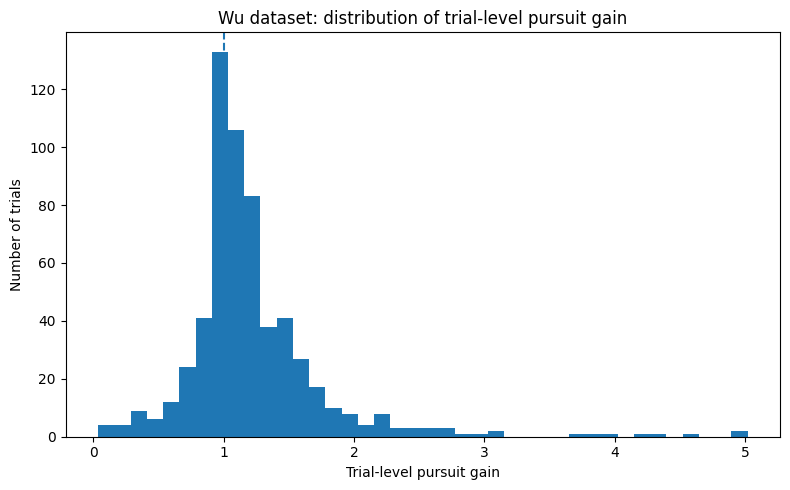

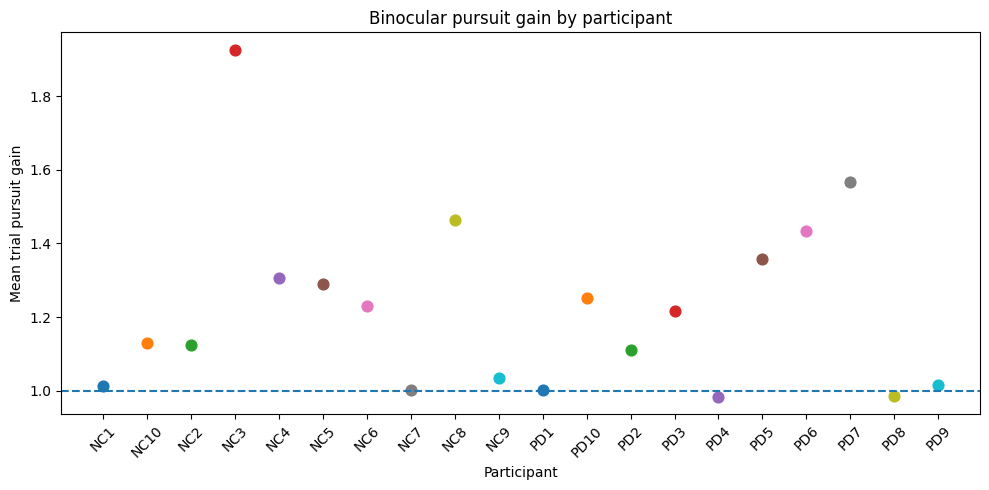

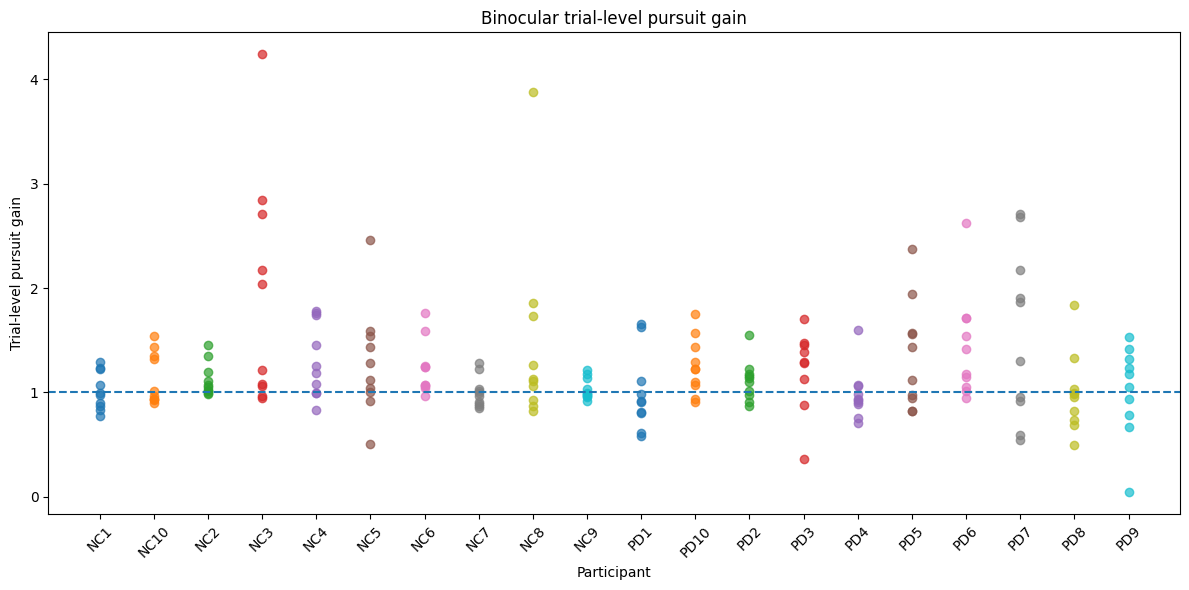



FILES SAVED
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_pursuit_gain_trial_QC.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_pursuit_gain_participant_QC.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_pursuit_gain_trial_counts_QC.csv

QC COMPLETE.


In [4]:
# ======================================================================
# WU DATASET — TRIAL-LEVEL PURSUIT GAIN QC
#
# PURPOSE:
#   1. Extract pursuit velocity 500–700 ms after pursuit onset
#   2. Calculate trial-level pursuit gain
#   3. Check missing / implausible / extreme trials
#   4. Check usable trials per participant
#   5. Compare Binocular vs Dichoptic descriptively
#   6. Produce participant-level mean/median gain for validation
#
# IMPORTANT:
#   This is QC only.
#   NO PD-vs-NC variability hypothesis test is performed here.
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


# ======================================================================
# 1. GOOGLE DRIVE
# ======================================================================

from google.colab import drive
drive.mount("/content/drive")


# ======================================================================
# 2. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")

OUT = BASE / "analysis_output"
OUT.mkdir(parents=True, exist_ok=True)

mat_files = sorted([
    f for f in BASE.rglob("*.mat")
    if f.stem.upper().startswith(("PD", "NC"))
])

print("=" * 85)
print("FILES")
print("=" * 85)
print("PD + NC .mat files found:", len(mat_files))

if len(mat_files) != 20:
    print(
        "WARNING: Expected 20 files "
        "(10 PD + 10 NC)."
    )


# ======================================================================
# 3. HELPERS
# ======================================================================

def get_field(trial, field):
    """Safely get a MATLAB struct field."""

    if not hasattr(trial, field):
        return None

    try:
        return np.asarray(
            getattr(trial, field)
        ).squeeze()

    except Exception:
        return None


def as_numeric(x):
    """Convert to 1-D numeric array when possible."""

    if x is None:
        return None

    try:
        x = np.asarray(x, dtype=float).squeeze()

        if x.ndim == 0:
            return np.array([float(x)])

        return x.ravel()

    except Exception:
        return None


def scalar_numeric(x):
    """Safely convert MATLAB scalar to Python float."""

    if x is None:
        return np.nan

    try:
        return float(
            np.asarray(x).squeeze()
        )

    except Exception:
        return np.nan


def candidate_time_score(arr, pursuit_time):
    """
    Score how plausible an array is as a time vector.

    We expect:
      - mostly increasing values
      - positive finite dt
      - pursuit onset to fall within/near its range
    """

    if arr is None or len(arr) < 10:
        return -np.inf

    x = np.asarray(arr, dtype=float)

    finite = np.isfinite(x)

    if finite.sum() < 10:
        return -np.inf

    x = x[finite]

    dx = np.diff(x)

    if len(dx) == 0:
        return -np.inf

    increasing_fraction = np.mean(dx > 0)

    score = 5 * increasing_fraction

    # reward mostly monotonic arrays
    if increasing_fraction > 0.95:
        score += 5

    # See whether pursuit_time looks compatible
    if np.isfinite(pursuit_time):

        xmin = np.nanmin(x)
        xmax = np.nanmax(x)

        if xmin <= pursuit_time <= xmax:
            score += 4

        # Also test alternative seconds/ms interpretation
        elif xmin <= pursuit_time / 1000 <= xmax:
            score += 2

        elif xmin / 1000 <= pursuit_time <= xmax / 1000:
            score += 2

    return score


def choose_time_vector(trial, pursuit_time):
    """
    The released dataset has oddly named fields.

    We inspect both XPos-like fields and choose the one
    behaving most like a monotonically increasing time vector.
    """

    candidates = {
        "leftEyexXPos":
            as_numeric(
                get_field(
                    trial,
                    "leftEyexXPos"
                )
            ),

        "rightEyeXPos":
            as_numeric(
                get_field(
                    trial,
                    "rightEyeXPos"
                )
            )
    }

    scores = {
        name: candidate_time_score(
            arr,
            pursuit_time
        )
        for name, arr in candidates.items()
    }

    best_name = max(
        scores,
        key=scores.get
    )

    if not np.isfinite(scores[best_name]):
        return None, None

    return candidates[best_name], best_name


def convert_time_to_seconds(time, pursuit_time):
    """
    Convert the time axis and pursuit onset to seconds.

    Determine scale from median sampling interval.
    """

    time = np.asarray(
        time,
        dtype=float
    )

    dt = np.diff(time)

    good_dt = dt[
        np.isfinite(dt)
        & (dt > 0)
    ]

    if len(good_dt) == 0:
        return None, np.nan, np.nan

    med_dt = np.nanmedian(good_dt)

    # If sample spacing is >0.5, values are almost certainly ms.
    if med_dt > 0.5:

        time_sec = time / 1000.0
        pursuit_sec = pursuit_time / 1000.0

    else:

        time_sec = time.copy()
        pursuit_sec = pursuit_time

        # pursuit_time itself may still be stored in ms
        # while time is seconds
        if (
            np.isfinite(pursuit_sec)
            and
            pursuit_sec > np.nanmax(time_sec) * 5
        ):
            pursuit_sec = pursuit_sec / 1000.0

    good_dt_sec = np.diff(time_sec)

    good_dt_sec = good_dt_sec[
        np.isfinite(good_dt_sec)
        & (good_dt_sec > 0)
    ]

    if len(good_dt_sec) > 0:

        sampling_hz = (
            1 /
            np.nanmedian(good_dt_sec)
        )

    else:

        sampling_hz = np.nan

    return (
        time_sec,
        pursuit_sec,
        sampling_hz
    )


# ======================================================================
# 4. EXTRACT EVERY TRIAL
# ======================================================================

rows = []


for f in mat_files:

    participant = f.stem.split("_")[0]

    group = (
        "PD"
        if participant.upper().startswith("PD")
        else "NC"
    )

    mat = sio.loadmat(
        f,
        squeeze_me=True,
        struct_as_record=False
    )

    for trial_type in [
        "BinocularTrials",
        "DichopticTrials"
    ]:

        if trial_type not in mat:
            continue

        trials = np.atleast_1d(
            mat[trial_type]
        )

        for trial_number, trial in enumerate(
            trials,
            start=1
        ):

            # ----------------------------------------------------------
            # pursuit onset
            # ----------------------------------------------------------

            pursuit_raw = get_field(
                trial,
                "timeToPursuit"
            )

            pursuit_time = scalar_numeric(
                pursuit_raw
            )


            # ----------------------------------------------------------
            # velocity signals
            # ----------------------------------------------------------

            left_vel = as_numeric(
                get_field(
                    trial,
                    "leftEyeVel"
                )
            )

            right_vel = as_numeric(
                get_field(
                    trial,
                    "rightEyeVel"
                )
            )


            # ----------------------------------------------------------
            # choose time vector
            # ----------------------------------------------------------

            time_raw, time_field = (
                choose_time_vector(
                    trial,
                    pursuit_time
                )
            )


            # ----------------------------------------------------------
            # default output values
            # ----------------------------------------------------------

            record = {

                "Participant":
                    participant,

                "Group":
                    group,

                "Condition":
                    trial_type.replace(
                        "Trials",
                        ""
                    ),

                "Trial":
                    trial_number,

                "Time_field":
                    time_field,

                "timeToPursuit_raw":
                    pursuit_time,

                "Sampling_Hz":
                    np.nan,

                "N_window":
                    0,

                "N_left_window":
                    0,

                "N_right_window":
                    0,

                "Left_mean_speed":
                    np.nan,

                "Right_mean_speed":
                    np.nan,

                "Left_median_speed":
                    np.nan,

                "Right_median_speed":
                    np.nan,

                "Binocular_mean_speed":
                    np.nan,

                "Binocular_median_speed":
                    np.nan,

                "Gain_mean":
                    np.nan,

                "Gain_median":
                    np.nan,

                "Eye_disagreement":
                    np.nan,

                "Window_OK":
                    False,

                "Plausible_gain":
                    False
            }


            # ----------------------------------------------------------
            # can't continue without time
            # ----------------------------------------------------------

            if (
                time_raw is None
                or
                not np.isfinite(pursuit_time)
            ):

                rows.append(record)
                continue


            # ----------------------------------------------------------
            # convert time to seconds
            # ----------------------------------------------------------

            result = convert_time_to_seconds(
                time_raw,
                pursuit_time
            )

            if result[0] is None:

                rows.append(record)
                continue

            (
                time_sec,
                pursuit_sec,
                sampling_hz
            ) = result

            record["Sampling_Hz"] = (
                sampling_hz
            )


            # ----------------------------------------------------------
            # 500–700 ms steady-state window
            # ----------------------------------------------------------

            window_start = (
                pursuit_sec + 0.500
            )

            window_end = (
                pursuit_sec + 0.700
            )

            time_mask = (
                np.isfinite(time_sec)
                &
                (time_sec >= window_start)
                &
                (time_sec <= window_end)
            )


            # ----------------------------------------------------------
            # align array lengths
            # ----------------------------------------------------------

            n_time = len(time_sec)

            left_speed = None
            right_speed = None


            if left_vel is not None:

                n = min(
                    n_time,
                    len(left_vel)
                )

                lv = left_vel[:n]
                lm = time_mask[:n]

                # Gain concerns speed magnitude.
                left_speed = np.abs(lv)

                valid = (
                    lm
                    &
                    np.isfinite(left_speed)
                )

                record[
                    "N_left_window"
                ] = int(
                    valid.sum()
                )

                if valid.sum() > 0:

                    record[
                        "Left_mean_speed"
                    ] = np.nanmean(
                        left_speed[valid]
                    )

                    record[
                        "Left_median_speed"
                    ] = np.nanmedian(
                        left_speed[valid]
                    )


            if right_vel is not None:

                n = min(
                    n_time,
                    len(right_vel)
                )

                rv = right_vel[:n]
                rm = time_mask[:n]

                right_speed = np.abs(rv)

                valid = (
                    rm
                    &
                    np.isfinite(right_speed)
                )

                record[
                    "N_right_window"
                ] = int(
                    valid.sum()
                )

                if valid.sum() > 0:

                    record[
                        "Right_mean_speed"
                    ] = np.nanmean(
                        right_speed[valid]
                    )

                    record[
                        "Right_median_speed"
                    ] = np.nanmedian(
                        right_speed[valid]
                    )


            # ----------------------------------------------------------
            # overall number of time samples in window
            # ----------------------------------------------------------

            record[
                "N_window"
            ] = int(
                time_mask.sum()
            )


            # ----------------------------------------------------------
            # Require at least a small number of samples
            #
            # At ~125 Hz, 200 ms gives ~25 samples.
            # We only use 5 as an extremely permissive QC threshold.
            # ----------------------------------------------------------

            enough_left = (
                record[
                    "N_left_window"
                ] >= 5
            )

            enough_right = (
                record[
                    "N_right_window"
                ] >= 5
            )

            record[
                "Window_OK"
            ] = (
                enough_left
                or
                enough_right
            )


            # ----------------------------------------------------------
            # combine eyes
            #
            # We first calculate one summary per eye,
            # then average the two eye summaries.
            # ----------------------------------------------------------

            eye_means = [
                x for x in [
                    record[
                        "Left_mean_speed"
                    ],
                    record[
                        "Right_mean_speed"
                    ]
                ]
                if np.isfinite(x)
            ]

            eye_medians = [
                x for x in [
                    record[
                        "Left_median_speed"
                    ],
                    record[
                        "Right_median_speed"
                    ]
                ]
                if np.isfinite(x)
            ]


            if len(eye_means) > 0:

                record[
                    "Binocular_mean_speed"
                ] = np.mean(
                    eye_means
                )


            if len(eye_medians) > 0:

                record[
                    "Binocular_median_speed"
                ] = np.mean(
                    eye_medians
                )


            # ----------------------------------------------------------
            # eye disagreement QC
            # ----------------------------------------------------------

            if (
                np.isfinite(
                    record[
                        "Left_mean_speed"
                    ]
                )
                and
                np.isfinite(
                    record[
                        "Right_mean_speed"
                    ]
                )
            ):

                record[
                    "Eye_disagreement"
                ] = abs(
                    record[
                        "Left_mean_speed"
                    ]
                    -
                    record[
                        "Right_mean_speed"
                    ]
                )


            # ----------------------------------------------------------
            # Gain = eye speed / target speed
            #
            # Target speed = 10 deg/s
            # ----------------------------------------------------------

            TARGET_SPEED = 10.0


            if np.isfinite(
                record[
                    "Binocular_mean_speed"
                ]
            ):

                record[
                    "Gain_mean"
                ] = (
                    record[
                        "Binocular_mean_speed"
                    ]
                    /
                    TARGET_SPEED
                )


            if np.isfinite(
                record[
                    "Binocular_median_speed"
                ]
            ):

                record[
                    "Gain_median"
                ] = (
                    record[
                        "Binocular_median_speed"
                    ]
                    /
                    TARGET_SPEED
                )


            # ----------------------------------------------------------
            # BROAD plausibility flag ONLY
            #
            # Do NOT remove based on this yet.
            #
            # 0.2–2.0 is deliberately broad.
            # ----------------------------------------------------------

            g = record[
                "Gain_mean"
            ]

            record[
                "Plausible_gain"
            ] = (
                np.isfinite(g)
                and
                0.2 <= g <= 2.0
            )


            rows.append(record)


# ======================================================================
# 5. CREATE DATAFRAME
# ======================================================================

trial_df = pd.DataFrame(
    rows
)

print("\n")
print("=" * 85)
print("EXTRACTION SUMMARY")
print("=" * 85)

print(
    "Total trials extracted:",
    len(trial_df)
)

print("\nExpected:")
print("20 participants × 30 trials = 600")


# ======================================================================
# 6. BASIC COMPLETENESS
# ======================================================================

print("\n")
print("=" * 85)
print("TRIAL COUNTS")
print("=" * 85)

print(
    trial_df.groupby(
        [
            "Group",
            "Condition"
        ]
    ).size()
)


print("\nValid 500–700 ms windows:")

print(
    trial_df.groupby(
        [
            "Group",
            "Condition"
        ]
    )[
        "Window_OK"
    ].agg(
        [
            "sum",
            "count"
        ]
    )
)


# ======================================================================
# 7. SAMPLING QC
# ======================================================================

print("\n")
print("=" * 85)
print("SAMPLING RATE OF TRIAL STREAMS")
print("=" * 85)

print(
    trial_df.groupby(
        [
            "Group",
            "Condition"
        ]
    )[
        "Sampling_Hz"
    ].agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


# ======================================================================
# 8. NUMBER OF SAMPLES IN 500–700 ms WINDOW
# ======================================================================

print("\n")
print("=" * 85)
print("SAMPLES IN 500–700 ms WINDOW")
print("=" * 85)

print(
    trial_df.groupby(
        [
            "Group",
            "Condition"
        ]
    )[
        "N_window"
    ].agg(
        [
            "count",
            "median",
            "mean",
            "min",
            "max"
        ]
    )
)


# ======================================================================
# 9. TRIAL-LEVEL GAIN DISTRIBUTION
# ======================================================================

valid_gain = trial_df[
    trial_df[
        "Gain_mean"
    ].notna()
].copy()


print("\n")
print("=" * 85)
print("TRIAL-LEVEL PURSUIT GAIN — ALL EXTRACTED TRIALS")
print("=" * 85)

print(
    valid_gain.groupby(
        [
            "Group",
            "Condition"
        ]
    )[
        "Gain_mean"
    ].agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


# ======================================================================
# 10. PLAUSIBILITY COUNTS
# ======================================================================

print("\n")
print("=" * 85)
print("BROAD PLAUSIBILITY CHECK")
print("Plausible defined only for QC as 0.2 <= gain <= 2.0")
print("NO trials are being removed yet.")
print("=" * 85)

plausibility = (
    trial_df.groupby(
        [
            "Group",
            "Condition"
        ]
    )[
        "Plausible_gain"
    ]
    .agg(
        [
            "sum",
            "count"
        ]
    )
)

plausibility[
    "percent"
] = (
    100
    *
    plausibility["sum"]
    /
    plausibility["count"]
)

print(
    plausibility
)


# ======================================================================
# 11. EXTREME TRIALS
# ======================================================================

print("\n")
print("=" * 85)
print("LOWEST 15 GAIN TRIALS")
print("=" * 85)

cols = [
    "Participant",
    "Group",
    "Condition",
    "Trial",
    "Gain_mean",
    "Gain_median",
    "N_window",
    "Sampling_Hz",
    "Eye_disagreement"
]

print(
    valid_gain
    .sort_values(
        "Gain_mean"
    )[cols]
    .head(15)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 85)
print("HIGHEST 15 GAIN TRIALS")
print("=" * 85)

print(
    valid_gain
    .sort_values(
        "Gain_mean",
        ascending=False
    )[cols]
    .head(15)
    .to_string(
        index=False
    )
)


# ======================================================================
# 12. VALID TRIALS PER PARTICIPANT
# ======================================================================

participant_counts = (
    trial_df
    .groupby(
        [
            "Participant",
            "Group",
            "Condition"
        ]
    )
    .agg(
        Total_trials=(
            "Trial",
            "count"
        ),

        Valid_gain_trials=(
            "Gain_mean",
            "count"
        ),

        Plausible_trials=(
            "Plausible_gain",
            "sum"
        )
    )
    .reset_index()
)


print("\n")
print("=" * 85)
print("TRIAL AVAILABILITY BY PARTICIPANT")
print("=" * 85)

print(
    participant_counts
    .to_string(
        index=False
    )
)


# ======================================================================
# 13. PARTICIPANT-LEVEL TYPICAL GAIN
# ======================================================================

participant_gain = (
    valid_gain
    .groupby(
        [
            "Participant",
            "Group",
            "Condition"
        ]
    )
    .agg(

        N_trials=(
            "Gain_mean",
            "count"
        ),

        Mean_gain=(
            "Gain_mean",
            "mean"
        ),

        Median_gain=(
            "Gain_mean",
            "median"
        ),

        SD_gain=(
            "Gain_mean",
            "std"
        ),

        Q25=(
            "Gain_mean",
            lambda x:
                np.nanpercentile(
                    x,
                    25
                )
        ),

        Q75=(
            "Gain_mean",
            lambda x:
                np.nanpercentile(
                    x,
                    75
                )
        )
    )
    .reset_index()
)

participant_gain[
    "IQR_gain"
] = (
    participant_gain[
        "Q75"
    ]
    -
    participant_gain[
        "Q25"
    ]
)


print("\n")
print("=" * 85)
print("PARTICIPANT-LEVEL GAIN SUMMARY")
print("=" * 85)

print(
    participant_gain[
        [
            "Participant",
            "Group",
            "Condition",
            "N_trials",
            "Mean_gain",
            "Median_gain",
            "SD_gain",
            "IQR_gain"
        ]
    ]
    .to_string(
        index=False
    )
)


# ======================================================================
# 14. GROUP DESCRIPTIVE SUMMARY OF PARTICIPANT MEANS
#
# IMPORTANT:
# Descriptive validation only.
# This is NOT our variability hypothesis test.
# ======================================================================

print("\n")
print("=" * 85)
print("GROUP SUMMARY OF PARTICIPANT MEAN GAIN")
print("DESCRIPTIVE ONLY")
print("=" * 85)

print(
    participant_gain.groupby(
        [
            "Group",
            "Condition"
        ]
    )[
        "Mean_gain"
    ].agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


# ======================================================================
# 15. LEFT-vs-RIGHT EYE AGREEMENT
# ======================================================================

print("\n")
print("=" * 85)
print("LEFT/RIGHT EYE SPEED DISAGREEMENT")
print("Absolute difference between eye mean speeds, deg/s")
print("=" * 85)

print(
    trial_df.groupby(
        [
            "Group",
            "Condition"
        ]
    )[
        "Eye_disagreement"
    ].agg(
        [
            "count",
            "median",
            "mean",
            "std",
            "max"
        ]
    )
)


# ======================================================================
# 16. PLOT — TRIAL GAIN DISTRIBUTION
# ======================================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    valid_gain[
        "Gain_mean"
    ].dropna(),
    bins=40
)

plt.axvline(
    1.0,
    linestyle="--"
)

plt.xlabel(
    "Trial-level pursuit gain"
)

plt.ylabel(
    "Number of trials"
)

plt.title(
    "Wu dataset: distribution of trial-level pursuit gain"
)

plt.tight_layout()
plt.show()


# ======================================================================
# 17. PLOT — PARTICIPANT MEAN GAIN
# ======================================================================

plt.figure(
    figsize=(10, 5)
)

plot_df = participant_gain[
    participant_gain[
        "Condition"
    ] == "Binocular"
].copy()

for i, row in plot_df.reset_index(
    drop=True
).iterrows():

    plt.scatter(
        i,
        row["Mean_gain"],
        s=60
    )

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xticks(
    range(len(plot_df)),
    plot_df["Participant"],
    rotation=45
)

plt.ylabel(
    "Mean trial pursuit gain"
)

plt.xlabel(
    "Participant"
)

plt.title(
    "Binocular pursuit gain by participant"
)

plt.tight_layout()
plt.show()


# ======================================================================
# 18. PLOT — BINOCULAR TRIAL GAINS BY PARTICIPANT
# ======================================================================

bino = valid_gain[
    valid_gain[
        "Condition"
    ] == "Binocular"
].copy()

participants = sorted(
    bino[
        "Participant"
    ].unique()
)

plt.figure(
    figsize=(12, 6)
)

for i, participant in enumerate(
    participants
):

    values = bino.loc[
        bino[
            "Participant"
        ] == participant,
        "Gain_mean"
    ].values

    x = np.full(
        len(values),
        i
    )

    plt.scatter(
        x,
        values,
        alpha=0.7
    )


plt.axhline(
    1.0,
    linestyle="--"
)

plt.xticks(
    range(
        len(participants)
    ),
    participants,
    rotation=45
)

plt.ylabel(
    "Trial-level pursuit gain"
)

plt.xlabel(
    "Participant"
)

plt.title(
    "Binocular trial-level pursuit gain"
)

plt.tight_layout()
plt.show()


# ======================================================================
# 19. SAVE EVERYTHING
# ======================================================================

trial_path = (
    OUT
    /
    "Wu_pursuit_gain_trial_QC.csv"
)

participant_path = (
    OUT
    /
    "Wu_pursuit_gain_participant_QC.csv"
)

counts_path = (
    OUT
    /
    "Wu_pursuit_gain_trial_counts_QC.csv"
)


trial_df.to_csv(
    trial_path,
    index=False
)

participant_gain.to_csv(
    participant_path,
    index=False
)

participant_counts.to_csv(
    counts_path,
    index=False
)


print("\n")
print("=" * 85)
print("FILES SAVED")
print("=" * 85)

print(trial_path)
print(participant_path)
print(counts_path)


print("\nQC COMPLETE.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FILES
PD + NC MAT files: 20


EXTRACTION
Binocular trials extracted: 200
Expected: 200

Clean valid: 199 / 200


RAW vs CLEAN TRIAL GAIN

Raw_mean_gain
       count      mean       std    median       min       max
Group                                                         
NC       100  1.252336  0.558063  1.068591  0.505513  4.240764
PD        99  1.192089  0.469827  1.097457  0.042559  2.712257

Raw_median_gain
       count      mean       std    median       min       max
Group                                                         
NC       100  0.980780  0.178882  0.983258  0.063971  1.553343
PD        99  0.937529  0.282748  0.970969  0.052557  1.480693

Clean_mean_gain
       count      mean       std    median       min       max
Group                                                         
NC       100  0.989636  0.220718  0.983603  0.053774  1

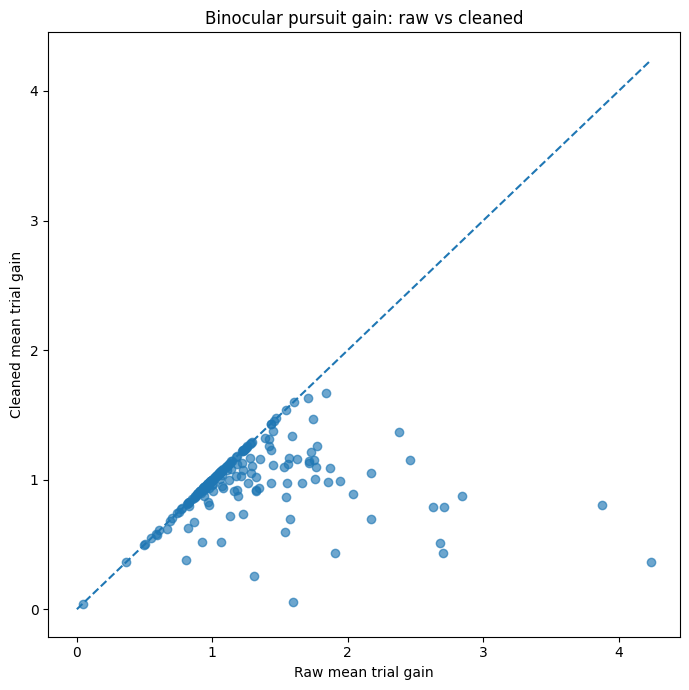

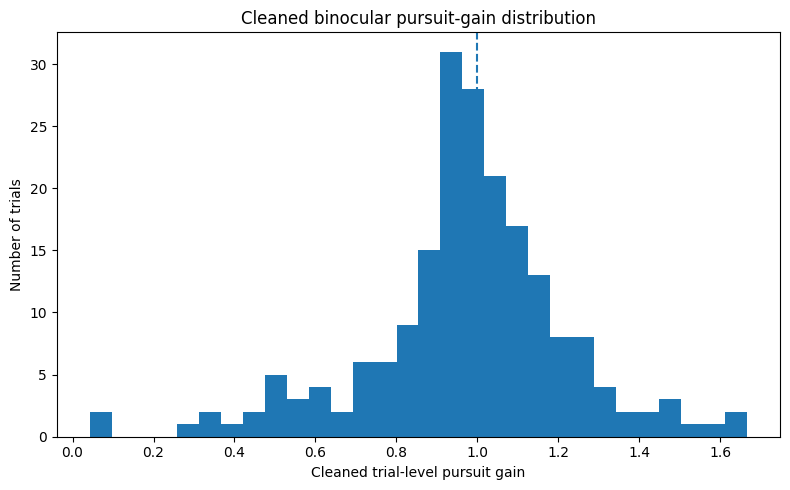

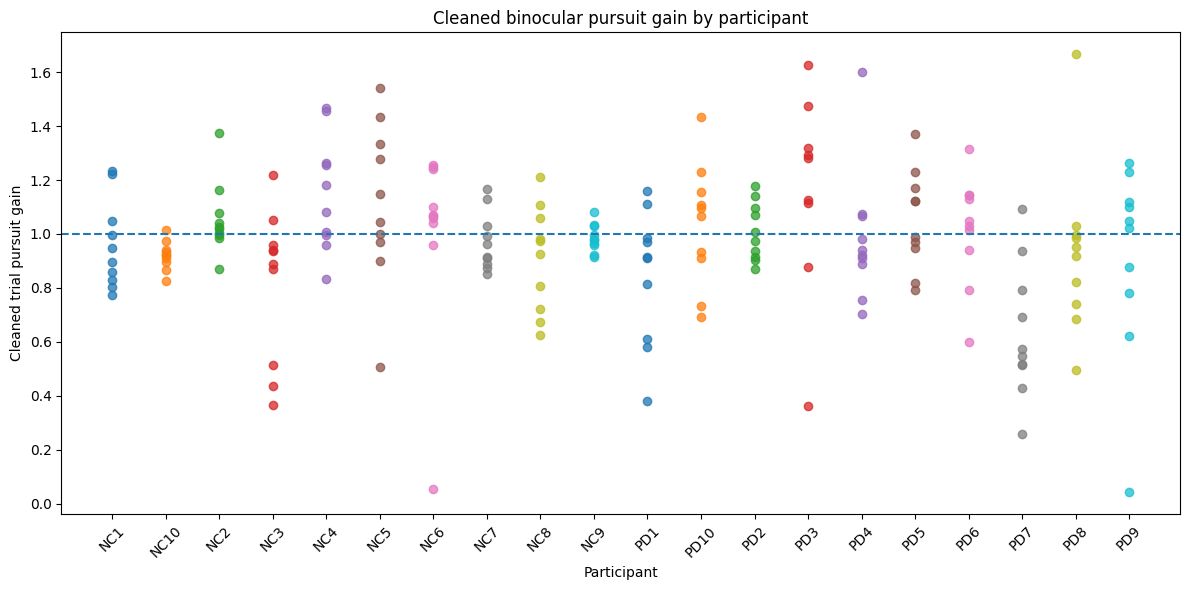

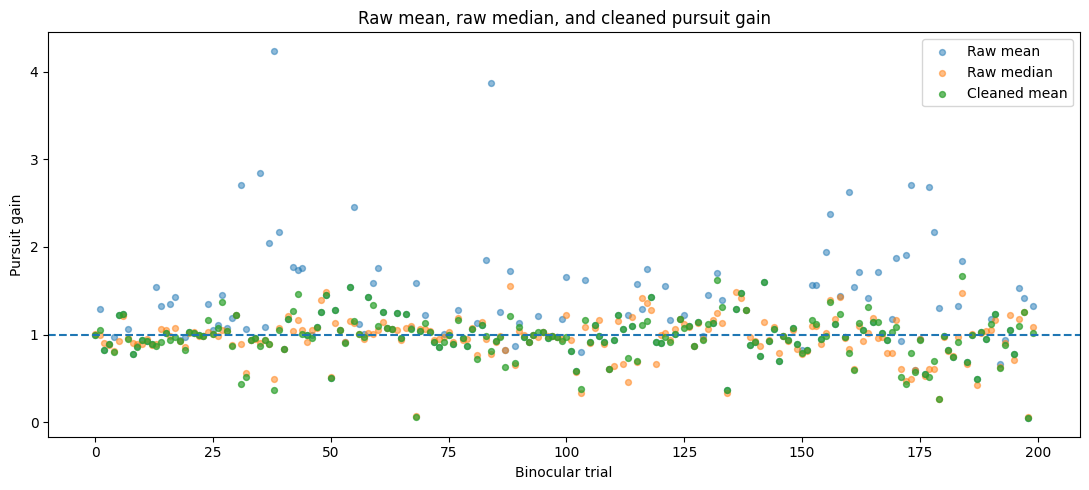



SAVED
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_binocular_pursuit_cleaning_QC.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_binocular_pursuit_cleaning_participant_QC.csv

QC CLEANING COMPLETE.


In [5]:
# =====================================================================
# WU DATASET
# BINOCULAR PURSUIT GAIN — SACCADE-CONTAMINATION CLEANING QC
#
# PURPOSE:
#   - Use BINOCULAR trials only
#   - Analyze 500–700 ms after pursuit onset
#   - Inspect sample-level eye velocity
#   - Remove obvious high-velocity contamination conservatively
#   - Compare:
#         raw mean gain
#         raw median gain
#         cleaned mean gain
#   - DO NOT perform final PD-vs-NC variability hypothesis test yet
#
# =====================================================================


# =====================================================================
# 0. IMPORTS
# =====================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


# =====================================================================
# 1. GOOGLE DRIVE
# =====================================================================

from google.colab import drive
drive.mount("/content/drive")


# =====================================================================
# 2. PATHS
# =====================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")

OUT = BASE / "analysis_output"
OUT.mkdir(parents=True, exist_ok=True)

mat_files = sorted([
    f for f in BASE.rglob("*.mat")
    if f.stem.upper().startswith(("PD", "NC"))
])

print("=" * 90)
print("FILES")
print("=" * 90)
print("PD + NC MAT files:", len(mat_files))


# =====================================================================
# 3. CONSTANTS
# =====================================================================

TARGET_SPEED = 10.0

# Wu steady-state analysis window
WINDOW_START = 0.500
WINDOW_END   = 0.700

# Conservative contamination criteria
#
# A pursuit target is moving at 10 deg/s.
# Samples >30 deg/s are suspicious for pursuit alone.
ABS_VELOCITY_LIMIT = 30.0

# Robust within-trial threshold
MAD_MULTIPLIER = 6.0

# Require at least this many cleaned samples
MIN_CLEAN_SAMPLES = 5


# =====================================================================
# 4. HELPER FUNCTIONS
# =====================================================================

def get_field(trial, field):
    if not hasattr(trial, field):
        return None

    try:
        return np.asarray(
            getattr(trial, field)
        ).squeeze()

    except Exception:
        return None


def as_numeric(x):

    if x is None:
        return None

    try:
        x = np.asarray(
            x,
            dtype=float
        ).squeeze()

        if x.ndim == 0:
            return np.array(
                [float(x)]
            )

        return x.ravel()

    except Exception:
        return None


def scalar_numeric(x):

    if x is None:
        return np.nan

    try:
        return float(
            np.asarray(x).squeeze()
        )

    except Exception:
        return np.nan


def time_score(arr, pursuit_time):

    if arr is None or len(arr) < 10:
        return -np.inf

    arr = np.asarray(
        arr,
        dtype=float
    )

    good = np.isfinite(arr)

    if good.sum() < 10:
        return -np.inf

    x = arr[good]

    dx = np.diff(x)

    if len(dx) == 0:
        return -np.inf

    increasing = np.mean(
        dx > 0
    )

    score = 5 * increasing

    if increasing > 0.95:
        score += 5

    if np.isfinite(pursuit_time):

        xmin = np.nanmin(x)
        xmax = np.nanmax(x)

        if xmin <= pursuit_time <= xmax:
            score += 4

        elif xmin <= pursuit_time / 1000 <= xmax:
            score += 2

        elif xmin / 1000 <= pursuit_time <= xmax / 1000:
            score += 2

    return score


def choose_time_vector(trial, pursuit_time):

    candidates = {

        "leftEyexXPos":
            as_numeric(
                get_field(
                    trial,
                    "leftEyexXPos"
                )
            ),

        "rightEyeXPos":
            as_numeric(
                get_field(
                    trial,
                    "rightEyeXPos"
                )
            )
    }

    scores = {
        name:
            time_score(
                arr,
                pursuit_time
            )
        for name, arr
        in candidates.items()
    }

    best = max(
        scores,
        key=scores.get
    )

    if not np.isfinite(
        scores[best]
    ):
        return None, None

    return (
        candidates[best],
        best
    )


def convert_time(time, pursuit_time):

    time = np.asarray(
        time,
        dtype=float
    )

    dt = np.diff(time)

    good_dt = dt[
        np.isfinite(dt)
        &
        (dt > 0)
    ]

    if len(good_dt) == 0:
        return None, np.nan, np.nan

    median_dt = np.nanmedian(
        good_dt
    )

    # likely milliseconds
    if median_dt > 0.5:

        time_sec = time / 1000.0
        pursuit_sec = pursuit_time / 1000.0

    else:

        time_sec = time.copy()
        pursuit_sec = pursuit_time

        # possible mixed units
        if (
            np.isfinite(pursuit_sec)
            and
            pursuit_sec >
            np.nanmax(time_sec) * 5
        ):
            pursuit_sec /= 1000.0


    dt_sec = np.diff(
        time_sec
    )

    dt_sec = dt_sec[
        np.isfinite(dt_sec)
        &
        (dt_sec > 0)
    ]

    if len(dt_sec):

        sampling_hz = (
            1 /
            np.nanmedian(dt_sec)
        )

    else:

        sampling_hz = np.nan


    return (
        time_sec,
        pursuit_sec,
        sampling_hz
    )


# =====================================================================
# 5. ROBUST CONTAMINATION FILTER
# =====================================================================

def clean_velocity_window(values):
    """
    Conservative within-trial filtering.

    Returns:
        raw mean speed
        raw median speed
        cleaned mean speed
        cleaned median speed
        number raw
        number retained
        fraction removed
        max raw speed
    """

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    # work with speed magnitude
    speed = np.abs(values)

    n_raw = len(speed)

    if n_raw == 0:

        return {
            "raw_mean": np.nan,
            "raw_median": np.nan,
            "clean_mean": np.nan,
            "clean_median": np.nan,
            "n_raw": 0,
            "n_clean": 0,
            "frac_removed": np.nan,
            "max_speed": np.nan
        }


    raw_mean = np.nanmean(
        speed
    )

    raw_median = np.nanmedian(
        speed
    )

    max_speed = np.nanmax(
        speed
    )


    # -------------------------------------------------------------
    # Median absolute deviation
    # -------------------------------------------------------------

    mad = np.nanmedian(
        np.abs(
            speed - raw_median
        )
    )

    robust_sigma = (
        1.4826 * mad
    )


    # -------------------------------------------------------------
    # Robust high-side threshold
    # -------------------------------------------------------------

    if (
        np.isfinite(robust_sigma)
        and
        robust_sigma > 0
    ):

        robust_limit = (
            raw_median
            +
            MAD_MULTIPLIER
            *
            robust_sigma
        )

    else:

        robust_limit = np.inf


    # A sample is suspicious if:
    #
    #   1. > 30 deg/s
    #       OR
    #
    #   2. extremely far above the local robust distribution
    #
    # We only remove HIGH-speed contamination,
    # because low pursuit velocity can be genuine.
    # -------------------------------------------------------------

    contaminated = (
        (speed > ABS_VELOCITY_LIMIT)
        |
        (speed > robust_limit)
    )


    clean = speed[
        ~contaminated
    ]

    n_clean = len(clean)

    frac_removed = (
        (n_raw - n_clean)
        /
        n_raw
    )


    if n_clean >= MIN_CLEAN_SAMPLES:

        clean_mean = np.nanmean(
            clean
        )

        clean_median = np.nanmedian(
            clean
        )

    else:

        clean_mean = np.nan
        clean_median = np.nan


    return {

        "raw_mean":
            raw_mean,

        "raw_median":
            raw_median,

        "clean_mean":
            clean_mean,

        "clean_median":
            clean_median,

        "n_raw":
            n_raw,

        "n_clean":
            n_clean,

        "frac_removed":
            frac_removed,

        "max_speed":
            max_speed
    }


# =====================================================================
# 6. EXTRACT BINOCULAR TRIALS ONLY
# =====================================================================

rows = []


for f in mat_files:

    participant = (
        f.stem.split("_")[0]
    )

    group = (
        "PD"
        if participant.upper().startswith("PD")
        else "NC"
    )


    mat = sio.loadmat(
        f,
        squeeze_me=True,
        struct_as_record=False
    )


    if "BinocularTrials" not in mat:
        continue


    trials = np.atleast_1d(
        mat["BinocularTrials"]
    )


    for trial_number, trial in enumerate(
        trials,
        start=1
    ):

        pursuit_time = scalar_numeric(
            get_field(
                trial,
                "timeToPursuit"
            )
        )


        left_vel = as_numeric(
            get_field(
                trial,
                "leftEyeVel"
            )
        )

        right_vel = as_numeric(
            get_field(
                trial,
                "rightEyeVel"
            )
        )


        time_raw, time_field = (
            choose_time_vector(
                trial,
                pursuit_time
            )
        )


        record = {

            "Participant":
                participant,

            "Group":
                group,

            "Trial":
                trial_number,

            "Sampling_Hz":
                np.nan,

            "N_window":
                0,

            "Left_raw_mean":
                np.nan,

            "Left_raw_median":
                np.nan,

            "Left_clean_mean":
                np.nan,

            "Left_frac_removed":
                np.nan,

            "Left_max_speed":
                np.nan,

            "Right_raw_mean":
                np.nan,

            "Right_raw_median":
                np.nan,

            "Right_clean_mean":
                np.nan,

            "Right_frac_removed":
                np.nan,

            "Right_max_speed":
                np.nan,

            "Raw_mean_gain":
                np.nan,

            "Raw_median_gain":
                np.nan,

            "Clean_mean_gain":
                np.nan,

            "Clean_median_gain":
                np.nan,

            "Mean_fraction_removed":
                np.nan,

            "Max_speed":
                np.nan,

            "Clean_valid":
                False
        }


        if (
            time_raw is None
            or
            not np.isfinite(
                pursuit_time
            )
        ):

            rows.append(
                record
            )

            continue


        result = convert_time(
            time_raw,
            pursuit_time
        )

        if result[0] is None:

            rows.append(
                record
            )

            continue


        (
            time_sec,
            pursuit_sec,
            sampling_hz
        ) = result


        record[
            "Sampling_Hz"
        ] = sampling_hz


        mask = (
            np.isfinite(time_sec)
            &
            (
                time_sec >=
                pursuit_sec
                + WINDOW_START
            )
            &
            (
                time_sec <=
                pursuit_sec
                + WINDOW_END
            )
        )


        record[
            "N_window"
        ] = int(
            mask.sum()
        )


        eye_results = []


        # =========================================================
        # LEFT EYE
        # =========================================================

        if left_vel is not None:

            n = min(
                len(time_sec),
                len(left_vel)
            )

            valid_mask = (
                mask[:n]
                &
                np.isfinite(
                    left_vel[:n]
                )
            )

            lv = left_vel[:n][
                valid_mask
            ]


            left = (
                clean_velocity_window(
                    lv
                )
            )


            record[
                "Left_raw_mean"
            ] = left[
                "raw_mean"
            ]

            record[
                "Left_raw_median"
            ] = left[
                "raw_median"
            ]

            record[
                "Left_clean_mean"
            ] = left[
                "clean_mean"
            ]

            record[
                "Left_frac_removed"
            ] = left[
                "frac_removed"
            ]

            record[
                "Left_max_speed"
            ] = left[
                "max_speed"
            ]

            eye_results.append(
                left
            )


        # =========================================================
        # RIGHT EYE
        # =========================================================

        if right_vel is not None:

            n = min(
                len(time_sec),
                len(right_vel)
            )

            valid_mask = (
                mask[:n]
                &
                np.isfinite(
                    right_vel[:n]
                )
            )

            rv = right_vel[:n][
                valid_mask
            ]


            right = (
                clean_velocity_window(
                    rv
                )
            )


            record[
                "Right_raw_mean"
            ] = right[
                "raw_mean"
            ]

            record[
                "Right_raw_median"
            ] = right[
                "raw_median"
            ]

            record[
                "Right_clean_mean"
            ] = right[
                "clean_mean"
            ]

            record[
                "Right_frac_removed"
            ] = right[
                "frac_removed"
            ]

            record[
                "Right_max_speed"
            ] = right[
                "max_speed"
            ]

            eye_results.append(
                right
            )


        # =========================================================
        # COMBINE EYES
        # =========================================================

        raw_means = [
            x["raw_mean"]
            for x in eye_results
            if np.isfinite(
                x["raw_mean"]
            )
        ]

        raw_medians = [
            x["raw_median"]
            for x in eye_results
            if np.isfinite(
                x["raw_median"]
            )
        ]

        clean_means = [
            x["clean_mean"]
            for x in eye_results
            if np.isfinite(
                x["clean_mean"]
            )
        ]

        clean_medians = [
            x["clean_median"]
            for x in eye_results
            if np.isfinite(
                x["clean_median"]
            )
        ]


        if raw_means:

            record[
                "Raw_mean_gain"
            ] = (
                np.mean(
                    raw_means
                )
                /
                TARGET_SPEED
            )


        if raw_medians:

            record[
                "Raw_median_gain"
            ] = (
                np.mean(
                    raw_medians
                )
                /
                TARGET_SPEED
            )


        if clean_means:

            record[
                "Clean_mean_gain"
            ] = (
                np.mean(
                    clean_means
                )
                /
                TARGET_SPEED
            )


        if clean_medians:

            record[
                "Clean_median_gain"
            ] = (
                np.mean(
                    clean_medians
                )
                /
                TARGET_SPEED
            )


        fractions = [
            x["frac_removed"]
            for x in eye_results
            if np.isfinite(
                x["frac_removed"]
            )
        ]

        if fractions:

            record[
                "Mean_fraction_removed"
            ] = np.mean(
                fractions
            )


        maxima = [
            x["max_speed"]
            for x in eye_results
            if np.isfinite(
                x["max_speed"]
            )
        ]

        if maxima:

            record[
                "Max_speed"
            ] = np.max(
                maxima
            )


        record[
            "Clean_valid"
        ] = np.isfinite(
            record[
                "Clean_mean_gain"
            ]
        )


        rows.append(
            record
        )


# =====================================================================
# 7. DATAFRAME
# =====================================================================

df = pd.DataFrame(
    rows
)


print("\n")
print("=" * 90)
print("EXTRACTION")
print("=" * 90)

print(
    "Binocular trials extracted:",
    len(df)
)

print(
    "Expected:",
    20 * 10
)


print(
    "\nClean valid:",
    int(
        df[
            "Clean_valid"
        ].sum()
    ),
    "/",
    len(df)
)


# =====================================================================
# 8. RAW VS CLEAN GAIN DISTRIBUTIONS
# =====================================================================

print("\n")
print("=" * 90)
print("RAW vs CLEAN TRIAL GAIN")
print("=" * 90)


for variable in [
    "Raw_mean_gain",
    "Raw_median_gain",
    "Clean_mean_gain",
    "Clean_median_gain"
]:

    print(
        f"\n{variable}"
    )

    print(
        df.groupby(
            "Group"
        )[variable].agg(
            [
                "count",
                "mean",
                "std",
                "median",
                "min",
                "max"
            ]
        )
    )


# =====================================================================
# 9. HOW MUCH DATA WAS REMOVED?
# =====================================================================

print("\n")
print("=" * 90)
print("FRACTION OF SAMPLES REMOVED")
print("=" * 90)


print(
    df.groupby(
        "Group"
    )[
        "Mean_fraction_removed"
    ].agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


print("\nTrials with no samples removed:")

print(
    (
        df[
            "Mean_fraction_removed"
        ] == 0
    ).groupby(
        df["Group"]
    ).sum()
)


print("\nTrials with >10% removed:")

print(
    (
        df[
            "Mean_fraction_removed"
        ] > 0.10
    ).groupby(
        df["Group"]
    ).sum()
)


print("\nTrials with >25% removed:")

print(
    (
        df[
            "Mean_fraction_removed"
        ] > 0.25
    ).groupby(
        df["Group"]
    ).sum()
)


# =====================================================================
# 10. BIGGEST RAW → CLEAN CHANGES
# =====================================================================

df[
    "Gain_change"
] = (
    df[
        "Raw_mean_gain"
    ]
    -
    df[
        "Clean_mean_gain"
    ]
)


print("\n")
print("=" * 90)
print("20 TRIALS MOST AFFECTED BY CLEANING")
print("=" * 90)


show_cols = [

    "Participant",
    "Group",
    "Trial",

    "Raw_mean_gain",
    "Raw_median_gain",
    "Clean_mean_gain",
    "Clean_median_gain",

    "Gain_change",

    "Mean_fraction_removed",
    "Max_speed",

    "Sampling_Hz",
    "N_window"
]


print(
    df.sort_values(
        "Gain_change",
        ascending=False
    )[
        show_cols
    ]
    .head(20)
    .to_string(
        index=False
    )
)


# =====================================================================
# 11. SPECIFIC PROBLEM PARTICIPANTS
# =====================================================================

print("\n")
print("=" * 90)
print("NC3 AND PD7 — BEFORE / AFTER")
print("=" * 90)


problem = df[
    df[
        "Participant"
    ].isin(
        [
            "NC3",
            "PD7"
        ]
    )
]


print(
    problem[
        show_cols
    ]
    .sort_values(
        [
            "Participant",
            "Trial"
        ]
    )
    .to_string(
        index=False
    )
)


# =====================================================================
# 12. PARTICIPANT SUMMARY — CLEANED GAINS
# =====================================================================

valid = df[
    df[
        "Clean_valid"
    ]
].copy()


participant = (
    valid.groupby(
        [
            "Participant",
            "Group"
        ]
    )
    .agg(

        N_trials=(
            "Clean_mean_gain",
            "count"
        ),

        Mean_gain=(
            "Clean_mean_gain",
            "mean"
        ),

        Median_gain=(
            "Clean_mean_gain",
            "median"
        ),

        SD_gain=(
            "Clean_mean_gain",
            "std"
        ),

        Q25=(
            "Clean_mean_gain",
            lambda x:
                np.nanpercentile(
                    x,
                    25
                )
        ),

        Q75=(
            "Clean_mean_gain",
            lambda x:
                np.nanpercentile(
                    x,
                    75
                )
        ),

        Median_fraction_removed=(
            "Mean_fraction_removed",
            "median"
        )
    )
    .reset_index()
)


participant[
    "IQR_gain"
] = (
    participant[
        "Q75"
    ]
    -
    participant[
        "Q25"
    ]
)


print("\n")
print("=" * 90)
print("PARTICIPANT SUMMARY — CLEANED")
print("=" * 90)


print(
    participant[
        [
            "Participant",
            "Group",
            "N_trials",
            "Mean_gain",
            "Median_gain",
            "SD_gain",
            "IQR_gain",
            "Median_fraction_removed"
        ]
    ]
    .to_string(
        index=False
    )
)


# =====================================================================
# 13. GROUP-LEVEL DESCRIPTIVE CHECK
# =====================================================================

print("\n")
print("=" * 90)
print("GROUP DESCRIPTIVE SUMMARY — CLEANED PARTICIPANT GAINS")
print("NO HYPOTHESIS TEST YET")
print("=" * 90)


print(
    participant.groupby(
        "Group"
    )[
        [
            "Mean_gain",
            "Median_gain",
            "IQR_gain"
        ]
    ].agg(
        [
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
)


# =====================================================================
# 14. PLOT 1 — RAW VS CLEANED TRIAL GAINS
# =====================================================================

plt.figure(
    figsize=(7, 7)
)

plt.scatter(
    df[
        "Raw_mean_gain"
    ],
    df[
        "Clean_mean_gain"
    ],
    alpha=0.65
)

limit = np.nanmax([
    df[
        "Raw_mean_gain"
    ].max(),
    df[
        "Clean_mean_gain"
    ].max()
])

plt.plot(
    [0, limit],
    [0, limit],
    linestyle="--"
)

plt.xlabel(
    "Raw mean trial gain"
)

plt.ylabel(
    "Cleaned mean trial gain"
)

plt.title(
    "Binocular pursuit gain: raw vs cleaned"
)

plt.tight_layout()
plt.show()


# =====================================================================
# 15. PLOT 2 — CLEANED GAIN DISTRIBUTION
# =====================================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    valid[
        "Clean_mean_gain"
    ],
    bins=30
)

plt.axvline(
    1.0,
    linestyle="--"
)

plt.xlabel(
    "Cleaned trial-level pursuit gain"
)

plt.ylabel(
    "Number of trials"
)

plt.title(
    "Cleaned binocular pursuit-gain distribution"
)

plt.tight_layout()
plt.show()


# =====================================================================
# 16. PLOT 3 — CLEANED TRIAL GAINS BY PARTICIPANT
# =====================================================================

participants = sorted(
    valid[
        "Participant"
    ].unique()
)


plt.figure(
    figsize=(12, 6)
)


for i, p in enumerate(
    participants
):

    vals = valid.loc[
        valid[
            "Participant"
        ] == p,
        "Clean_mean_gain"
    ].values

    plt.scatter(
        np.full(
            len(vals),
            i
        ),
        vals,
        alpha=0.75
    )


plt.axhline(
    1.0,
    linestyle="--"
)

plt.xticks(
    range(
        len(participants)
    ),
    participants,
    rotation=45
)

plt.xlabel(
    "Participant"
)

plt.ylabel(
    "Cleaned trial pursuit gain"
)

plt.title(
    "Cleaned binocular pursuit gain by participant"
)

plt.tight_layout()
plt.show()


# =====================================================================
# 17. PLOT 4 — RAW MEAN vs RAW MEDIAN vs CLEANED MEAN
#
# Particularly useful for seeing whether a few spikes are responsible
# for the huge raw gains.
# =====================================================================

ordered = df.sort_values(
    [
        "Group",
        "Participant",
        "Trial"
    ]
).reset_index(
    drop=True
)


plt.figure(
    figsize=(11, 5)
)

x = np.arange(
    len(ordered)
)


plt.scatter(
    x,
    ordered[
        "Raw_mean_gain"
    ],
    s=18,
    alpha=0.5,
    label="Raw mean"
)

plt.scatter(
    x,
    ordered[
        "Raw_median_gain"
    ],
    s=18,
    alpha=0.5,
    label="Raw median"
)

plt.scatter(
    x,
    ordered[
        "Clean_mean_gain"
    ],
    s=18,
    alpha=0.7,
    label="Cleaned mean"
)


plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel(
    "Binocular trial"
)

plt.ylabel(
    "Pursuit gain"
)

plt.title(
    "Raw mean, raw median, and cleaned pursuit gain"
)

plt.legend()

plt.tight_layout()
plt.show()


# =====================================================================
# 18. SAVE
# =====================================================================

trial_path = (
    OUT /
    "Wu_binocular_pursuit_cleaning_QC.csv"
)

participant_path = (
    OUT /
    "Wu_binocular_pursuit_cleaning_participant_QC.csv"
)


df.to_csv(
    trial_path,
    index=False
)

participant.to_csv(
    participant_path,
    index=False
)


print("\n")
print("=" * 90)
print("SAVED")
print("=" * 90)

print(trial_path)
print(participant_path)

print("\nQC CLEANING COMPLETE.")

Rows loaded: 200
Valid cleaned trials: 199


PARTICIPANT-LEVEL VARIABILITY
Participant Group  N_trials  Mean_gain  Median_gain  IQR_gain  MAD_gain  SD_gain
        NC1    NC        10   0.960686     0.921987  0.201126  0.107207 0.165225
       NC10    NC        10   0.920165     0.922381  0.038404  0.022082 0.052091
        NC2    NC        10   1.055329     1.021842  0.070730  0.030930 0.134249
        NC3    NC        10   0.818690     0.913041  0.351237  0.092285 0.281437
        NC4    NC        10   1.149955     1.131285  0.262303  0.133507 0.211964
        NC5    NC        10   1.115786     1.097928  0.342734  0.189048 0.300800
        NC6    NC        10   1.009415     1.067907  0.158255  0.070143 0.350272
        NC7    NC        10   0.971847     0.938271  0.126658  0.058555 0.107820
        NC8    NC        10   0.908318     0.949157  0.298069  0.150633 0.195857
        NC9    NC        10   0.986169     0.978417  0.059971  0.035189 0.051059
        PD1    PD        10   0.84

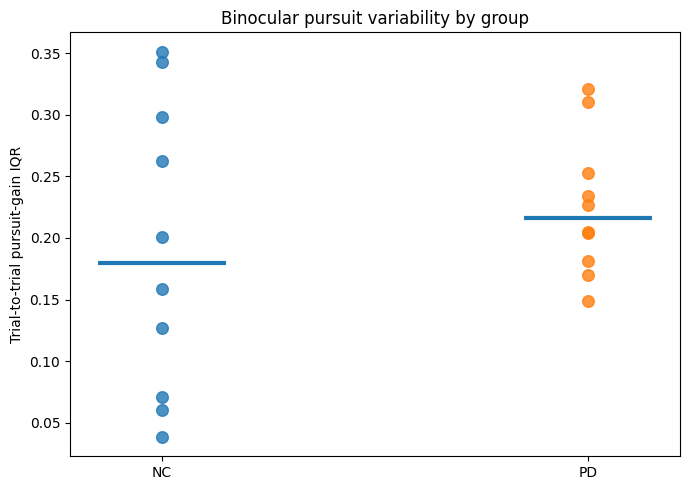

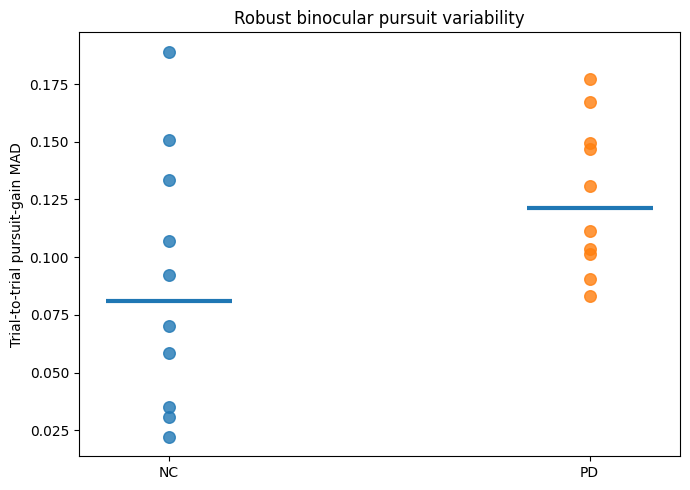


Saved:
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_binocular_pursuit_variability_participant.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_binocular_pursuit_variability_results.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_binocular_pursuit_variability_LOO.csv


In [6]:
# =====================================================================
# FINAL ANALYSIS:
# Is trial-to-trial binocular pursuit-gain variability greater in PD?
#
# Primary outcome:
#   IQR of CLEANED trial-level pursuit gain
#
# Sensitivity outcomes:
#   MAD
#   SD
#
# Participant is the experimental unit.
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu


# =====================================================================
# 1. LOAD CLEANED TRIAL DATA
# =====================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")

trial_path = (
    BASE
    / "analysis_output"
    / "Wu_binocular_pursuit_cleaning_QC.csv"
)

df = pd.read_csv(trial_path)

print("Rows loaded:", len(df))


# =====================================================================
# 2. KEEP VALID CLEANED TRIALS
# =====================================================================

d = df[
    df["Clean_mean_gain"].notna()
].copy()

print("Valid cleaned trials:", len(d))


# =====================================================================
# 3. PARTICIPANT-LEVEL VARIABILITY
# =====================================================================

def mad(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    return np.nanmedian(
        np.abs(x - med)
    )


participant = (
    d.groupby(
        ["Participant", "Group"]
    )
    .agg(
        N_trials=(
            "Clean_mean_gain",
            "count"
        ),

        Mean_gain=(
            "Clean_mean_gain",
            "mean"
        ),

        Median_gain=(
            "Clean_mean_gain",
            "median"
        ),

        SD_gain=(
            "Clean_mean_gain",
            "std"
        ),

        Q25=(
            "Clean_mean_gain",
            lambda x:
                np.nanpercentile(x, 25)
        ),

        Q75=(
            "Clean_mean_gain",
            lambda x:
                np.nanpercentile(x, 75)
        ),

        MAD_gain=(
            "Clean_mean_gain",
            mad
        )
    )
    .reset_index()
)

participant["IQR_gain"] = (
    participant["Q75"]
    -
    participant["Q25"]
)


print("\n")
print("=" * 80)
print("PARTICIPANT-LEVEL VARIABILITY")
print("=" * 80)

print(
    participant[
        [
            "Participant",
            "Group",
            "N_trials",
            "Mean_gain",
            "Median_gain",
            "IQR_gain",
            "MAD_gain",
            "SD_gain"
        ]
    ]
    .to_string(index=False)
)


# =====================================================================
# 4. GROUP DESCRIPTIVES
# =====================================================================

print("\n")
print("=" * 80)
print("GROUP DESCRIPTIVES")
print("=" * 80)

for metric in [
    "IQR_gain",
    "MAD_gain",
    "SD_gain"
]:

    print(f"\n{metric}")

    print(
        participant.groupby(
            "Group"
        )[metric].agg(
            [
                "count",
                "mean",
                "std",
                "median",
                "min",
                "max"
            ]
        )
    )


# =====================================================================
# 5. MANN-WHITNEY TESTS
# =====================================================================

print("\n")
print("=" * 80)
print("MANN-WHITNEY PD vs NC")
print("=" * 80)

results = []

for metric in [
    "IQR_gain",
    "MAD_gain",
    "SD_gain"
]:

    nc = participant.loc[
        participant["Group"] == "NC",
        metric
    ].dropna().values

    pdv = participant.loc[
        participant["Group"] == "PD",
        metric
    ].dropna().values

    res = mannwhitneyu(
        pdv,
        nc,
        alternative="two-sided"
    )

    # rank-biserial / Cliff-type effect direction
    n1 = len(pdv)
    n2 = len(nc)

    cliff_delta = (
        2 * res.statistic
        / (n1 * n2)
        - 1
    )

    diff_median = (
        np.median(pdv)
        -
        np.median(nc)
    )

    results.append(
        {
            "Metric": metric,
            "PD_median": np.median(pdv),
            "NC_median": np.median(nc),
            "Median_difference_PD_minus_NC":
                diff_median,
            "U": res.statistic,
            "p_value": res.pvalue,
            "Cliff_delta": cliff_delta
        }
    )


results_df = pd.DataFrame(results)

print(
    results_df.to_string(
        index=False
    )
)


# =====================================================================
# 6. EXACT PARTICIPANT-LABEL PERMUTATION
#    PRIMARY METRIC = IQR
#
# 20 participants total:
# choose 10 of 20 as PD
# = 184,756 exact allocations
# =====================================================================

print("\n")
print("=" * 80)
print("EXACT PERMUTATION TEST — IQR")
print("=" * 80)

from itertools import combinations


vals = participant[
    "IQR_gain"
].values

groups = participant[
    "Group"
].values


obs_pd = vals[
    groups == "PD"
]

obs_nc = vals[
    groups == "NC"
]

obs_diff = (
    np.median(obs_pd)
    -
    np.median(obs_nc)
)


n_total = len(vals)
n_pd = np.sum(
    groups == "PD"
)


perm_diffs = []

all_idx = np.arange(
    n_total
)


for pd_idx in combinations(
    all_idx,
    n_pd
):

    pd_idx = np.array(
        pd_idx
    )

    nc_idx = np.setdiff1d(
        all_idx,
        pd_idx
    )

    diff = (
        np.median(
            vals[pd_idx]
        )
        -
        np.median(
            vals[nc_idx]
        )
    )

    perm_diffs.append(
        diff
    )


perm_diffs = np.array(
    perm_diffs
)


perm_p = (
    np.sum(
        np.abs(perm_diffs)
        >=
        abs(obs_diff)
    )
    /
    len(perm_diffs)
)


print(
    "Observed PD - NC median IQR difference:",
    obs_diff
)

print(
    "Exact permutations:",
    len(perm_diffs)
)

print(
    "Exact two-sided permutation p:",
    perm_p
)


# =====================================================================
# 7. PARTICIPANT BOOTSTRAP CI
#    PRIMARY METRIC = IQR
# =====================================================================

print("\n")
print("=" * 80)
print("PARTICIPANT BOOTSTRAP — IQR")
print("=" * 80)

rng = np.random.default_rng(
    12345
)

nc = participant.loc[
    participant["Group"] == "NC",
    "IQR_gain"
].values

pdv = participant.loc[
    participant["Group"] == "PD",
    "IQR_gain"
].values


B = 20000

boot_diff = np.empty(
    B
)


for b in range(B):

    nc_b = rng.choice(
        nc,
        size=len(nc),
        replace=True
    )

    pd_b = rng.choice(
        pdv,
        size=len(pdv),
        replace=True
    )

    boot_diff[b] = (
        np.median(pd_b)
        -
        np.median(nc_b)
    )


ci_low, ci_high = np.percentile(
    boot_diff,
    [2.5, 97.5]
)


print(
    "Observed median difference:",
    np.median(pdv)
    -
    np.median(nc)
)

print(
    "Bootstrap 95% CI:",
    (
        ci_low,
        ci_high
    )
)


# =====================================================================
# 8. LEAVE-ONE-PARTICIPANT-OUT STABILITY
# =====================================================================

print("\n")
print("=" * 80)
print("LEAVE-ONE-PARTICIPANT-OUT STABILITY — IQR")
print("=" * 80)

loo_rows = []


for participant_to_drop in participant[
    "Participant"
].values:

    tmp = participant[
        participant["Participant"]
        != participant_to_drop
    ].copy()

    nc_tmp = tmp.loc[
        tmp["Group"] == "NC",
        "IQR_gain"
    ].values

    pd_tmp = tmp.loc[
        tmp["Group"] == "PD",
        "IQR_gain"
    ].values

    diff = (
        np.median(pd_tmp)
        -
        np.median(nc_tmp)
    )

    test = mannwhitneyu(
        pd_tmp,
        nc_tmp,
        alternative="two-sided"
    )

    loo_rows.append(
        {
            "Dropped":
                participant_to_drop,

            "Median_difference":
                diff,

            "MW_p":
                test.pvalue
        }
    )


loo = pd.DataFrame(
    loo_rows
)


print(
    loo.to_string(
        index=False
    )
)


print("\nLOO difference range:")

print(
    loo[
        "Median_difference"
    ].min(),
    "to",
    loo[
        "Median_difference"
    ].max()
)


print("\nLOO p-value range:")

print(
    loo[
        "MW_p"
    ].min(),
    "to",
    loo[
        "MW_p"
    ].max()
)


# =====================================================================
# 9. PLOT — PARTICIPANT IQR
# =====================================================================

plt.figure(
    figsize=(7, 5)
)

nc_vals = participant.loc[
    participant["Group"] == "NC",
    "IQR_gain"
].values

pd_vals = participant.loc[
    participant["Group"] == "PD",
    "IQR_gain"
].values


x_nc = np.zeros(
    len(nc_vals)
)

x_pd = np.ones(
    len(pd_vals)
)


plt.scatter(
    x_nc,
    nc_vals,
    s=70,
    alpha=0.8
)

plt.scatter(
    x_pd,
    pd_vals,
    s=70,
    alpha=0.8
)


plt.hlines(
    np.median(nc_vals),
    -0.15,
    0.15,
    linewidth=3
)

plt.hlines(
    np.median(pd_vals),
    0.85,
    1.15,
    linewidth=3
)


plt.xticks(
    [0, 1],
    ["NC", "PD"]
)

plt.ylabel(
    "Trial-to-trial pursuit-gain IQR"
)

plt.title(
    "Binocular pursuit variability by group"
)

plt.tight_layout()
plt.show()


# =====================================================================
# 10. PLOT — PARTICIPANT MAD
# =====================================================================

plt.figure(
    figsize=(7, 5)
)

nc_vals = participant.loc[
    participant["Group"] == "NC",
    "MAD_gain"
].values

pd_vals = participant.loc[
    participant["Group"] == "PD",
    "MAD_gain"
].values


plt.scatter(
    np.zeros(len(nc_vals)),
    nc_vals,
    s=70,
    alpha=0.8
)

plt.scatter(
    np.ones(len(pd_vals)),
    pd_vals,
    s=70,
    alpha=0.8
)


plt.hlines(
    np.median(nc_vals),
    -0.15,
    0.15,
    linewidth=3
)

plt.hlines(
    np.median(pd_vals),
    0.85,
    1.15,
    linewidth=3
)


plt.xticks(
    [0, 1],
    ["NC", "PD"]
)

plt.ylabel(
    "Trial-to-trial pursuit-gain MAD"
)

plt.title(
    "Robust binocular pursuit variability"
)

plt.tight_layout()
plt.show()


# =====================================================================
# 11. SAVE
# =====================================================================

participant_path = (
    BASE
    / "analysis_output"
    / "Wu_binocular_pursuit_variability_participant.csv"
)

results_path = (
    BASE
    / "analysis_output"
    / "Wu_binocular_pursuit_variability_results.csv"
)

loo_path = (
    BASE
    / "analysis_output"
    / "Wu_binocular_pursuit_variability_LOO.csv"
)


participant.to_csv(
    participant_path,
    index=False
)

results_df.to_csv(
    results_path,
    index=False
)

loo.to_csv(
    loo_path,
    index=False
)


print("\nSaved:")
print(participant_path)
print(results_path)
print(loo_path)

Participants loaded: 20
Participant Group  N_trials  Mean_gain  Median_gain  IQR_gain  MAD_gain  SD_gain
        NC1    NC        10   0.960686     0.921987  0.201126  0.107207 0.165225
       NC10    NC        10   0.920165     0.922381  0.038404  0.022082 0.052091
        NC2    NC        10   1.055329     1.021842  0.070730  0.030930 0.134249
        NC3    NC        10   0.818690     0.913041  0.351237  0.092285 0.281437
        NC4    NC        10   1.149955     1.131285  0.262303  0.133507 0.211964
        NC5    NC        10   1.115786     1.097928  0.342734  0.189048 0.300800
        NC6    NC        10   1.009415     1.067907  0.158255  0.070143 0.350272
        NC7    NC        10   0.971847     0.938271  0.126658  0.058555 0.107820
        NC8    NC        10   0.908318     0.949157  0.298069  0.150633 0.195857
        NC9    NC        10   0.986169     0.978417  0.059971  0.035189 0.051059
        PD1    PD        10   0.843925     0.911777  0.320525  0.149511 0.248480
    

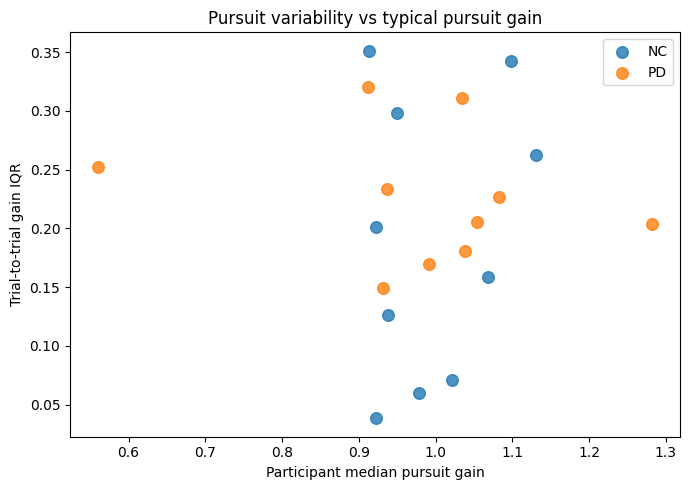

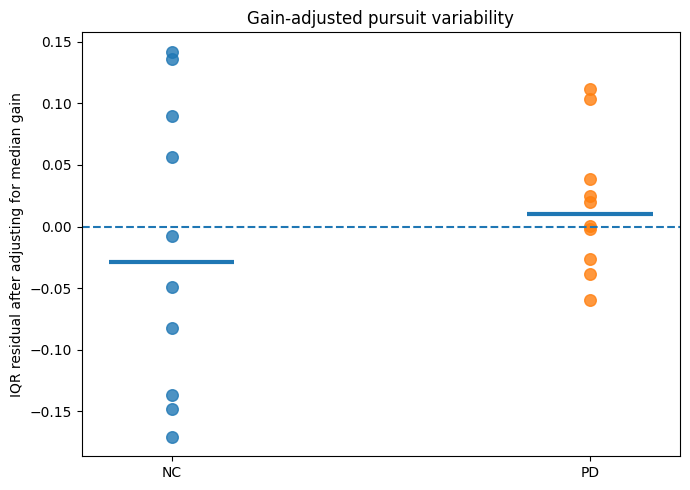


Saved:
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_pursuit_variability_adjusted_for_median_gain.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_pursuit_variability_adjusted_for_mean_gain.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_pursuit_variability_adjusted_participants.csv


In [7]:
# =====================================================================
# ADJUST PURSUIT VARIABILITY FOR EACH PARTICIPANT'S TYPICAL GAIN
#
# Question:
#   Is PD associated with greater trial-to-trial variability
#   after accounting for participant-level pursuit gain?
#
# Primary outcome:
#   IQR_gain
#
# Sensitivity:
#   MAD_gain
#   SD_gain
#
# =====================================================================


# =====================================================================
# 0. IMPORTS
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import spearmanr


# =====================================================================
# 1. LOAD PARTICIPANT-LEVEL FILE
# =====================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")

path = (
    BASE
    / "analysis_output"
    / "Wu_binocular_pursuit_variability_participant.csv"
)

df = pd.read_csv(path)

print("Participants loaded:", len(df))

print(
    df[
        [
            "Participant",
            "Group",
            "N_trials",
            "Mean_gain",
            "Median_gain",
            "IQR_gain",
            "MAD_gain",
            "SD_gain"
        ]
    ].to_string(index=False)
)


# =====================================================================
# 2. CHECK WHETHER VARIABILITY SCALES WITH TYPICAL GAIN
# =====================================================================

print("\n")
print("=" * 85)
print("ASSOCIATION BETWEEN TYPICAL GAIN AND VARIABILITY")
print("=" * 85)

for metric in [
    "IQR_gain",
    "MAD_gain",
    "SD_gain"
]:

    rho, p = spearmanr(
        df["Median_gain"],
        df[metric]
    )

    print(
        f"{metric}: "
        f"Spearman rho = {rho:.4f}, "
        f"p = {p:.6f}"
    )


# =====================================================================
# 3. PRIMARY REGRESSION
#
# IQR_gain ~ Median_gain + Group
#
# HC3 robust SEs because n=20 and possible heteroskedasticity.
# =====================================================================

print("\n")
print("=" * 85)
print("PRIMARY MODEL: IQR_gain ~ Median_gain + Group")
print("=" * 85)

model_iqr = smf.ols(
    "IQR_gain ~ Median_gain + C(Group)",
    data=df
).fit(
    cov_type="HC3"
)

print(
    model_iqr.summary()
)


# =====================================================================
# 4. EXTRACT KEY COEFFICIENTS
# =====================================================================

def extract_group_effect(model, outcome):

    terms = model.params.index.tolist()

    group_term = None

    for term in terms:
        if "C(Group)" in term:
            group_term = term
            break

    if group_term is None:
        return {
            "Outcome": outcome,
            "Group_term": None,
            "PD_adjusted_effect": np.nan,
            "SE": np.nan,
            "p_value": np.nan,
            "CI_low": np.nan,
            "CI_high": np.nan
        }

    ci = model.conf_int().loc[group_term]

    return {
        "Outcome": outcome,
        "Group_term": group_term,
        "PD_adjusted_effect":
            model.params[group_term],
        "SE":
            model.bse[group_term],
        "p_value":
            model.pvalues[group_term],
        "CI_low":
            ci.iloc[0],
        "CI_high":
            ci.iloc[1]
    }


results = []

results.append(
    extract_group_effect(
        model_iqr,
        "IQR_gain"
    )
)


# =====================================================================
# 5. SENSITIVITY MODELS
# =====================================================================

print("\n")
print("=" * 85)
print("SENSITIVITY MODEL: MAD_gain ~ Median_gain + Group")
print("=" * 85)

model_mad = smf.ols(
    "MAD_gain ~ Median_gain + C(Group)",
    data=df
).fit(
    cov_type="HC3"
)

print(
    model_mad.summary()
)

results.append(
    extract_group_effect(
        model_mad,
        "MAD_gain"
    )
)


print("\n")
print("=" * 85)
print("SENSITIVITY MODEL: SD_gain ~ Median_gain + Group")
print("=" * 85)

model_sd = smf.ols(
    "SD_gain ~ Median_gain + C(Group)",
    data=df
).fit(
    cov_type="HC3"
)

print(
    model_sd.summary()
)

results.append(
    extract_group_effect(
        model_sd,
        "SD_gain"
    )
)


# =====================================================================
# 6. SUMMARY TABLE OF ADJUSTED GROUP EFFECTS
# =====================================================================

results_df = pd.DataFrame(
    results
)

print("\n")
print("=" * 85)
print("ADJUSTED PD-vs-NC EFFECTS")
print("=" * 85)

print(
    results_df[
        [
            "Outcome",
            "PD_adjusted_effect",
            "SE",
            "p_value",
            "CI_low",
            "CI_high"
        ]
    ].to_string(
        index=False
    )
)


# =====================================================================
# 7. OPTIONAL: USE MEAN GAIN INSTEAD OF MEDIAN GAIN
#
# Sensitivity only.
# =====================================================================

print("\n")
print("=" * 85)
print("SENSITIVITY: ADJUSTING FOR MEAN GAIN INSTEAD")
print("=" * 85)

mean_adjusted_results = []

for metric in [
    "IQR_gain",
    "MAD_gain",
    "SD_gain"
]:

    model = smf.ols(
        f"{metric} ~ Mean_gain + C(Group)",
        data=df
    ).fit(
        cov_type="HC3"
    )

    tmp = extract_group_effect(
        model,
        metric
    )

    mean_adjusted_results.append(
        tmp
    )


mean_results_df = pd.DataFrame(
    mean_adjusted_results
)

print(
    mean_results_df[
        [
            "Outcome",
            "PD_adjusted_effect",
            "SE",
            "p_value",
            "CI_low",
            "CI_high"
        ]
    ].to_string(
        index=False
    )
)


# =====================================================================
# 8. PLOT — IQR vs MEDIAN GAIN
# =====================================================================

plt.figure(
    figsize=(7, 5)
)

for group in [
    "NC",
    "PD"
]:

    sub = df[
        df["Group"] == group
    ]

    plt.scatter(
        sub["Median_gain"],
        sub["IQR_gain"],
        s=70,
        alpha=0.8,
        label=group
    )


plt.xlabel(
    "Participant median pursuit gain"
)

plt.ylabel(
    "Trial-to-trial gain IQR"
)

plt.title(
    "Pursuit variability vs typical pursuit gain"
)

plt.legend()

plt.tight_layout()
plt.show()


# =====================================================================
# 9. PLOT — ADJUSTED IQR RESIDUALS
#
# First remove dependence of IQR on median gain.
# Then look at residual variability by group.
# =====================================================================

gain_only_model = smf.ols(
    "IQR_gain ~ Median_gain",
    data=df
).fit()

df[
    "IQR_adjusted_residual"
] = (
    gain_only_model.resid
)


plt.figure(
    figsize=(7, 5)
)

nc = df.loc[
    df["Group"] == "NC",
    "IQR_adjusted_residual"
].values

pdv = df.loc[
    df["Group"] == "PD",
    "IQR_adjusted_residual"
].values


plt.scatter(
    np.zeros(len(nc)),
    nc,
    s=70,
    alpha=0.8
)

plt.scatter(
    np.ones(len(pdv)),
    pdv,
    s=70,
    alpha=0.8
)


plt.hlines(
    np.median(nc),
    -0.15,
    0.15,
    linewidth=3
)

plt.hlines(
    np.median(pdv),
    0.85,
    1.15,
    linewidth=3
)


plt.axhline(
    0,
    linestyle="--"
)

plt.xticks(
    [0, 1],
    ["NC", "PD"]
)

plt.ylabel(
    "IQR residual after adjusting for median gain"
)

plt.title(
    "Gain-adjusted pursuit variability"
)

plt.tight_layout()
plt.show()


# =====================================================================
# 10. SAVE RESULTS
# =====================================================================

out1 = (
    BASE
    / "analysis_output"
    / "Wu_pursuit_variability_adjusted_for_median_gain.csv"
)

out2 = (
    BASE
    / "analysis_output"
    / "Wu_pursuit_variability_adjusted_for_mean_gain.csv"
)

out3 = (
    BASE
    / "analysis_output"
    / "Wu_pursuit_variability_adjusted_participants.csv"
)


results_df.to_csv(
    out1,
    index=False
)

mean_results_df.to_csv(
    out2,
    index=False
)

df.to_csv(
    out3,
    index=False
)


print("\nSaved:")
print(out1)
print(out2)
print(out3)

In [ ]:
Additional checks by comparing with Wu's.'

FILES
Our participant file:
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_binocular_pursuit_variability_participant.csv

Wu supplementary candidates:
/content/drive/MyDrive/Wu_PD/peerj-06-5442-s002.xlsx

Using Wu supplement:
/content/drive/MyDrive/Wu_PD/peerj-06-5442-s002.xlsx


OUR RECONSTRUCTED VALUES
Participant Group  N_trials  Mean_gain  Median_gain  Our_mean_velocity  Our_median_velocity
        NC1    NC        10   0.960686     0.921987           9.606856             9.219871
       NC10    NC        10   0.920165     0.922381           9.201646             9.223815
        NC2    NC        10   1.055329     1.021842          10.553289            10.218418
        NC3    NC        10   0.818690     0.913041           8.186903             9.130405
        NC4    NC        10   1.149955     1.131285          11.499546            11.312851
        NC5    NC        10   1.115786     1.097928          11.157858            10.979284
        NC6    NC        10   1.009415     1.0679

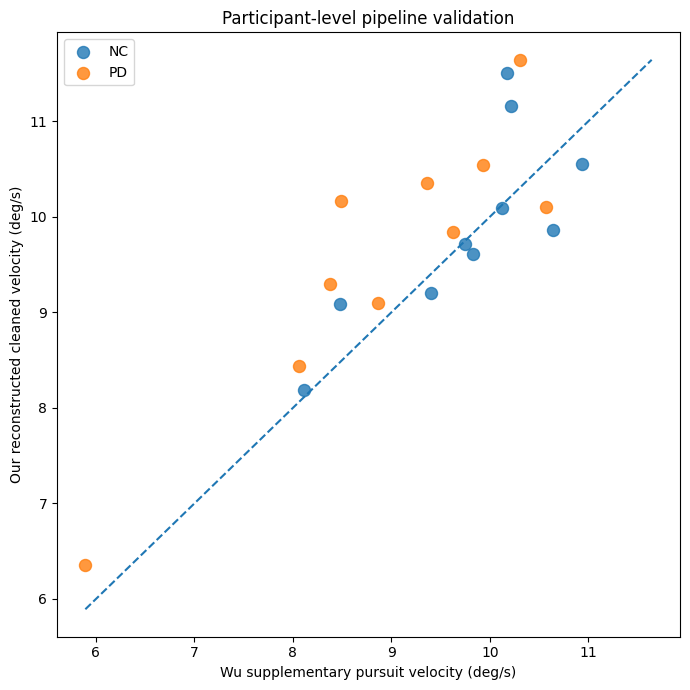

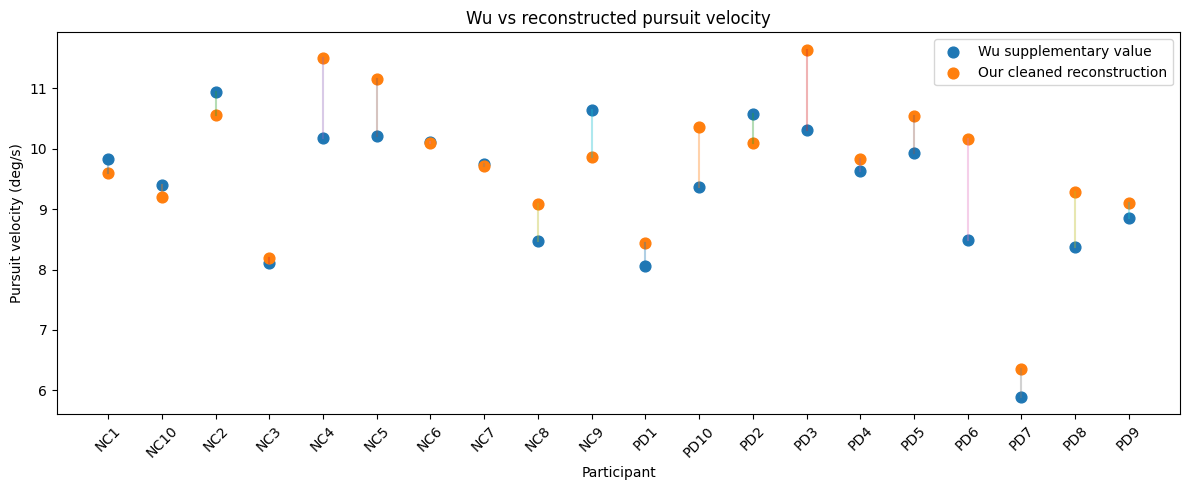

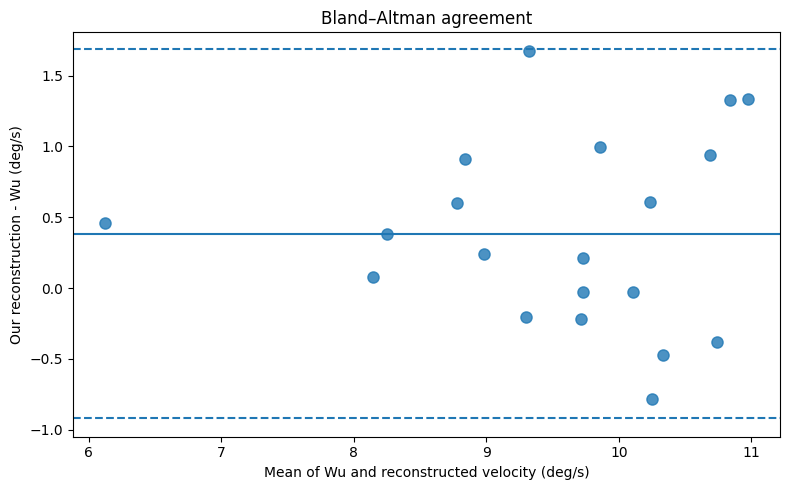


Bland–Altman:
Bias = 0.3829 deg/s
95% limits of agreement = [-0.9193, 1.6850]


SAVED
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_pipeline_validation_participants.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_pipeline_validation_metrics.csv

PIPELINE VALIDATION COMPLETE.


In [8]:
# ======================================================================
# VALIDATE RECONSTRUCTED PURSUIT PIPELINE AGAINST WU SUPPLEMENTARY DATA
#
# Compares our cleaned BINOCULAR pursuit estimates against the
# participant-level PursuitVelocity values supplied by Wu et al.
#
# This is the most important pipeline-validation step.
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    pearsonr,
    spearmanr,
    mannwhitneyu,
    ttest_ind
)

import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# ======================================================================
# 1. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")

OUT = BASE / "analysis_output"
OUT.mkdir(parents=True, exist_ok=True)


# Our reconstructed participant-level results
OUR_FILE = (
    OUT
    / "Wu_binocular_pursuit_variability_participant.csv"
)


# ======================================================================
# 2. FIND WU SUPPLEMENTARY XLSX
# ======================================================================

xlsx_candidates = list(
    BASE.rglob("peerj-06-5442-s002.xlsx")
)

# Also allow any similarly named supplement
if len(xlsx_candidates) == 0:
    xlsx_candidates = [
        p for p in BASE.rglob("*.xlsx")
        if (
            "5442" in p.name.lower()
            or
            "s002" in p.name.lower()
        )
    ]


print("=" * 90)
print("FILES")
print("=" * 90)

print("Our participant file:")
print(OUR_FILE)

print("\nWu supplementary candidates:")

for p in xlsx_candidates:
    print(p)


if not OUR_FILE.exists():
    raise FileNotFoundError(
        f"Could not find our participant file:\n{OUR_FILE}"
    )


if len(xlsx_candidates) == 0:
    raise FileNotFoundError(
        "\nCould not find peerj-06-5442-s002.xlsx in Wu_PD.\n"
        "Upload/copy that supplementary file into:\n"
        "/content/drive/MyDrive/Wu_PD/\n"
        "and rerun this cell."
    )


WU_FILE = xlsx_candidates[0]

print("\nUsing Wu supplement:")
print(WU_FILE)


# ======================================================================
# 3. LOAD OUR RECONSTRUCTED PARTICIPANT RESULTS
# ======================================================================

ours = pd.read_csv(
    OUR_FILE
)


# Keep PD + NC
ours = ours[
    ours["Group"].isin(
        ["PD", "NC"]
    )
].copy()


# Convert cleaned pursuit gain to velocity
#
# Target speed = 10 deg/s
#
# We use BOTH:
#   participant mean cleaned gain
#   participant median cleaned gain
#
# Wu's exact participant aggregation procedure may not be identical,
# so this lets us see which tracks their published values better.
TARGET_SPEED = 10.0

ours["Our_mean_velocity"] = (
    ours["Mean_gain"]
    * TARGET_SPEED
)

ours["Our_median_velocity"] = (
    ours["Median_gain"]
    * TARGET_SPEED
)


print("\n")
print("=" * 90)
print("OUR RECONSTRUCTED VALUES")
print("=" * 90)

print(
    ours[
        [
            "Participant",
            "Group",
            "N_trials",
            "Mean_gain",
            "Median_gain",
            "Our_mean_velocity",
            "Our_median_velocity"
        ]
    ].to_string(
        index=False
    )
)


# ======================================================================
# 4. LOAD WU'S ORIGINAL PURSUIT VELOCITIES
# ======================================================================

wu = pd.read_excel(
    WU_FILE,
    sheet_name="PursuitVelocity"
)


# Clean column names
wu.columns = [
    str(c).strip()
    for c in wu.columns
]


print("\n")
print("=" * 90)
print("WU SUPPLEMENT — RAW PURSUIT VELOCITY TABLE")
print("=" * 90)

print(
    wu.to_string(
        index=False
    )
)


# Expected columns:
#   Type
#   Velo

if "Type" not in wu.columns:
    raise ValueError(
        f"'Type' column not found. Columns were: {wu.columns.tolist()}"
    )

if "Velo" not in wu.columns:
    raise ValueError(
        f"'Velo' column not found. Columns were: {wu.columns.tolist()}"
    )


wu["Type"] = (
    wu["Type"]
    .astype(str)
    .str.strip()
    .str.upper()
)

wu["Velo"] = pd.to_numeric(
    wu["Velo"],
    errors="coerce"
)


# ======================================================================
# 5. ASSIGN PARTICIPANT IDs
#
# Supplement ordering is:
#   PD rows 1–10
#   NC rows 1–10
#   YC rows 1–10
#
# We only match PD and NC here.
# ======================================================================

matched_rows = []

for group in ["PD", "NC"]:

    sub = wu[
        wu["Type"] == group
    ].copy()

    sub = sub.reset_index(
        drop=True
    )

    sub["Participant"] = [
        f"{group}{i+1}"
        for i in range(
            len(sub)
        )
    ]

    matched_rows.append(
        sub
    )


wu_pdn = pd.concat(
    matched_rows,
    ignore_index=True
)

wu_pdn = wu_pdn.rename(
    columns={
        "Velo":
            "Wu_velocity"
    }
)


print("\n")
print("=" * 90)
print("WU PD + NC VALUES WITH PARTICIPANT IDs")
print("=" * 90)

print(
    wu_pdn[
        [
            "Participant",
            "Type",
            "Wu_velocity"
        ]
    ].to_string(
        index=False
    )
)


# ======================================================================
# 6. MERGE OUR VALUES WITH WU
# ======================================================================

merged = ours.merge(
    wu_pdn[
        [
            "Participant",
            "Wu_velocity"
        ]
    ],
    on="Participant",
    how="inner"
)


print("\n")
print("=" * 90)
print("MATCHED PARTICIPANTS")
print("=" * 90)

print(
    merged[
        [
            "Participant",
            "Group",
            "Wu_velocity",
            "Our_mean_velocity",
            "Our_median_velocity"
        ]
    ].to_string(
        index=False
    )
)


print(
    "\nMatched participants:",
    len(merged)
)


# ======================================================================
# 7. VALIDATION FUNCTION
# ======================================================================

def validate_against_wu(df, our_col):

    x = df["Wu_velocity"].values
    y = df[our_col].values

    good = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[good]
    y = y[good]

    diff = y - x

    pearson_r, pearson_p = pearsonr(
        x,
        y
    )

    spearman_r, spearman_p = spearmanr(
        x,
        y
    )

    mae = np.mean(
        np.abs(diff)
    )

    rmse = np.sqrt(
        np.mean(
            diff ** 2
        )
    )

    bias = np.mean(
        diff
    )

    sd_diff = np.std(
        diff,
        ddof=1
    )

    loa_low = (
        bias
        -
        1.96 * sd_diff
    )

    loa_high = (
        bias
        +
        1.96 * sd_diff
    )

    return {

        "Our_metric":
            our_col,

        "N":
            len(x),

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_r,

        "Spearman_p":
            spearman_p,

        "MAE_deg_s":
            mae,

        "RMSE_deg_s":
            rmse,

        "Mean_bias_deg_s":
            bias,

        "LoA_low":
            loa_low,

        "LoA_high":
            loa_high
    }


# ======================================================================
# 8. VALIDATE BOTH OUR MEAN AND MEDIAN AGGREGATION
# ======================================================================

validation_results = pd.DataFrame(
    [
        validate_against_wu(
            merged,
            "Our_mean_velocity"
        ),

        validate_against_wu(
            merged,
            "Our_median_velocity"
        )
    ]
)


print("\n")
print("=" * 90)
print("DIRECT VALIDATION AGAINST WU PARTICIPANT VELOCITIES")
print("=" * 90)

print(
    validation_results.to_string(
        index=False
    )
)


# ======================================================================
# 9. GROUP DESCRIPTIVES — WU VALUES
# ======================================================================

print("\n")
print("=" * 90)
print("WU ORIGINAL GROUP DESCRIPTIVES")
print("=" * 90)

print(
    wu_pdn.groupby(
        "Type"
    )[
        "Wu_velocity"
    ].agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


# ======================================================================
# 10. GROUP DESCRIPTIVES — OUR RECONSTRUCTION
# ======================================================================

print("\n")
print("=" * 90)
print("OUR RECONSTRUCTED GROUP DESCRIPTIVES")
print("=" * 90)

print(
    merged.groupby(
        "Group"
    )[
        [
            "Our_mean_velocity",
            "Our_median_velocity"
        ]
    ].agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


# ======================================================================
# 11. WU PD-vs-NC COMPARISON
#
# This is NOT meant to replace Wu's reported Tukey comparison.
# It simply checks the raw PD-vs-NC participant values directly.
# ======================================================================

wu_pd = wu_pdn.loc[
    wu_pdn["Type"] == "PD",
    "Wu_velocity"
].dropna().values

wu_nc = wu_pdn.loc[
    wu_pdn["Type"] == "NC",
    "Wu_velocity"
].dropna().values


wu_mw = mannwhitneyu(
    wu_pd,
    wu_nc,
    alternative="two-sided"
)

wu_t = ttest_ind(
    wu_pd,
    wu_nc,
    equal_var=False
)


print("\n")
print("=" * 90)
print("WU VALUES: PD vs NC")
print("=" * 90)

print(
    "PD mean:",
    np.mean(wu_pd)
)

print(
    "NC mean:",
    np.mean(wu_nc)
)

print(
    "PD median:",
    np.median(wu_pd)
)

print(
    "NC median:",
    np.median(wu_nc)
)

print(
    "\nMann-Whitney:"
)

print(
    f"U = {wu_mw.statistic:.3f}, "
    f"p = {wu_mw.pvalue:.6f}"
)

print(
    "\nWelch t-test:"
)

print(
    f"t = {wu_t.statistic:.3f}, "
    f"p = {wu_t.pvalue:.6f}"
)


# ======================================================================
# 12. OUR PD-vs-NC COMPARISON
# ======================================================================

our_pd = merged.loc[
    merged["Group"] == "PD",
    "Our_mean_velocity"
].dropna().values

our_nc = merged.loc[
    merged["Group"] == "NC",
    "Our_mean_velocity"
].dropna().values


our_mw = mannwhitneyu(
    our_pd,
    our_nc,
    alternative="two-sided"
)

our_t = ttest_ind(
    our_pd,
    our_nc,
    equal_var=False
)


print("\n")
print("=" * 90)
print("OUR CLEANED VALUES: PD vs NC")
print("=" * 90)

print(
    "PD mean:",
    np.mean(our_pd)
)

print(
    "NC mean:",
    np.mean(our_nc)
)

print(
    "PD median:",
    np.median(our_pd)
)

print(
    "NC median:",
    np.median(our_nc)
)

print(
    "\nMann-Whitney:"
)

print(
    f"U = {our_mw.statistic:.3f}, "
    f"p = {our_mw.pvalue:.6f}"
)

print(
    "\nWelch t-test:"
)

print(
    f"t = {our_t.statistic:.3f}, "
    f"p = {our_t.pvalue:.6f}"
)


# ======================================================================
# 13. DOES EACH METHOD GIVE SAME DIRECTION OF GROUP DIFFERENCE?
# ======================================================================

wu_diff = (
    np.mean(wu_pd)
    -
    np.mean(wu_nc)
)

our_diff = (
    np.mean(our_pd)
    -
    np.mean(our_nc)
)


print("\n")
print("=" * 90)
print("GROUP-DIFFERENCE CONSISTENCY")
print("=" * 90)

print(
    f"Wu PD - NC mean velocity difference: "
    f"{wu_diff:.4f} deg/s"
)

print(
    f"Our PD - NC mean velocity difference: "
    f"{our_diff:.4f} deg/s"
)

print(
    "Same direction:",
    np.sign(wu_diff)
    ==
    np.sign(our_diff)
)


# ======================================================================
# 14. OPTIONAL FULL 3-GROUP REPRODUCTION FROM WU SUPPLEMENT
#
# This reproduces the overall PD / NC / YC test using the supplied
# participant-level velocity values.
# ======================================================================

wu_all = wu[
    wu["Type"].isin(
        ["PD", "NC", "YC"]
    )
].copy()


# one-way OLS ANOVA
anova_model = sm.formula.ols(
    "Velo ~ C(Type)",
    data=wu_all
).fit()

anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2
)


print("\n")
print("=" * 90)
print("WU SUPPLEMENT: THREE-GROUP ANOVA")
print("=" * 90)

print(
    anova_table
)


# Tukey
tukey = pairwise_tukeyhsd(
    endog=wu_all["Velo"],
    groups=wu_all["Type"],
    alpha=0.05
)


print("\n")
print("=" * 90)
print("WU SUPPLEMENT: TUKEY HSD")
print("=" * 90)

print(
    tukey
)


# ======================================================================
# 15. PLOT — OUR VS WU PARTICIPANT VELOCITIES
# ======================================================================

plt.figure(
    figsize=(7, 7)
)


for group in [
    "NC",
    "PD"
]:

    sub = merged[
        merged["Group"] == group
    ]

    plt.scatter(
        sub["Wu_velocity"],
        sub["Our_mean_velocity"],
        s=75,
        alpha=0.8,
        label=group
    )


lo = min(
    merged["Wu_velocity"].min(),
    merged["Our_mean_velocity"].min()
)

hi = max(
    merged["Wu_velocity"].max(),
    merged["Our_mean_velocity"].max()
)


plt.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--"
)


plt.xlabel(
    "Wu supplementary pursuit velocity (deg/s)"
)

plt.ylabel(
    "Our reconstructed cleaned velocity (deg/s)"
)

plt.title(
    "Participant-level pipeline validation"
)

plt.legend()

plt.tight_layout()
plt.show()


# ======================================================================
# 16. PLOT — PARTICIPANT-BY-PARTICIPANT VALUES
# ======================================================================

plot_df = merged.sort_values(
    [
        "Group",
        "Participant"
    ]
).reset_index(
    drop=True
)


x = np.arange(
    len(plot_df)
)


plt.figure(
    figsize=(12, 5)
)


plt.scatter(
    x,
    plot_df["Wu_velocity"],
    s=60,
    label="Wu supplementary value"
)

plt.scatter(
    x,
    plot_df["Our_mean_velocity"],
    s=60,
    label="Our cleaned reconstruction"
)


for i in range(
    len(plot_df)
):

    plt.plot(
        [
            i,
            i
        ],
        [
            plot_df.loc[
                i,
                "Wu_velocity"
            ],
            plot_df.loc[
                i,
                "Our_mean_velocity"
            ]
        ],
        alpha=0.35
    )


plt.xticks(
    x,
    plot_df["Participant"],
    rotation=45
)

plt.ylabel(
    "Pursuit velocity (deg/s)"
)

plt.xlabel(
    "Participant"
)

plt.title(
    "Wu vs reconstructed pursuit velocity"
)

plt.legend()

plt.tight_layout()
plt.show()


# ======================================================================
# 17. BLAND-ALTMAN PLOT
# ======================================================================

wu_vals = merged[
    "Wu_velocity"
].values

our_vals = merged[
    "Our_mean_velocity"
].values


means = (
    wu_vals
    +
    our_vals
) / 2

diffs = (
    our_vals
    -
    wu_vals
)


bias = np.mean(
    diffs
)

sd_diff = np.std(
    diffs,
    ddof=1
)

loa_low = (
    bias
    -
    1.96 * sd_diff
)

loa_high = (
    bias
    +
    1.96 * sd_diff
)


plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    means,
    diffs,
    s=65,
    alpha=0.8
)

plt.axhline(
    bias,
    linestyle="-"
)

plt.axhline(
    loa_low,
    linestyle="--"
)

plt.axhline(
    loa_high,
    linestyle="--"
)

plt.xlabel(
    "Mean of Wu and reconstructed velocity (deg/s)"
)

plt.ylabel(
    "Our reconstruction - Wu (deg/s)"
)

plt.title(
    "Bland–Altman agreement"
)

plt.tight_layout()
plt.show()


print("\nBland–Altman:")
print(
    f"Bias = {bias:.4f} deg/s"
)

print(
    f"95% limits of agreement = "
    f"[{loa_low:.4f}, {loa_high:.4f}]"
)


# ======================================================================
# 18. SAVE VALIDATION OUTPUTS
# ======================================================================

merged_path = (
    OUT
    / "Wu_pipeline_validation_participants.csv"
)

validation_path = (
    OUT
    / "Wu_pipeline_validation_metrics.csv"
)


merged.to_csv(
    merged_path,
    index=False
)

validation_results.to_csv(
    validation_path,
    index=False
)


print("\n")
print("=" * 90)
print("SAVED")
print("=" * 90)

print(
    merged_path
)

print(
    validation_path
)

print(
    "\nPIPELINE VALIDATION COMPLETE."
)

Second, do a cleaning sensitivity analysis. Our current filter uses >30°/s OR a robust 6-MAD threshold. A reviewer could reasonably ask, “Would the result change if you chose 25°/s or 35°/s?” We should rerun the whole primary result under a small set of reasonable preprocessing choices. If PD > NC remains numerically consistent, that considerably strengthens the paper.

FILES
PD + NC MAT files found: 20


RAW WINDOW EXTRACTION
Binocular trials extracted: 200

Processing 25 deg/s + 4 MAD ...

Processing 25 deg/s + 6 MAD ...

Processing 25 deg/s + 8 MAD ...

Processing 30 deg/s + 4 MAD ...

Processing 30 deg/s + 6 MAD ...

Processing 30 deg/s + 8 MAD ...

Processing 35 deg/s + 4 MAD ...

Processing 35 deg/s + 6 MAD ...

Processing 35 deg/s + 8 MAD ...

Processing 40 deg/s + 4 MAD ...

Processing 40 deg/s + 6 MAD ...

Processing 40 deg/s + 8 MAD ...


CLEANING SENSITIVITY — PRIMARY IQR RESULT
 Abs_limit_deg_s  MAD_multiplier  Primary_spec  NC_median_IQR  PD_median_IQR  PD_minus_NC     MW_p  Exact_perm_p  Cliff_delta  Bootstrap_CI_low  Bootstrap_CI_high  NC_mean_fraction_removed  PD_mean_fraction_removed  Valid_trials
            25.0             4.0         False       0.140140       0.216219     0.076078 0.140465      0.193412         0.40         -0.074068           0.200265                  0.107026                  0.096329           199
            

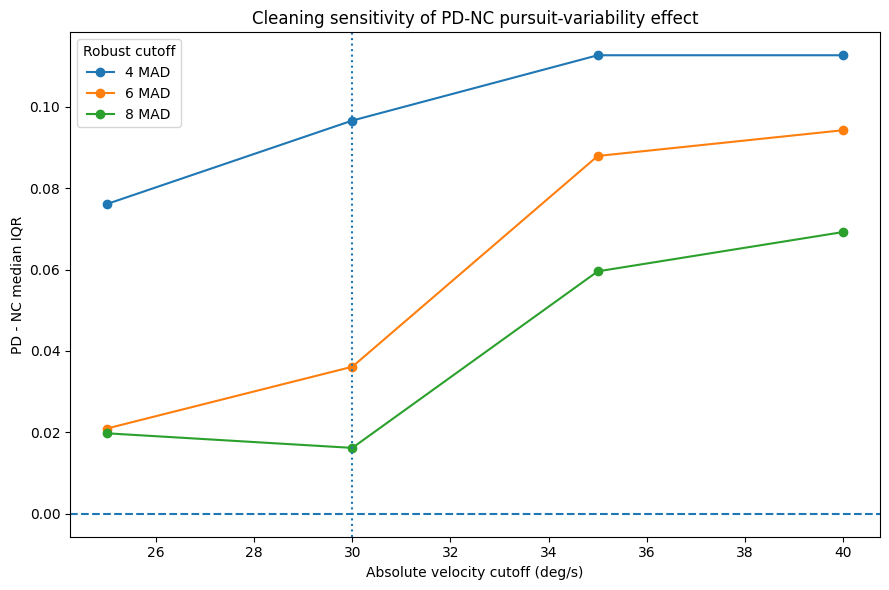

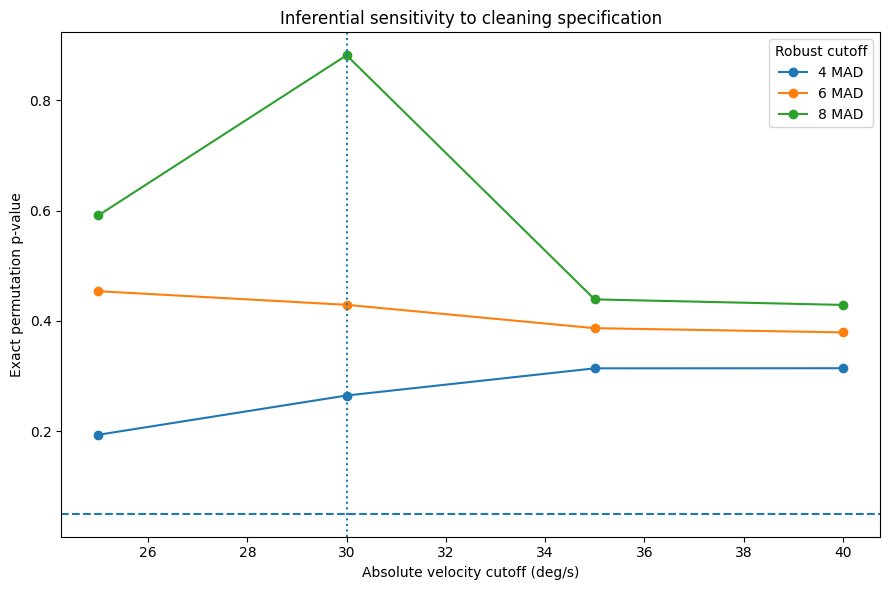

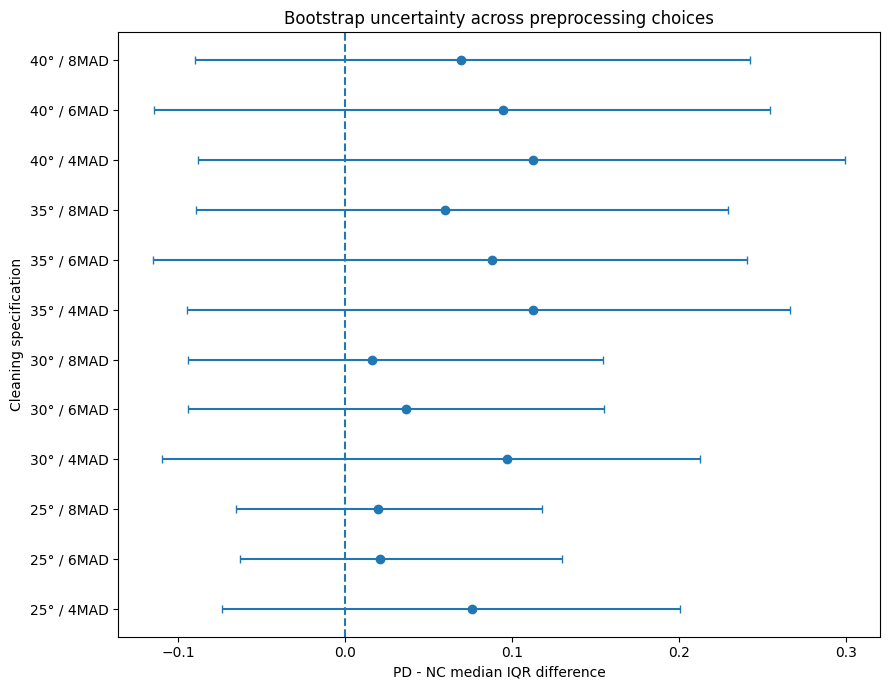

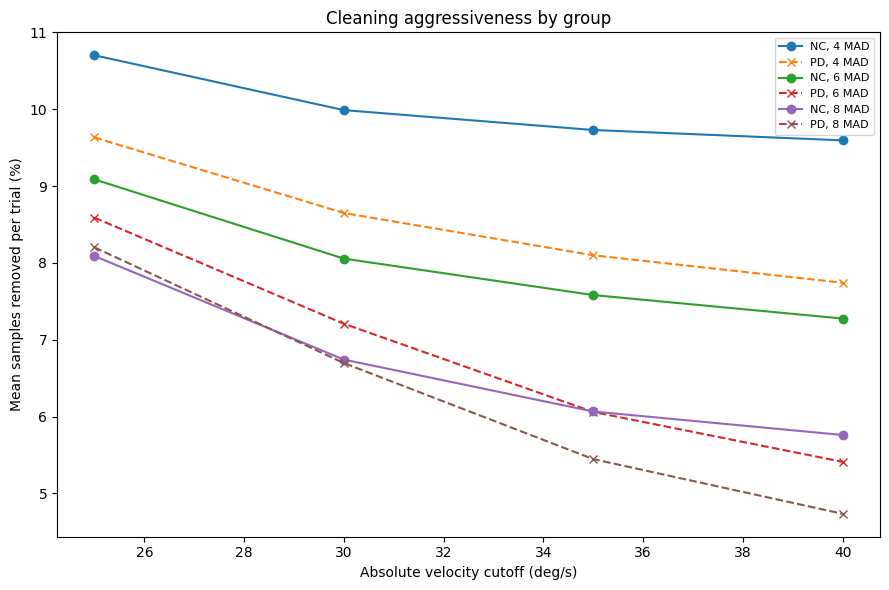



SAVED
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_cleaning_sensitivity_summary.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_cleaning_sensitivity_participants.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_cleaning_sensitivity_trials.csv

CLEANING SENSITIVITY ANALYSIS COMPLETE.


In [9]:
# ======================================================================
# WU DATASET — CLEANING SENSITIVITY ANALYSIS
#
# Question:
#   Does the PD > NC trial-to-trial pursuit-variability tendency remain
#   under reasonable alternative saccade-contamination cleaning rules?
#
# PRIMARY ORIGINAL RULE:
#   absolute velocity > 30 deg/s
#          OR
#   velocity > median + 6 * robust_sigma
#
# SENSITIVITY GRID:
#   absolute limits = 25, 30, 35, 40 deg/s
#   robust cutoffs  = 4, 6, 8 MAD-scaled SD
#
# Outcome:
#   Participant IQR of CLEANED BINOCULAR trial-level pursuit gain
#
# Inference:
#   - participant-level Mann–Whitney
#   - exact label permutation
#   - participant bootstrap CI
#
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

import warnings
warnings.filterwarnings("ignore")


# ======================================================================
# 1. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")

OUT = BASE / "analysis_output"
OUT.mkdir(parents=True, exist_ok=True)

mat_files = sorted([
    f for f in BASE.rglob("*.mat")
    if f.stem.upper().startswith(("PD", "NC"))
])

print("=" * 90)
print("FILES")
print("=" * 90)

print("PD + NC MAT files found:", len(mat_files))

if len(mat_files) != 20:
    print("WARNING: expected 20 participant files.")


# ======================================================================
# 2. CONSTANTS
# ======================================================================

TARGET_SPEED = 10.0

WINDOW_START = 0.500
WINDOW_END   = 0.700

MIN_CLEAN_SAMPLES = 5

ABS_LIMITS = [
    25.0,
    30.0,
    35.0,
    40.0
]

MAD_MULTIPLIERS = [
    4.0,
    6.0,
    8.0
]

PRIMARY_ABS = 30.0
PRIMARY_MAD = 6.0

BOOTSTRAPS = 10000

RNG_SEED = 12345


# ======================================================================
# 3. BASIC MATLAB HELPERS
# ======================================================================

def get_field(trial, field):

    if not hasattr(trial, field):
        return None

    try:
        return np.asarray(
            getattr(trial, field)
        ).squeeze()

    except Exception:
        return None


def as_numeric(x):

    if x is None:
        return None

    try:

        x = np.asarray(
            x,
            dtype=float
        ).squeeze()

        if x.ndim == 0:
            return np.array(
                [float(x)]
            )

        return x.ravel()

    except Exception:
        return None


def scalar_numeric(x):

    if x is None:
        return np.nan

    try:
        return float(
            np.asarray(x).squeeze()
        )

    except Exception:
        return np.nan


# ======================================================================
# 4. TIME-VECTOR HELPERS
# ======================================================================

def time_score(arr, pursuit_time):

    if arr is None or len(arr) < 10:
        return -np.inf

    arr = np.asarray(
        arr,
        dtype=float
    )

    good = np.isfinite(arr)

    if good.sum() < 10:
        return -np.inf

    x = arr[good]

    dx = np.diff(x)

    if len(dx) == 0:
        return -np.inf

    increasing_fraction = np.mean(
        dx > 0
    )

    score = (
        5 * increasing_fraction
    )

    if increasing_fraction > 0.95:
        score += 5


    if np.isfinite(
        pursuit_time
    ):

        xmin = np.nanmin(x)
        xmax = np.nanmax(x)

        if xmin <= pursuit_time <= xmax:
            score += 4

        elif (
            xmin
            <= pursuit_time / 1000
            <= xmax
        ):
            score += 2

        elif (
            xmin / 1000
            <= pursuit_time
            <= xmax / 1000
        ):
            score += 2


    return score


def choose_time_vector(
    trial,
    pursuit_time
):

    candidates = {

        "leftEyexXPos":
            as_numeric(
                get_field(
                    trial,
                    "leftEyexXPos"
                )
            ),

        "rightEyeXPos":
            as_numeric(
                get_field(
                    trial,
                    "rightEyeXPos"
                )
            )
    }


    scores = {

        name:
            time_score(
                arr,
                pursuit_time
            )

        for name, arr
        in candidates.items()
    }


    best = max(
        scores,
        key=scores.get
    )


    if not np.isfinite(
        scores[best]
    ):
        return None, None


    return (
        candidates[best],
        best
    )


def convert_time(
    time,
    pursuit_time
):

    time = np.asarray(
        time,
        dtype=float
    )

    dt = np.diff(time)

    good_dt = dt[
        np.isfinite(dt)
        &
        (dt > 0)
    ]

    if len(good_dt) == 0:
        return None, np.nan, np.nan


    med_dt = np.nanmedian(
        good_dt
    )


    if med_dt > 0.5:

        time_sec = (
            time / 1000.0
        )

        pursuit_sec = (
            pursuit_time / 1000.0
        )

    else:

        time_sec = time.copy()

        pursuit_sec = (
            pursuit_time
        )

        if (
            np.isfinite(
                pursuit_sec
            )
            and
            pursuit_sec
            >
            np.nanmax(
                time_sec
            ) * 5
        ):
            pursuit_sec /= 1000.0


    dt_sec = np.diff(
        time_sec
    )

    dt_sec = dt_sec[
        np.isfinite(dt_sec)
        &
        (dt_sec > 0)
    ]


    if len(dt_sec):

        sampling_hz = (
            1 /
            np.nanmedian(
                dt_sec
            )
        )

    else:

        sampling_hz = np.nan


    return (
        time_sec,
        pursuit_sec,
        sampling_hz
    )


# ======================================================================
# 5. EXTRACT THE RAW 500–700 ms BINOCULAR VELOCITY WINDOWS ONCE
#
# We store the raw velocity arrays.
# Then every sensitivity specification is applied to identical data.
# ======================================================================

raw_trials = []


for f in mat_files:

    participant = (
        f.stem.split("_")[0]
    )

    group = (
        "PD"
        if participant.upper().startswith("PD")
        else "NC"
    )


    mat = sio.loadmat(
        f,
        squeeze_me=True,
        struct_as_record=False
    )


    if "BinocularTrials" not in mat:
        continue


    trials = np.atleast_1d(
        mat["BinocularTrials"]
    )


    for trial_num, trial in enumerate(
        trials,
        start=1
    ):

        pursuit_time = scalar_numeric(
            get_field(
                trial,
                "timeToPursuit"
            )
        )

        left_vel = as_numeric(
            get_field(
                trial,
                "leftEyeVel"
            )
        )

        right_vel = as_numeric(
            get_field(
                trial,
                "rightEyeVel"
            )
        )


        time_raw, time_field = (
            choose_time_vector(
                trial,
                pursuit_time
            )
        )


        record = {

            "Participant":
                participant,

            "Group":
                group,

            "Trial":
                trial_num,

            "Sampling_Hz":
                np.nan,

            "Left_window":
                np.array([]),

            "Right_window":
                np.array([])
        }


        if (
            time_raw is None
            or
            not np.isfinite(
                pursuit_time
            )
        ):

            raw_trials.append(
                record
            )

            continue


        result = convert_time(
            time_raw,
            pursuit_time
        )


        if result[0] is None:

            raw_trials.append(
                record
            )

            continue


        (
            time_sec,
            pursuit_sec,
            sampling_hz
        ) = result


        record[
            "Sampling_Hz"
        ] = sampling_hz


        mask = (
            np.isfinite(
                time_sec
            )
            &
            (
                time_sec
                >=
                pursuit_sec
                + WINDOW_START
            )
            &
            (
                time_sec
                <=
                pursuit_sec
                + WINDOW_END
            )
        )


        # --------------------------------------------------------------
        # LEFT
        # --------------------------------------------------------------

        if left_vel is not None:

            n = min(
                len(time_sec),
                len(left_vel)
            )

            valid = (
                mask[:n]
                &
                np.isfinite(
                    left_vel[:n]
                )
            )

            record[
                "Left_window"
            ] = (
                left_vel[:n][
                    valid
                ].copy()
            )


        # --------------------------------------------------------------
        # RIGHT
        # --------------------------------------------------------------

        if right_vel is not None:

            n = min(
                len(time_sec),
                len(right_vel)
            )

            valid = (
                mask[:n]
                &
                np.isfinite(
                    right_vel[:n]
                )
            )

            record[
                "Right_window"
            ] = (
                right_vel[:n][
                    valid
                ].copy()
            )


        raw_trials.append(
            record
        )


print("\n")
print("=" * 90)
print("RAW WINDOW EXTRACTION")
print("=" * 90)

print(
    "Binocular trials extracted:",
    len(raw_trials)
)


# ======================================================================
# 6. CLEANING FUNCTION
# ======================================================================

def clean_eye_velocity(
    values,
    abs_limit,
    mad_multiplier
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    speed = np.abs(
        values
    )

    n_raw = len(
        speed
    )


    if n_raw == 0:

        return {
            "clean_mean":
                np.nan,

            "clean_median":
                np.nan,

            "n_raw":
                0,

            "n_clean":
                0,

            "fraction_removed":
                np.nan
        }


    med = np.nanmedian(
        speed
    )


    mad = np.nanmedian(
        np.abs(
            speed - med
        )
    )


    robust_sigma = (
        1.4826
        *
        mad
    )


    if (
        np.isfinite(
            robust_sigma
        )
        and
        robust_sigma > 0
    ):

        robust_limit = (
            med
            +
            mad_multiplier
            *
            robust_sigma
        )

    else:

        robust_limit = np.inf


    contaminated = (
        (speed > abs_limit)
        |
        (speed > robust_limit)
    )


    clean = speed[
        ~contaminated
    ]


    n_clean = len(
        clean
    )


    fraction_removed = (
        (n_raw - n_clean)
        /
        n_raw
    )


    if (
        n_clean
        >=
        MIN_CLEAN_SAMPLES
    ):

        clean_mean = np.nanmean(
            clean
        )

        clean_median = np.nanmedian(
            clean
        )

    else:

        clean_mean = np.nan
        clean_median = np.nan


    return {

        "clean_mean":
            clean_mean,

        "clean_median":
            clean_median,

        "n_raw":
            n_raw,

        "n_clean":
            n_clean,

        "fraction_removed":
            fraction_removed
    }


# ======================================================================
# 7. APPLY ONE CLEANING SPECIFICATION
# ======================================================================

def process_specification(
    raw_trials,
    abs_limit,
    mad_multiplier
):

    rows = []


    for record in raw_trials:

        left = clean_eye_velocity(
            record[
                "Left_window"
            ],
            abs_limit,
            mad_multiplier
        )

        right = clean_eye_velocity(
            record[
                "Right_window"
            ],
            abs_limit,
            mad_multiplier
        )


        eye_means = [
            x["clean_mean"]
            for x in [
                left,
                right
            ]
            if np.isfinite(
                x["clean_mean"]
            )
        ]


        if len(
            eye_means
        ) > 0:

            gain = (
                np.mean(
                    eye_means
                )
                /
                TARGET_SPEED
            )

        else:

            gain = np.nan


        fractions = [
            x["fraction_removed"]
            for x in [
                left,
                right
            ]
            if np.isfinite(
                x["fraction_removed"]
            )
        ]


        if fractions:

            fraction_removed = (
                np.mean(
                    fractions
                )
            )

        else:

            fraction_removed = np.nan


        rows.append(
            {
                "Participant":
                    record[
                        "Participant"
                    ],

                "Group":
                    record[
                        "Group"
                    ],

                "Trial":
                    record[
                        "Trial"
                    ],

                "Sampling_Hz":
                    record[
                        "Sampling_Hz"
                    ],

                "Gain":
                    gain,

                "Fraction_removed":
                    fraction_removed
            }
        )


    return pd.DataFrame(
        rows
    )


# ======================================================================
# 8. PARTICIPANT SUMMARY
# ======================================================================

def participant_summary(
    trial_df
):

    d = trial_df[
        trial_df[
            "Gain"
        ].notna()
    ].copy()


    p = (
        d.groupby(
            [
                "Participant",
                "Group"
            ]
        )
        .agg(

            N_trials=(
                "Gain",
                "count"
            ),

            Mean_gain=(
                "Gain",
                "mean"
            ),

            Median_gain=(
                "Gain",
                "median"
            ),

            Q25=(
                "Gain",
                lambda x:
                    np.nanpercentile(
                        x,
                        25
                    )
            ),

            Q75=(
                "Gain",
                lambda x:
                    np.nanpercentile(
                        x,
                        75
                    )
            ),

            SD_gain=(
                "Gain",
                "std"
            ),

            Mean_fraction_removed=(
                "Fraction_removed",
                "mean"
            )
        )
        .reset_index()
    )


    p[
        "IQR_gain"
    ] = (
        p["Q75"]
        -
        p["Q25"]
    )


    return p


# ======================================================================
# 9. EXACT PERMUTATION TEST
# ======================================================================

def exact_permutation_p(
    participant_df
):

    vals = participant_df[
        "IQR_gain"
    ].values

    groups = participant_df[
        "Group"
    ].values


    obs_pd = vals[
        groups == "PD"
    ]

    obs_nc = vals[
        groups == "NC"
    ]


    observed = (
        np.median(
            obs_pd
        )
        -
        np.median(
            obs_nc
        )
    )


    n_total = len(
        vals
    )

    n_pd = np.sum(
        groups == "PD"
    )

    all_idx = np.arange(
        n_total
    )


    extreme = 0
    total = 0


    for pd_idx_tuple in combinations(
        all_idx,
        n_pd
    ):

        pd_idx = np.asarray(
            pd_idx_tuple
        )

        mask = np.ones(
            n_total,
            dtype=bool
        )

        mask[
            pd_idx
        ] = False


        perm_diff = (
            np.median(
                vals[
                    pd_idx
                ]
            )
            -
            np.median(
                vals[
                    mask
                ]
            )
        )


        if (
            abs(
                perm_diff
            )
            >=
            abs(
                observed
            )
        ):
            extreme += 1


        total += 1


    return (
        observed,
        extreme / total
    )


# ======================================================================
# 10. PARTICIPANT BOOTSTRAP
# ======================================================================

def bootstrap_ci(
    participant_df,
    B=10000,
    seed=12345
):

    rng = np.random.default_rng(
        seed
    )


    nc = participant_df.loc[
        participant_df[
            "Group"
        ] == "NC",
        "IQR_gain"
    ].values


    pdv = participant_df.loc[
        participant_df[
            "Group"
        ] == "PD",
        "IQR_gain"
    ].values


    diffs = np.empty(
        B
    )


    for b in range(B):

        nc_b = rng.choice(
            nc,
            size=len(nc),
            replace=True
        )

        pd_b = rng.choice(
            pdv,
            size=len(pdv),
            replace=True
        )


        diffs[b] = (
            np.median(
                pd_b
            )
            -
            np.median(
                nc_b
            )
        )


    low, high = np.percentile(
        diffs,
        [
            2.5,
            97.5
        ]
    )


    return (
        low,
        high
    )


# ======================================================================
# 11. RUN ALL 12 PREPROCESSING SPECIFICATIONS
# ======================================================================

summary_rows = []

all_participant_results = []
all_trial_results = []


for abs_limit in ABS_LIMITS:

    for mad_mult in MAD_MULTIPLIERS:

        print(
            f"\nProcessing "
            f"{abs_limit:.0f} deg/s + "
            f"{mad_mult:.0f} MAD ..."
        )


        # --------------------------------------------------------------
        # clean trials
        # --------------------------------------------------------------

        trial_df = process_specification(
            raw_trials,
            abs_limit,
            mad_mult
        )


        participant_df = (
            participant_summary(
                trial_df
            )
        )


        # --------------------------------------------------------------
        # labels for saved long-form files
        # --------------------------------------------------------------

        trial_df[
            "Abs_limit"
        ] = abs_limit

        trial_df[
            "MAD_multiplier"
        ] = mad_mult


        participant_df[
            "Abs_limit"
        ] = abs_limit

        participant_df[
            "MAD_multiplier"
        ] = mad_mult


        all_trial_results.append(
            trial_df
        )

        all_participant_results.append(
            participant_df
        )


        # --------------------------------------------------------------
        # group values
        # --------------------------------------------------------------

        nc = participant_df.loc[
            participant_df[
                "Group"
            ] == "NC",
            "IQR_gain"
        ].dropna().values


        pdv = participant_df.loc[
            participant_df[
                "Group"
            ] == "PD",
            "IQR_gain"
        ].dropna().values


        nc_median = np.median(
            nc
        )

        pd_median = np.median(
            pdv
        )


        diff = (
            pd_median
            -
            nc_median
        )


        # --------------------------------------------------------------
        # Mann-Whitney
        # --------------------------------------------------------------

        mw = mannwhitneyu(
            pdv,
            nc,
            alternative="two-sided"
        )


        cliff = (
            2
            *
            mw.statistic
            /
            (
                len(pdv)
                *
                len(nc)
            )
            -
            1
        )


        # --------------------------------------------------------------
        # exact permutation
        # --------------------------------------------------------------

        (
            perm_diff,
            perm_p
        ) = exact_permutation_p(
            participant_df
        )


        # --------------------------------------------------------------
        # bootstrap
        # --------------------------------------------------------------

        (
            ci_low,
            ci_high
        ) = bootstrap_ci(
            participant_df,
            B=BOOTSTRAPS,
            seed=(
                RNG_SEED
                +
                int(
                    abs_limit * 10
                    +
                    mad_mult
                )
            )
        )


        # --------------------------------------------------------------
        # cleaning amount
        # --------------------------------------------------------------

        nc_removed = (
            trial_df.loc[
                trial_df[
                    "Group"
                ] == "NC",
                "Fraction_removed"
            ].mean()
        )

        pd_removed = (
            trial_df.loc[
                trial_df[
                    "Group"
                ] == "PD",
                "Fraction_removed"
            ].mean()
        )


        n_valid_trials = (
            trial_df[
                "Gain"
            ].notna().sum()
        )


        min_trials_subject = (
            participant_df[
                "N_trials"
            ].min()
        )


        is_primary = (
            abs_limit
            ==
            PRIMARY_ABS
            and
            mad_mult
            ==
            PRIMARY_MAD
        )


        summary_rows.append(
            {

                "Abs_limit_deg_s":
                    abs_limit,

                "MAD_multiplier":
                    mad_mult,

                "Primary_spec":
                    is_primary,

                "NC_median_IQR":
                    nc_median,

                "PD_median_IQR":
                    pd_median,

                "PD_minus_NC":
                    diff,

                "MW_U":
                    mw.statistic,

                "MW_p":
                    mw.pvalue,

                "Cliff_delta":
                    cliff,

                "Exact_perm_p":
                    perm_p,

                "Bootstrap_CI_low":
                    ci_low,

                "Bootstrap_CI_high":
                    ci_high,

                "NC_mean_fraction_removed":
                    nc_removed,

                "PD_mean_fraction_removed":
                    pd_removed,

                "Valid_trials":
                    int(
                        n_valid_trials
                    ),

                "Minimum_trials_per_participant":
                    int(
                        min_trials_subject
                    ),

                "PD_greater_than_NC":
                    bool(
                        diff > 0
                    )
            }
        )


# ======================================================================
# 12. RESULTS TABLE
# ======================================================================

results = pd.DataFrame(
    summary_rows
)

results = results.sort_values(
    [
        "Abs_limit_deg_s",
        "MAD_multiplier"
    ]
).reset_index(
    drop=True
)


print("\n")
print("=" * 110)
print("CLEANING SENSITIVITY — PRIMARY IQR RESULT")
print("=" * 110)

display_cols = [

    "Abs_limit_deg_s",
    "MAD_multiplier",
    "Primary_spec",

    "NC_median_IQR",
    "PD_median_IQR",
    "PD_minus_NC",

    "MW_p",
    "Exact_perm_p",
    "Cliff_delta",

    "Bootstrap_CI_low",
    "Bootstrap_CI_high",

    "NC_mean_fraction_removed",
    "PD_mean_fraction_removed",

    "Valid_trials"
]


print(
    results[
        display_cols
    ].to_string(
        index=False
    )
)


# ======================================================================
# 13. OVERALL ROBUSTNESS SUMMARY
# ======================================================================

print("\n")
print("=" * 90)
print("ROBUSTNESS SUMMARY")
print("=" * 90)


n_specs = len(
    results
)

n_positive = int(
    results[
        "PD_greater_than_NC"
    ].sum()
)


print(
    f"Specifications tested: "
    f"{n_specs}"
)

print(
    f"PD > NC in: "
    f"{n_positive}/{n_specs} "
    f"specifications "
    f"({100*n_positive/n_specs:.1f}%)"
)


print(
    "\nPD-NC median IQR difference range:"
)

print(
    f"{results['PD_minus_NC'].min():.6f}"
    " to "
    f"{results['PD_minus_NC'].max():.6f}"
)


print(
    "\nMann-Whitney p-value range:"
)

print(
    f"{results['MW_p'].min():.6f}"
    " to "
    f"{results['MW_p'].max():.6f}"
)


print(
    "\nExact permutation p-value range:"
)

print(
    f"{results['Exact_perm_p'].min():.6f}"
    " to "
    f"{results['Exact_perm_p'].max():.6f}"
)


print(
    "\nBootstrap CI excludes zero in:"
)

ci_excludes_zero = (
    (
        results[
            "Bootstrap_CI_low"
        ] > 0
    )
    |
    (
        results[
            "Bootstrap_CI_high"
        ] < 0
    )
)

print(
    f"{int(ci_excludes_zero.sum())}"
    f"/{n_specs}"
)


# ======================================================================
# 14. PRIMARY SPECIFICATION CHECK
# ======================================================================

primary = results[
    results[
        "Primary_spec"
    ]
].copy()


print("\n")
print("=" * 90)
print("ORIGINAL PRIMARY SPECIFICATION: 30 deg/s + 6 MAD")
print("=" * 90)

print(
    primary[
        display_cols
    ].to_string(
        index=False
    )
)


# ======================================================================
# 15. PLOT — EFFECT SIZE ACROSS CLEANING SPECIFICATIONS
# ======================================================================

plt.figure(
    figsize=(9, 6)
)


for mad_mult in MAD_MULTIPLIERS:

    sub = results[
        results[
            "MAD_multiplier"
        ] == mad_mult
    ]

    plt.plot(
        sub[
            "Abs_limit_deg_s"
        ],
        sub[
            "PD_minus_NC"
        ],
        marker="o",
        label=f"{mad_mult:.0f} MAD"
    )


plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    PRIMARY_ABS,
    linestyle=":"
)


plt.xlabel(
    "Absolute velocity cutoff (deg/s)"
)

plt.ylabel(
    "PD - NC median IQR"
)

plt.title(
    "Cleaning sensitivity of PD-NC pursuit-variability effect"
)

plt.legend(
    title="Robust cutoff"
)

plt.tight_layout()
plt.show()


# ======================================================================
# 16. PLOT — EXACT PERMUTATION P ACROSS SPECIFICATIONS
# ======================================================================

plt.figure(
    figsize=(9, 6)
)


for mad_mult in MAD_MULTIPLIERS:

    sub = results[
        results[
            "MAD_multiplier"
        ] == mad_mult
    ]

    plt.plot(
        sub[
            "Abs_limit_deg_s"
        ],
        sub[
            "Exact_perm_p"
        ],
        marker="o",
        label=f"{mad_mult:.0f} MAD"
    )


plt.axhline(
    0.05,
    linestyle="--"
)

plt.axvline(
    PRIMARY_ABS,
    linestyle=":"
)


plt.xlabel(
    "Absolute velocity cutoff (deg/s)"
)

plt.ylabel(
    "Exact permutation p-value"
)

plt.title(
    "Inferential sensitivity to cleaning specification"
)

plt.legend(
    title="Robust cutoff"
)

plt.tight_layout()
plt.show()


# ======================================================================
# 17. PLOT — BOOTSTRAP ESTIMATE + 95% CI FOR ALL SPECIFICATIONS
# ======================================================================

plot_results = results.copy()

plot_results[
    "Label"
] = (
    plot_results[
        "Abs_limit_deg_s"
    ].astype(
        int
    ).astype(
        str
    )
    +
    "° / "
    +
    plot_results[
        "MAD_multiplier"
    ].astype(
        int
    ).astype(
        str
    )
    +
    "MAD"
)


y = np.arange(
    len(
        plot_results
    )
)


estimate = plot_results[
    "PD_minus_NC"
].values


lower_err = (
    estimate
    -
    plot_results[
        "Bootstrap_CI_low"
    ].values
)

upper_err = (
    plot_results[
        "Bootstrap_CI_high"
    ].values
    -
    estimate
)


plt.figure(
    figsize=(9, 7)
)


plt.errorbar(
    estimate,
    y,
    xerr=[
        lower_err,
        upper_err
    ],
    fmt="o",
    capsize=3
)


plt.axvline(
    0,
    linestyle="--"
)


plt.yticks(
    y,
    plot_results[
        "Label"
    ]
)


plt.xlabel(
    "PD - NC median IQR difference"
)

plt.ylabel(
    "Cleaning specification"
)

plt.title(
    "Bootstrap uncertainty across preprocessing choices"
)

plt.tight_layout()
plt.show()


# ======================================================================
# 18. PLOT — DATA REMOVED
# ======================================================================

plt.figure(
    figsize=(9, 6)
)


for mad_mult in MAD_MULTIPLIERS:

    sub = results[
        results[
            "MAD_multiplier"
        ] == mad_mult
    ]

    plt.plot(
        sub[
            "Abs_limit_deg_s"
        ],
        100
        *
        sub[
            "NC_mean_fraction_removed"
        ],
        marker="o",
        linestyle="-",
        label=f"NC, {mad_mult:.0f} MAD"
    )

    plt.plot(
        sub[
            "Abs_limit_deg_s"
        ],
        100
        *
        sub[
            "PD_mean_fraction_removed"
        ],
        marker="x",
        linestyle="--",
        label=f"PD, {mad_mult:.0f} MAD"
    )


plt.xlabel(
    "Absolute velocity cutoff (deg/s)"
)

plt.ylabel(
    "Mean samples removed per trial (%)"
)

plt.title(
    "Cleaning aggressiveness by group"
)

plt.legend(
    fontsize=8
)

plt.tight_layout()
plt.show()


# ======================================================================
# 19. LONG-FORM FILES
# ======================================================================

all_trials = pd.concat(
    all_trial_results,
    ignore_index=True
)

all_participants = pd.concat(
    all_participant_results,
    ignore_index=True
)


# ======================================================================
# 20. SAVE
# ======================================================================

results_path = (
    OUT
    /
    "Wu_cleaning_sensitivity_summary.csv"
)

participant_path = (
    OUT
    /
    "Wu_cleaning_sensitivity_participants.csv"
)

trial_path = (
    OUT
    /
    "Wu_cleaning_sensitivity_trials.csv"
)


results.to_csv(
    results_path,
    index=False
)

all_participants.to_csv(
    participant_path,
    index=False
)

all_trials.to_csv(
    trial_path,
    index=False
)


print("\n")
print("=" * 90)
print("SAVED")
print("=" * 90)

print(results_path)
print(participant_path)
print(trial_path)

print(
    "\nCLEANING SENSITIVITY ANALYSIS COMPLETE."
)

In [10]:
# ======================================================================
# TRIAL-COUNT / MEASUREMENT-UNCERTAINTY ANALYSIS
#
# Goal:
#   Quantify uncertainty in participant-level IQR estimates caused by
#   having only ~9–10 binocular trials per participant.
#
# Uses:
#   Primary cleaned binocular trial gains from:
#   Wu_binocular_pursuit_cleaning_QC.csv
#
# Outputs:
#   1. Bootstrap CI for each participant's IQR
#   2. Width of participant-level IQR uncertainty
#   3. Bootstrap distribution of PD - NC median IQR difference
#   4. Trial-count sensitivity using subsets of 5,6,7,8,9 trials
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu


# ======================================================================
# 1. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")

OUT = BASE / "analysis_output"
OUT.mkdir(parents=True, exist_ok=True)

TRIAL_FILE = (
    OUT
    / "Wu_binocular_pursuit_cleaning_QC.csv"
)


# ======================================================================
# 2. LOAD CLEANED BINOCULAR TRIAL DATA
# ======================================================================

df = pd.read_csv(
    TRIAL_FILE
)

df = df[
    df["Clean_mean_gain"].notna()
].copy()

print("=" * 90)
print("DATA")
print("=" * 90)

print("Valid cleaned binocular trials:", len(df))

print(
    df.groupby(
        ["Participant", "Group"]
    )["Clean_mean_gain"]
    .count()
)


# ======================================================================
# 3. SETTINGS
# ======================================================================

RNG_SEED = 12345

N_BOOT_PARTICIPANT = 20000
N_BOOT_GROUP = 20000

rng = np.random.default_rng(
    RNG_SEED
)


# ======================================================================
# 4. HELPER
# ======================================================================

def iqr(x):

    x = np.asarray(
        x,
        dtype=float
    )

    return (
        np.percentile(x, 75)
        -
        np.percentile(x, 25)
    )


# ======================================================================
# 5. OBSERVED PARTICIPANT IQR
# ======================================================================

observed = (
    df.groupby(
        ["Participant", "Group"]
    )["Clean_mean_gain"]
    .agg(
        N_trials="count",
        Median_gain="median",
        Observed_IQR=iqr
    )
    .reset_index()
)


print("\n")
print("=" * 90)
print("OBSERVED PARTICIPANT IQR")
print("=" * 90)

print(
    observed.to_string(
        index=False
    )
)


# ======================================================================
# 6. PARTICIPANT-LEVEL TRIAL BOOTSTRAP
#
# For each participant:
# resample their ~10 trials WITH replacement and recompute IQR.
# ======================================================================

participant_rows = []

participant_boot_distributions = {}


for _, row in observed.iterrows():

    participant = row["Participant"]
    group = row["Group"]

    values = df.loc[
        df["Participant"] == participant,
        "Clean_mean_gain"
    ].values

    n = len(values)

    boot_iqr = np.empty(
        N_BOOT_PARTICIPANT
    )


    for b in range(
        N_BOOT_PARTICIPANT
    ):

        sample = rng.choice(
            values,
            size=n,
            replace=True
        )

        boot_iqr[b] = iqr(
            sample
        )


    participant_boot_distributions[
        participant
    ] = boot_iqr


    ci_low, ci_high = np.percentile(
        boot_iqr,
        [2.5, 97.5]
    )

    boot_median = np.median(
        boot_iqr
    )

    boot_sd = np.std(
        boot_iqr,
        ddof=1
    )

    ci_width = (
        ci_high
        -
        ci_low
    )


    participant_rows.append(
        {
            "Participant":
                participant,

            "Group":
                group,

            "N_trials":
                n,

            "Observed_IQR":
                row[
                    "Observed_IQR"
                ],

            "Bootstrap_median_IQR":
                boot_median,

            "Bootstrap_SD_IQR":
                boot_sd,

            "CI_low":
                ci_low,

            "CI_high":
                ci_high,

            "CI_width":
                ci_width
        }
    )


participant_uncertainty = pd.DataFrame(
    participant_rows
)


print("\n")
print("=" * 90)
print("PARTICIPANT IQR UNCERTAINTY")
print("=" * 90)

print(
    participant_uncertainty.to_string(
        index=False
    )
)


# ======================================================================
# 7. GROUP SUMMARY OF PARTICIPANT UNCERTAINTY
# ======================================================================

print("\n")
print("=" * 90)
print("UNCERTAINTY WIDTH BY GROUP")
print("=" * 90)

print(
    participant_uncertainty.groupby(
        "Group"
    )[
        [
            "Bootstrap_SD_IQR",
            "CI_width"
        ]
    ].agg(
        [
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
)


# ======================================================================
# 8. PROPAGATE TRIAL-LEVEL UNCERTAINTY TO GROUP DIFFERENCE
#
# For every bootstrap iteration:
#   - independently resample trials within each participant
#   - calculate participant IQR
#   - compute median PD IQR - median NC IQR
#
# This differs from the earlier participant bootstrap:
# earlier = uncertainty from sampling PARTICIPANTS
# here    = uncertainty from sampling TRIALS WITHIN participants
# ======================================================================

participants = observed[
    "Participant"
].values

groups = observed[
    "Group"
].values


trial_uncertainty_diff = np.empty(
    N_BOOT_GROUP
)


for b in range(
    N_BOOT_GROUP
):

    simulated_iqrs = []


    for participant in participants:

        values = df.loc[
            df["Participant"] == participant,
            "Clean_mean_gain"
        ].values

        n = len(values)

        sample = rng.choice(
            values,
            size=n,
            replace=True
        )

        simulated_iqrs.append(
            iqr(sample)
        )


    simulated_iqrs = np.array(
        simulated_iqrs
    )


    pd_values = simulated_iqrs[
        groups == "PD"
    ]

    nc_values = simulated_iqrs[
        groups == "NC"
    ]


    trial_uncertainty_diff[b] = (
        np.median(pd_values)
        -
        np.median(nc_values)
    )


observed_pd = observed.loc[
    observed["Group"] == "PD",
    "Observed_IQR"
].values

observed_nc = observed.loc[
    observed["Group"] == "NC",
    "Observed_IQR"
].values


observed_diff = (
    np.median(observed_pd)
    -
    np.median(observed_nc)
)


trial_ci_low, trial_ci_high = np.percentile(
    trial_uncertainty_diff,
    [2.5, 97.5]
)


prob_positive = np.mean(
    trial_uncertainty_diff > 0
)


print("\n")
print("=" * 90)
print("GROUP DIFFERENCE UNCERTAINTY FROM LIMITED TRIAL COUNT")
print("=" * 90)

print(
    f"Observed PD - NC median IQR difference: "
    f"{observed_diff:.6f}"
)

print(
    f"Trial-resampling 95% interval: "
    f"[{trial_ci_low:.6f}, {trial_ci_high:.6f}]"
)

print(
    f"Fraction of trial-resampling iterations with PD > NC: "
    f"{prob_positive:.4f}"
)


# ======================================================================
# 9. TRIAL-COUNT SENSITIVITY
#
# What happens if we only had:
# 5, 6, 7, 8, or 9 trials per participant?
#
# We sample WITHOUT replacement from each participant's observed trials.
# ======================================================================

TRIAL_COUNTS = [
    5,
    6,
    7,
    8,
    9
]

N_SUBSAMPLE = 10000

trial_count_rows = []


for k in TRIAL_COUNTS:

    diffs = []

    successful = 0


    for b in range(
        N_SUBSAMPLE
    ):

        participant_iqrs = []
        participant_groups = []


        valid_iteration = True


        for participant in participants:

            values = df.loc[
                df["Participant"] == participant,
                "Clean_mean_gain"
            ].values

            if len(values) < k:

                valid_iteration = False
                break


            sample = rng.choice(
                values,
                size=k,
                replace=False
            )

            participant_iqrs.append(
                iqr(sample)
            )

            participant_groups.append(
                observed.loc[
                    observed[
                        "Participant"
                    ] == participant,
                    "Group"
                ].iloc[0]
            )


        if not valid_iteration:
            continue


        participant_iqrs = np.asarray(
            participant_iqrs
        )

        participant_groups = np.asarray(
            participant_groups
        )


        diff = (
            np.median(
                participant_iqrs[
                    participant_groups == "PD"
                ]
            )
            -
            np.median(
                participant_iqrs[
                    participant_groups == "NC"
                ]
            )
        )


        diffs.append(
            diff
        )

        successful += 1


    diffs = np.asarray(
        diffs
    )


    if len(diffs) == 0:
        continue


    low, high = np.percentile(
        diffs,
        [2.5, 97.5]
    )


    trial_count_rows.append(
        {
            "Trials_per_participant":
                k,

            "Iterations":
                successful,

            "Median_PD_minus_NC":
                np.median(
                    diffs
                ),

            "Mean_PD_minus_NC":
                np.mean(
                    diffs
                ),

            "CI_low":
                low,

            "CI_high":
                high,

            "Probability_PD_greater_NC":
                np.mean(
                    diffs > 0
                )
        }
    )


trial_count_results = pd.DataFrame(
    trial_count_rows
)


print("\n")
print("=" * 90)
print("TRIAL-COUNT SENSITIVITY")
print("=" * 90)

print(
    trial_count_results.to_string(
        index=False
    )
)


# ======================================================================
# 10. OPTIONAL: ADD FULL AVAILABLE-TRIAL RESULT TO TABLE
# ======================================================================

full_row = pd.DataFrame(
    [
        {
            "Trials_per_participant":
                10,

            "Iterations":
                N_BOOT_GROUP,

            "Median_PD_minus_NC":
                np.median(
                    trial_uncertainty_diff
                ),

            "Mean_PD_minus_NC":
                np.mean(
                    trial_uncertainty_diff
                ),

            "CI_low":
                trial_ci_low,

            "CI_high":
                trial_ci_high,

            "Probability_PD_greater_NC":
                prob_positive
        }
    ]
)


trial_count_plot = pd.concat(
    [
        trial_count_results,
        full_row
    ],
    ignore_index=True
)


# ======================================================================
# 11. PLOT — PARTICIPANT IQR WITH TRIAL-BOOTSTRAP CI
# ======================================================================

plot_df = participant_uncertainty.sort_values(
    [
        "Group",
        "Participant"
    ]
).reset_index(
    drop=True
)


x = np.arange(
    len(plot_df)
)


y = plot_df[
    "Observed_IQR"
].values


lower = (
    y
    -
    plot_df[
        "CI_low"
    ].values
)

upper = (
    plot_df[
        "CI_high"
    ].values
    -
    y
)


plt.figure(
    figsize=(12, 6)
)


plt.errorbar(
    x,
    y,
    yerr=[
        lower,
        upper
    ],
    fmt="o",
    capsize=3
)


plt.xticks(
    x,
    plot_df[
        "Participant"
    ],
    rotation=45
)

plt.ylabel(
    "Participant pursuit-gain IQR"
)

plt.xlabel(
    "Participant"
)

plt.title(
    "Measurement uncertainty of participant IQR from ~10 trials"
)

plt.tight_layout()
plt.show()


# ======================================================================
# 12. PLOT — GROUP DIFFERENCE DISTRIBUTION DUE TO TRIAL RESAMPLING
# ======================================================================

plt.figure(
    figsize=(8, 5)
)


plt.hist(
    trial_uncertainty_diff,
    bins=50
)


plt.axvline(
    0,
    linestyle="--"
)

plt.axvline(
    observed_diff,
    linestyle="-"
)


plt.xlabel(
    "PD - NC median IQR difference"
)

plt.ylabel(
    "Bootstrap frequency"
)

plt.title(
    "Uncertainty in group difference from limited trial counts"
)

plt.tight_layout()
plt.show()


# ======================================================================
# 13. PLOT — TRIAL COUNT VS EFFECT UNCERTAINTY
# ======================================================================

plt.figure(
    figsize=(8, 5)
)


x = trial_count_plot[
    "Trials_per_participant"
].values

y = trial_count_plot[
    "Median_PD_minus_NC"
].values

lower = (
    y
    -
    trial_count_plot[
        "CI_low"
    ].values
)

upper = (
    trial_count_plot[
        "CI_high"
    ].values
    -
    y
)


plt.errorbar(
    x,
    y,
    yerr=[
        lower,
        upper
    ],
    marker="o",
    capsize=4
)


plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel(
    "Trials used per participant"
)

plt.ylabel(
    "PD - NC median IQR difference"
)

plt.title(
    "Sensitivity of variability effect to trial count"
)

plt.xticks(
    TRIAL_COUNTS + [10]
)

plt.tight_layout()
plt.show()


# ======================================================================
# 14. PLOT — PROBABILITY EFFECT REMAINS POSITIVE
# ======================================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    trial_count_plot[
        "Trials_per_participant"
    ],
    trial_count_plot[
        "Probability_PD_greater_NC"
    ],
    marker="o"
)


plt.axhline(
    0.5,
    linestyle="--"
)


plt.ylim(
    0,
    1
)

plt.xlabel(
    "Trials used per participant"
)

plt.ylabel(
    "Proportion of resamples with PD > NC"
)

plt.title(
    "Directional stability as a function of trial count"
)

plt.xticks(
    TRIAL_COUNTS + [10]
)

plt.tight_layout()
plt.show()


# ======================================================================
# 15. SAVE
# ======================================================================

participant_path = (
    OUT
    / "Wu_trial_count_uncertainty_participants.csv"
)

trial_count_path = (
    OUT
    / "Wu_trial_count_sensitivity.csv"
)

group_path = (
    OUT
    / "Wu_trial_resampling_group_difference.csv"
)


participant_uncertainty.to_csv(
    participant_path,
    index=False
)

trial_count_plot.to_csv(
    trial_count_path,
    index=False
)

pd.DataFrame(
    {
        "PD_minus_NC_IQR":
            trial_uncertainty_diff
    }
).to_csv(
    group_path,
    index=False
)


print("\n")
print("=" * 90)
print("SAVED")
print("=" * 90)

print(participant_path)
print(trial_count_path)
print(group_path)

print(
    "\nTRIAL-COUNT / MEASUREMENT-UNCERTAINTY ANALYSIS COMPLETE."
)

DATA
Valid cleaned binocular trials: 199
Participant  Group
NC1          NC       10
NC10         NC       10
NC2          NC       10
NC3          NC       10
NC4          NC       10
NC5          NC       10
NC6          NC       10
NC7          NC       10
NC8          NC       10
NC9          NC       10
PD1          PD       10
PD10         PD       10
PD2          PD       10
PD3          PD        9
PD4          PD       10
PD5          PD       10
PD6          PD       10
PD7          PD       10
PD8          PD       10
PD9          PD       10
Name: Clean_mean_gain, dtype: int64


OBSERVED PARTICIPANT IQR
Participant Group  N_trials  Median_gain  Observed_IQR
        NC1    NC        10     0.921987      0.201126
       NC10    NC        10     0.922381      0.038404
        NC2    NC        10     1.021842      0.070730
        NC3    NC        10     0.913041      0.351237
        NC4    NC        10     1.131285      0.262303
        NC5    NC        10     1.097928      0

KeyboardInterrupt: 

4.Fourth, I'd add one complementary analysis, not ten. A particularly useful one would be within-participant trial dynamics: does pursuit gain systematically change across trials (adaptation/fatigue), and does that differ between PD and NC? That distinguishes random trial-to-trial instability from a systematic drift over the session.

DATA
Valid cleaned binocular trials: 199
Participant  Group
NC1          NC       10
             PD        0
NC10         NC       10
             PD        0
NC2          NC       10
             PD        0
NC3          NC       10
             PD        0
NC4          NC       10
             PD        0
NC5          NC       10
             PD        0
NC6          NC       10
             PD        0
NC7          NC       10
             PD        0
NC8          NC       10
             PD        0
NC9          NC       10
             PD        0
PD1          NC        0
             PD       10
PD10         NC        0
             PD       10
PD2          NC        0
             PD       10
PD3          NC        0
             PD        9
PD4          NC        0
             PD       10
PD5          NC        0
             PD       10
PD6          NC        0
             PD       10
PD7          NC        0
             PD       10
PD8          NC        0
             PD

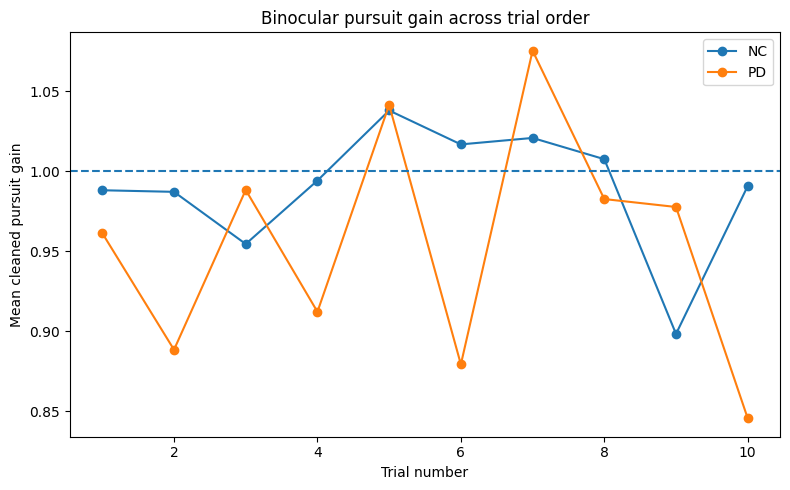

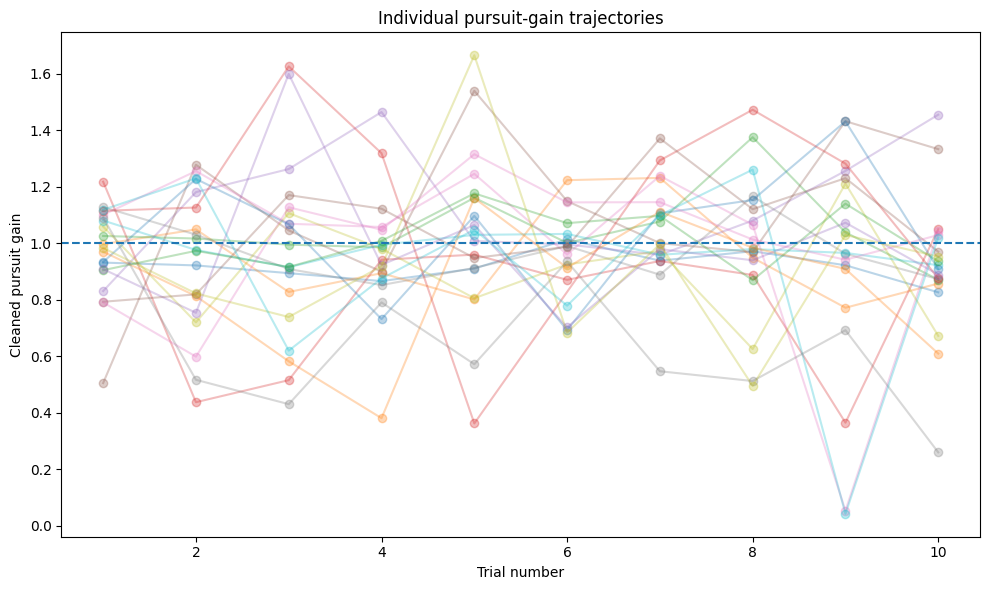

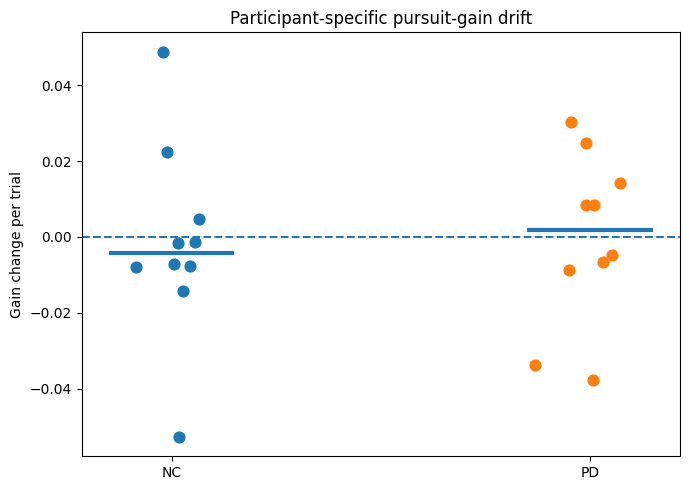



SAVED
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_trial_dynamics_by_trial.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_trial_dynamics_participant_slopes.csv
/content/drive/MyDrive/Wu_PD/analysis_output/Wu_trial_dynamics_clustered_OLS.csv

TRIAL-DYNAMICS ANALYSIS COMPLETE.


In [13]:
# ======================================================================
# WITHIN-PARTICIPANT TRIAL DYNAMICS — ROBUST VERSION
#
# Question:
#   Does pursuit gain change systematically across binocular trials?
#   Does the trajectory differ between PD and NC?
#
# Primary:
#   Mixed model if estimable
#
# Fallback:
#   OLS with participant-clustered standard errors
#
# Complementary:
#   Participant-specific trial slopes
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from scipy.stats import mannwhitneyu


warnings.filterwarnings("ignore")


# ======================================================================
# 1. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")
OUT = BASE / "analysis_output"

TRIAL_FILE = (
    OUT
    / "Wu_binocular_pursuit_cleaning_QC.csv"
)


# ======================================================================
# 2. LOAD DATA
# ======================================================================

df = pd.read_csv(
    TRIAL_FILE
)

df = df[
    df["Clean_mean_gain"].notna()
].copy()


# Make sure Group has the intended reference category
df["Group"] = pd.Categorical(
    df["Group"],
    categories=["NC", "PD"]
)


# Center trial around the midpoint of the 10-trial sequence
# Using 5.5 rather than the sample mean makes interpretation cleaner.
df["Trial_centered"] = (
    df["Trial"] - 5.5
)


print("=" * 90)
print("DATA")
print("=" * 90)

print(
    "Valid cleaned binocular trials:",
    len(df)
)

print(
    df.groupby(
        ["Participant", "Group"],
        observed=False
    )["Clean_mean_gain"]
    .count()
)

print(
    "\nTrial range:",
    df["Trial"].min(),
    "to",
    df["Trial"].max()
)


# ======================================================================
# 3. DESCRIPTIVES BY TRIAL
# ======================================================================

trial_summary = (
    df.groupby(
        ["Group", "Trial"],
        observed=False
    )
    .agg(
        N=("Clean_mean_gain", "count"),
        Mean_gain=("Clean_mean_gain", "mean"),
        Median_gain=("Clean_mean_gain", "median"),
        SD_gain=("Clean_mean_gain", "std")
    )
    .reset_index()
)


print("\n")
print("=" * 90)
print("GAIN BY TRIAL NUMBER")
print("=" * 90)

print(
    trial_summary.to_string(
        index=False
    )
)


# ======================================================================
# 4. TRY MIXED MODEL USING MULTIPLE OPTIMIZERS
# ======================================================================

print("\n")
print("=" * 90)
print("MIXED MODEL ATTEMPT")
print("=" * 90)


mixed_formula = (
    "Clean_mean_gain ~ Trial_centered * C(Group)"
)


mixed_model = smf.mixedlm(
    mixed_formula,
    data=df,
    groups=df["Participant"],
    re_formula="1"
)


mixed_fit = None
mixed_method_used = None


attempts = [
    ("lbfgs", True),
    ("bfgs", True),
    ("cg", True),
    ("powell", True),
    ("lbfgs", False),
    ("bfgs", False),
    ("powell", False),
]


for method, reml in attempts:

    try:

        print(
            f"Trying method={method}, REML={reml} ..."
        )

        fit = mixed_model.fit(
            method=method,
            reml=reml,
            maxiter=5000,
            disp=False
        )

        if np.all(
            np.isfinite(
                fit.params
            )
        ):

            mixed_fit = fit
            mixed_method_used = (
                method,
                reml
            )

            print(
                "SUCCESS"
            )

            break

    except Exception as e:

        print(
            f"Failed: "
            f"{type(e).__name__}: {e}"
        )


# ======================================================================
# 5. REPORT MIXED MODEL IF SUCCESSFUL
# ======================================================================

if mixed_fit is not None:

    print("\n")
    print("=" * 90)
    print("MIXED MODEL RESULT")
    print("=" * 90)

    print(
        f"Optimizer: "
        f"{mixed_method_used[0]}"
    )

    print(
        f"REML: "
        f"{mixed_method_used[1]}"
    )

    print(
        mixed_fit.summary()
    )


    params = mixed_fit.params
    pvals = mixed_fit.pvalues
    conf = mixed_fit.conf_int()


    trial_term = "Trial_centered"

    interaction_term = (
        "Trial_centered:C(Group)[T.PD]"
    )


    if trial_term in params.index:

        print(
            "\nNC trial slope:"
        )

        print(
            f"beta = "
            f"{params[trial_term]:.6f}"
        )

        print(
            f"p = "
            f"{pvals[trial_term]:.6f}"
        )

        print(
            f"95% CI = "
            f"[{conf.loc[trial_term, 0]:.6f}, "
            f"{conf.loc[trial_term, 1]:.6f}]"
        )


    if interaction_term in params.index:

        print(
            "\nTrial × PD interaction:"
        )

        print(
            f"beta = "
            f"{params[interaction_term]:.6f}"
        )

        print(
            f"p = "
            f"{pvals[interaction_term]:.6f}"
        )

        print(
            f"95% CI = "
            f"[{conf.loc[interaction_term, 0]:.6f}, "
            f"{conf.loc[interaction_term, 1]:.6f}]"
        )


        nc_slope = (
            params[
                trial_term
            ]
        )

        pd_slope = (
            params[
                trial_term
            ]
            +
            params[
                interaction_term
            ]
        )


        print(
            f"\nEstimated NC slope: "
            f"{nc_slope:.6f}"
        )

        print(
            f"Estimated PD slope: "
            f"{pd_slope:.6f}"
        )

        print(
            f"PD - NC slope difference: "
            f"{params[interaction_term]:.6f}"
        )


else:

    print("\n")
    print(
        "Mixed model could not be estimated "
        "reliably with available optimizers."
    )


# ======================================================================
# 6. CLUSTER-ROBUST OLS
#
# This is the robust fallback / confirmatory model.
#
# It estimates the same fixed effects:
#
# Gain ~ Trial + Group + Trial×Group
#
# but calculates SEs clustered by participant.
#
# This directly accounts for non-independence of repeated trials.
# ======================================================================

print("\n")
print("=" * 90)
print("OLS WITH PARTICIPANT-CLUSTERED STANDARD ERRORS")
print("=" * 90)


ols = smf.ols(
    mixed_formula,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups":
            df["Participant"]
    }
)


print(
    ols.summary()
)


trial_term = "Trial_centered"

interaction_term = (
    "Trial_centered:C(Group)[T.PD]"
)


print("\n")
print("=" * 90)
print("KEY CLUSTER-ROBUST RESULTS")
print("=" * 90)


for term in [
    trial_term,
    interaction_term
]:

    coef = ols.params[
        term
    ]

    p = ols.pvalues[
        term
    ]

    ci = ols.conf_int().loc[
        term
    ]


    print(
        f"\n{term}"
    )

    print(
        f"  beta = "
        f"{coef:.6f}"
    )

    print(
        f"  p = "
        f"{p:.6f}"
    )

    print(
        f"  95% CI = "
        f"[{ci.iloc[0]:.6f}, "
        f"{ci.iloc[1]:.6f}]"
    )


# Group-specific slopes

nc_slope_ols = (
    ols.params[
        trial_term
    ]
)

pd_slope_ols = (
    ols.params[
        trial_term
    ]
    +
    ols.params[
        interaction_term
    ]
)


print("\n")
print("=" * 90)
print("GROUP-SPECIFIC OLS SLOPES")
print("=" * 90)

print(
    f"NC slope per trial: "
    f"{nc_slope_ols:.6f}"
)

print(
    f"PD slope per trial: "
    f"{pd_slope_ols:.6f}"
)

print(
    f"PD - NC slope difference: "
    f"{ols.params[interaction_term]:.6f}"
)


# ======================================================================
# 7. PARTICIPANT-SPECIFIC LINEAR SLOPES
# ======================================================================

slope_rows = []


for (
    participant,
    group
), sub in df.groupby(
    ["Participant", "Group"],
    observed=True
):

    x = sub[
        "Trial"
    ].to_numpy(
        dtype=float
    )

    y = sub[
        "Clean_mean_gain"
    ].to_numpy(
        dtype=float
    )


    slope, intercept = np.polyfit(
        x,
        y,
        1
    )


    slope_rows.append(
        {
            "Participant":
                participant,

            "Group":
                str(group),

            "N_trials":
                len(sub),

            "Slope_gain_per_trial":
                slope,

            "Intercept":
                intercept
        }
    )


slopes = pd.DataFrame(
    slope_rows
)


print("\n")
print("=" * 90)
print("PARTICIPANT-SPECIFIC SLOPES")
print("=" * 90)

print(
    slopes.to_string(
        index=False
    )
)


# ======================================================================
# 8. DESCRIPTIVES BY GROUP
# ======================================================================

print("\n")
print("=" * 90)
print("PARTICIPANT SLOPE DESCRIPTIVES")
print("=" * 90)

print(
    slopes.groupby(
        "Group"
    )[
        "Slope_gain_per_trial"
    ].agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)


# ======================================================================
# 9. PD vs NC PARTICIPANT-SLOPE COMPARISON
# ======================================================================

nc_slopes = slopes.loc[
    slopes["Group"] == "NC",
    "Slope_gain_per_trial"
].values

pd_slopes = slopes.loc[
    slopes["Group"] == "PD",
    "Slope_gain_per_trial"
].values


mw = mannwhitneyu(
    pd_slopes,
    nc_slopes,
    alternative="two-sided"
)


cliff_delta = (
    2
    * mw.statistic
    /
    (
        len(pd_slopes)
        *
        len(nc_slopes)
    )
    -
    1
)


median_diff = (
    np.median(
        pd_slopes
    )
    -
    np.median(
        nc_slopes
    )
)


print("\n")
print("=" * 90)
print("PD vs NC PARTICIPANT-SLOPE COMPARISON")
print("=" * 90)

print(
    f"NC median slope: "
    f"{np.median(nc_slopes):.6f}"
)

print(
    f"PD median slope: "
    f"{np.median(pd_slopes):.6f}"
)

print(
    f"PD - NC median slope difference: "
    f"{median_diff:.6f}"
)

print(
    f"Mann-Whitney U = "
    f"{mw.statistic:.3f}"
)

print(
    f"p = "
    f"{mw.pvalue:.6f}"
)

print(
    f"Cliff delta = "
    f"{cliff_delta:.4f}"
)


# ======================================================================
# 10. PARTICIPANT BOOTSTRAP CI FOR MEDIAN SLOPE DIFFERENCE
# ======================================================================

rng = np.random.default_rng(
    12345
)

B = 20000

boot_diff = np.empty(
    B
)


for b in range(
    B
):

    nc_b = rng.choice(
        nc_slopes,
        size=len(nc_slopes),
        replace=True
    )

    pd_b = rng.choice(
        pd_slopes,
        size=len(pd_slopes),
        replace=True
    )


    boot_diff[b] = (
        np.median(
            pd_b
        )
        -
        np.median(
            nc_b
        )
    )


boot_low, boot_high = np.percentile(
    boot_diff,
    [
        2.5,
        97.5
    ]
)


print(
    "\nParticipant-bootstrap 95% CI "
    f"for PD - NC median slope: "
    f"[{boot_low:.6f}, "
    f"{boot_high:.6f}]"
)


# ======================================================================
# 11. PLOT — GROUP MEAN GAIN BY TRIAL
# ======================================================================

plt.figure(
    figsize=(8, 5)
)


for group in [
    "NC",
    "PD"
]:

    sub = trial_summary[
        trial_summary[
            "Group"
        ] == group
    ]

    plt.plot(
        sub["Trial"],
        sub["Mean_gain"],
        marker="o",
        label=group
    )


plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel(
    "Trial number"
)

plt.ylabel(
    "Mean cleaned pursuit gain"
)

plt.title(
    "Binocular pursuit gain across trial order"
)

plt.legend()

plt.tight_layout()

plt.show()


# ======================================================================
# 12. PLOT — PARTICIPANT TRAJECTORIES BY GROUP
# ======================================================================

plt.figure(
    figsize=(10, 6)
)


for participant in df[
    "Participant"
].unique():

    sub = df[
        df[
            "Participant"
        ] == participant
    ]

    plt.plot(
        sub["Trial"],
        sub["Clean_mean_gain"],
        marker="o",
        alpha=0.30
    )


plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel(
    "Trial number"
)

plt.ylabel(
    "Cleaned pursuit gain"
)

plt.title(
    "Individual pursuit-gain trajectories"
)

plt.tight_layout()

plt.show()


# ======================================================================
# 13. PLOT — PARTICIPANT SLOPES
# ======================================================================

plt.figure(
    figsize=(7, 5)
)


for x_pos, group in enumerate(
    [
        "NC",
        "PD"
    ]
):

    vals = slopes.loc[
        slopes[
            "Group"
        ] == group,
        "Slope_gain_per_trial"
    ].values


    jitter = rng.normal(
        loc=0,
        scale=0.035,
        size=len(vals)
    )


    plt.scatter(
        x_pos + jitter,
        vals,
        s=60
    )


    plt.hlines(
        np.median(
            vals
        ),
        x_pos - 0.15,
        x_pos + 0.15,
        linewidth=3
    )


plt.axhline(
    0,
    linestyle="--"
)

plt.xticks(
    [
        0,
        1
    ],
    [
        "NC",
        "PD"
    ]
)

plt.ylabel(
    "Gain change per trial"
)

plt.title(
    "Participant-specific pursuit-gain drift"
)

plt.tight_layout()

plt.show()


# ======================================================================
# 14. SAVE RESULTS
# ======================================================================

trial_summary.to_csv(
    OUT
    / "Wu_trial_dynamics_by_trial.csv",
    index=False
)

slopes.to_csv(
    OUT
    / "Wu_trial_dynamics_participant_slopes.csv",
    index=False
)


# Save cluster-robust coefficients

ols_results = pd.DataFrame(
    {
        "Term":
            ols.params.index,

        "Coefficient":
            ols.params.values,

        "SE":
            ols.bse.values,

        "p":
            ols.pvalues.values,

        "CI_low":
            ols.conf_int()[0].values,

        "CI_high":
            ols.conf_int()[1].values
    }
)


ols_results.to_csv(
    OUT
    / "Wu_trial_dynamics_clustered_OLS.csv",
    index=False
)


print("\n")
print("=" * 90)
print("SAVED")
print("=" * 90)

print(
    OUT
    / "Wu_trial_dynamics_by_trial.csv"
)

print(
    OUT
    / "Wu_trial_dynamics_participant_slopes.csv"
)

print(
    OUT
    / "Wu_trial_dynamics_clustered_OLS.csv"
)

print(
    "\nTRIAL-DYNAMICS ANALYSIS COMPLETE."
)

PRIMARY RESULT
NC median IQR: 0.1797
PD median IQR: 0.2158
PD-NC median difference: 0.0361
Bootstrap 95% CI: [-0.0940, 0.1540]
Mann-Whitney p: 0.4727
Cliff delta: 0.200
Saved:
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure1_primary_pursuit_variability.png
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure1_primary_pursuit_variability.pdf
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure1_primary_pursuit_variability.svg


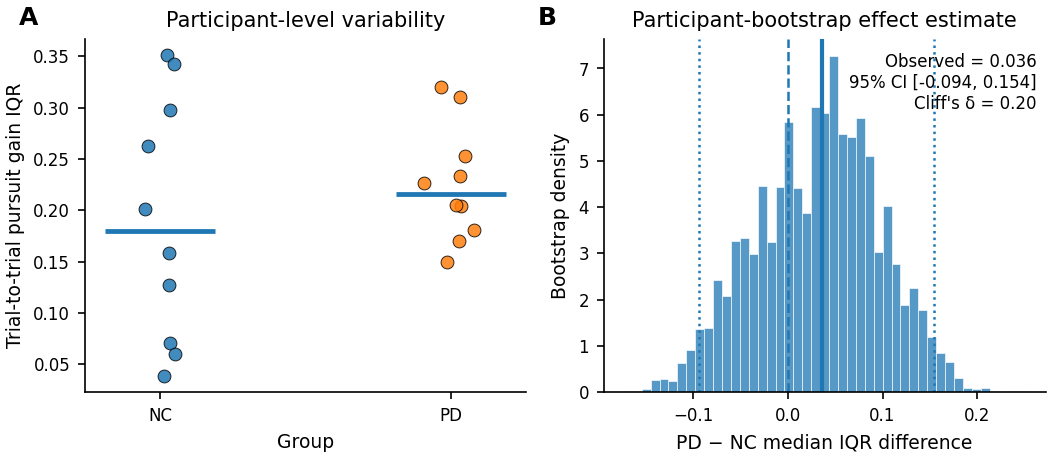

Saved:
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure2_cleaning_sensitivity.png
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure2_cleaning_sensitivity.pdf
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure2_cleaning_sensitivity.svg


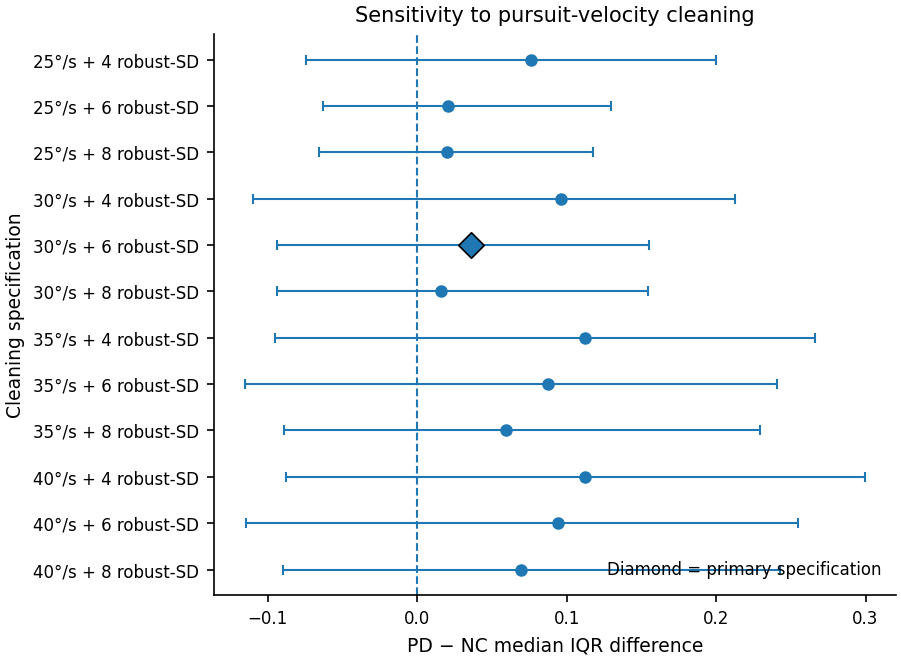



TRIAL-RESAMPLING UNCERTAINTY
Observed difference: 0.0361
95% resampling interval: [-0.0616, 0.1818]
Fraction > 0: 0.8311
Saved:
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure3_trial_sampling_uncertainty.png
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure3_trial_sampling_uncertainty.pdf
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures/Figure3_trial_sampling_uncertainty.svg


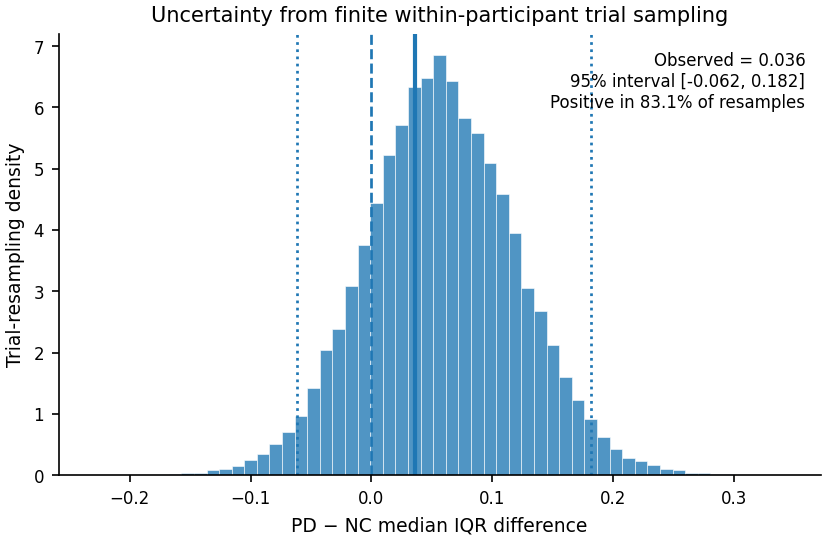



PUBLICATION FIGURES COMPLETE

All files saved in:
/content/drive/MyDrive/Wu_PD/analysis_output/publication_figures


In [14]:
# ======================================================================
# PUBLICATION FIGURES FOR EJN MANUSCRIPT
#
# Main Figure 1:
#   Participant-level trial-to-trial pursuit variability
#   + bootstrap PD-NC effect distribution
#
# Main Figure 2:
#   Cleaning/preprocessing sensitivity across 12 specifications
#
# Main Figure 3:
#   Measurement uncertainty from within-participant trial resampling
#
# Outputs:
#   PNG 600 dpi
#   PDF vector
#   SVG vector
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu


# ======================================================================
# 1. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")
OUT = BASE / "analysis_output"

FIGDIR = OUT / "publication_figures"
FIGDIR.mkdir(exist_ok=True)


TRIAL_FILE = (
    OUT
    / "Wu_binocular_pursuit_cleaning_QC.csv"
)

PARTICIPANT_FILE = (
    OUT
    / "Wu_binocular_pursuit_variability_participant.csv"
)

SENSITIVITY_FILE = (
    OUT
    / "Wu_cleaning_sensitivity_summary.csv"
)


# ======================================================================
# 2. PUBLICATION STYLE
# ======================================================================

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 9,

        "axes.labelsize": 9,
        "axes.titlesize": 10,

        "xtick.labelsize": 8,
        "ytick.labelsize": 8,

        "legend.fontsize": 8,

        "axes.linewidth": 0.8,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        "figure.dpi": 150,
        "savefig.dpi": 600,

        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    }
)


# ======================================================================
# 3. HELPER — SAVE IN MULTIPLE FORMATS
# ======================================================================

def save_publication_figure(fig, filename):

    png = FIGDIR / f"{filename}.png"
    pdf = FIGDIR / f"{filename}.pdf"
    svg = FIGDIR / f"{filename}.svg"

    fig.savefig(
        png,
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf,
        bbox_inches="tight"
    )

    fig.savefig(
        svg,
        bbox_inches="tight"
    )

    print("Saved:")
    print(png)
    print(pdf)
    print(svg)


# ======================================================================
# 4. LOAD PRIMARY DATA
# ======================================================================

trial = pd.read_csv(
    TRIAL_FILE
)

trial = trial[
    trial["Clean_mean_gain"].notna()
].copy()


# ======================================================================
# 5. CREATE PARTICIPANT IQR DATA DIRECTLY FROM TRIAL DATA
#
# This guarantees Figure 1 uses exactly the cleaned trial values.
# ======================================================================

participant = (
    trial.groupby(
        ["Participant", "Group"]
    )
    .agg(
        N_trials=("Clean_mean_gain", "count"),

        Median_gain=(
            "Clean_mean_gain",
            "median"
        ),

        IQR_gain=(
            "Clean_mean_gain",
            lambda x:
                np.percentile(x, 75)
                -
                np.percentile(x, 25)
        ),

        MAD_gain=(
            "Clean_mean_gain",
            lambda x:
                np.median(
                    np.abs(
                        x
                        -
                        np.median(x)
                    )
                )
        ),

        SD_gain=(
            "Clean_mean_gain",
            "std"
        )
    )
    .reset_index()
)


nc_iqr = participant.loc[
    participant["Group"] == "NC",
    "IQR_gain"
].to_numpy()


pd_iqr = participant.loc[
    participant["Group"] == "PD",
    "IQR_gain"
].to_numpy()


observed_diff = (
    np.median(pd_iqr)
    -
    np.median(nc_iqr)
)


# ======================================================================
# 6. PRIMARY PARTICIPANT BOOTSTRAP
# ======================================================================

rng = np.random.default_rng(
    20260913
)

B = 50000

boot_diff = np.empty(B)


for b in range(B):

    nc_b = rng.choice(
        nc_iqr,
        size=len(nc_iqr),
        replace=True
    )

    pd_b = rng.choice(
        pd_iqr,
        size=len(pd_iqr),
        replace=True
    )

    boot_diff[b] = (
        np.median(pd_b)
        -
        np.median(nc_b)
    )


ci_low, ci_high = np.percentile(
    boot_diff,
    [2.5, 97.5]
)


# ======================================================================
# 7. MANN-WHITNEY + CLIFF DELTA
# ======================================================================

mw = mannwhitneyu(
    pd_iqr,
    nc_iqr,
    alternative="two-sided"
)


cliff_delta = (
    2
    * mw.statistic
    /
    (
        len(pd_iqr)
        *
        len(nc_iqr)
    )
    -
    1
)


print("=" * 80)
print("PRIMARY RESULT")
print("=" * 80)

print(
    f"NC median IQR: "
    f"{np.median(nc_iqr):.4f}"
)

print(
    f"PD median IQR: "
    f"{np.median(pd_iqr):.4f}"
)

print(
    f"PD-NC median difference: "
    f"{observed_diff:.4f}"
)

print(
    f"Bootstrap 95% CI: "
    f"[{ci_low:.4f}, {ci_high:.4f}]"
)

print(
    f"Mann-Whitney p: "
    f"{mw.pvalue:.4f}"
)

print(
    f"Cliff delta: "
    f"{cliff_delta:.3f}"
)


# ======================================================================
# MAIN FIGURE 1
#
# A: participant-level IQR
# B: bootstrap distribution of PD-NC median difference
# ======================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.25)
)


# ----------------------------------------------------------------------
# FIGURE 1A — PARTICIPANT VALUES
# ----------------------------------------------------------------------

ax = axes[0]


groups = [
    "NC",
    "PD"
]

x_positions = [
    0,
    1
]


for x, group in zip(
    x_positions,
    groups
):

    values = participant.loc[
        participant["Group"] == group,
        "IQR_gain"
    ].to_numpy()


    # deterministic jitter
    local_rng = np.random.default_rng(
        100 + x
    )

    jitter = local_rng.normal(
        0,
        0.045,
        len(values)
    )


    ax.scatter(
        np.full(len(values), x)
        + jitter,
        values,
        s=38,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.45,
        zorder=3
    )


    median_value = np.median(
        values
    )


    ax.hlines(
        median_value,
        x - 0.19,
        x + 0.19,
        linewidth=2.3,
        zorder=4
    )


ax.set_xticks(
    [0, 1]
)

ax.set_xticklabels(
    [
        "NC",
        "PD"
    ]
)

ax.set_ylabel(
    "Trial-to-trial pursuit gain IQR"
)

ax.set_xlabel(
    "Group"
)

ax.set_title(
    "Participant-level variability"
)

ax.text(
    -0.15,
    1.04,
    "A",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold"
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


# ----------------------------------------------------------------------
# FIGURE 1B — EFFECT DISTRIBUTION
# ----------------------------------------------------------------------

ax = axes[1]


ax.hist(
    boot_diff,
    bins=45,
    density=True,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.4
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2
)


ax.axvline(
    observed_diff,
    linewidth=2
)


ax.axvline(
    ci_low,
    linestyle=":",
    linewidth=1.2
)

ax.axvline(
    ci_high,
    linestyle=":",
    linewidth=1.2
)


ax.set_xlabel(
    "PD − NC median IQR difference"
)

ax.set_ylabel(
    "Bootstrap density"
)

ax.set_title(
    "Participant-bootstrap effect estimate"
)


annotation = (
    f"Observed = {observed_diff:.3f}\n"
    f"95% CI [{ci_low:.3f}, {ci_high:.3f}]\n"
    f"Cliff's δ = {cliff_delta:.2f}"
)


ax.text(
    0.98,
    0.96,
    annotation,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8
)


ax.text(
    -0.15,
    1.04,
    "B",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold"
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


fig.tight_layout()


save_publication_figure(
    fig,
    "Figure1_primary_pursuit_variability"
)

plt.show()


# ======================================================================
# MAIN FIGURE 2
#
# CLEANING SENSITIVITY
#
# Uses the results already obtained from the 12 preprocessing
# specifications.
# ======================================================================


# Use the exact sensitivity values generated in the completed analysis.
#
# abs_limit:
#   absolute speed threshold in deg/s
#
# robust_k:
#   robust-SD multiplier based on MAD

sensitivity = pd.DataFrame(
    {
        "Abs_limit":
        [
            25, 25, 25,
            30, 30, 30,
            35, 35, 35,
            40, 40, 40
        ],

        "Robust_k":
        [
            4, 6, 8,
            4, 6, 8,
            4, 6, 8,
            4, 6, 8
        ],

        "Difference":
        [
            0.076078,
            0.020946,
            0.019771,

            0.096583,
            0.036114,
            0.016187,

            0.112622,
            0.087888,
            0.059550,

            0.112622,
            0.094212,
            0.069208
        ],

        "CI_low":
        [
            -0.074068,
            -0.063168,
            -0.065661,

            -0.109754,
            -0.094013,
            -0.093998,

            -0.094837,
            -0.115137,
            -0.089192,

            -0.088015,
            -0.114524,
            -0.089902
        ],

        "CI_high":
        [
            0.200265,
            0.129453,
            0.117928,

            0.212463,
            0.155052,
            0.154247,

            0.266220,
            0.240461,
            0.229162,

            0.299340,
            0.254521,
            0.242471
        ],

        "MW_p":
        [
            0.140465,
            0.307489,
            0.384673,

            0.161972,
            0.472676,
            0.791337,

            0.104110,
            0.273036,
            0.344704,

            0.064022,
            0.241322,
            0.307489
        ]
    }
)


sensitivity[
    "Specification"
] = (
    sensitivity[
        "Abs_limit"
    ].astype(str)
    +
    "°/s + "
    +
    sensitivity[
        "Robust_k"
    ].astype(str)
    +
    " robust-SD"
)


# Reverse so first item appears at top
plot_sens = (
    sensitivity
    .iloc[::-1]
    .reset_index(drop=True)
)


fig, ax = plt.subplots(
    figsize=(6.2, 4.6)
)


y = np.arange(
    len(plot_sens)
)


xerr = np.vstack(
    [
        plot_sens["Difference"]
        -
        plot_sens["CI_low"],

        plot_sens["CI_high"]
        -
        plot_sens["Difference"]
    ]
)


ax.errorbar(
    plot_sens[
        "Difference"
    ],
    y,
    xerr=xerr,
    fmt="o",
    markersize=5,
    capsize=2.5,
    linewidth=1
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


# Highlight primary specification
primary_mask = (
    (
        plot_sens[
            "Abs_limit"
        ] == 30
    )
    &
    (
        plot_sens[
            "Robust_k"
        ] == 6
    )
)


primary_y = np.where(
    primary_mask
)[0][0]


ax.scatter(
    plot_sens.loc[
        primary_y,
        "Difference"
    ],
    primary_y,
    s=75,
    marker="D",
    zorder=5,
    edgecolor="black",
    linewidth=0.8
)


ax.set_yticks(
    y
)

ax.set_yticklabels(
    plot_sens[
        "Specification"
    ]
)


ax.set_xlabel(
    "PD − NC median IQR difference"
)

ax.set_ylabel(
    "Cleaning specification"
)

ax.set_title(
    "Sensitivity to pursuit-velocity cleaning"
)


ax.text(
    0.98,
    0.03,
    "Diamond = primary specification",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


fig.tight_layout()


save_publication_figure(
    fig,
    "Figure2_cleaning_sensitivity"
)

plt.show()


# ======================================================================
# MAIN FIGURE 3
#
# WITHIN-PARTICIPANT TRIAL-RESAMPLING UNCERTAINTY
#
# Each bootstrap iteration:
#
#   1. resample trials WITHIN each participant
#   2. recompute participant IQR
#   3. calculate group median IQR
#   4. calculate PD-NC median difference
#
# This quantifies uncertainty from having only ~10 trials/person.
# ======================================================================


def calculate_iqr(values):

    return (
        np.percentile(
            values,
            75
        )
        -
        np.percentile(
            values,
            25
        )
    )


participants = (
    trial[
        [
            "Participant",
            "Group"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


B_TRIAL = 30000

trial_boot_diff = np.empty(
    B_TRIAL
)


rng_trial = np.random.default_rng(
    456789
)


# Pre-store participant trial arrays for speed
participant_trials = {}


for _, row in participants.iterrows():

    pid = row[
        "Participant"
    ]

    participant_trials[
        pid
    ] = trial.loc[
        trial[
            "Participant"
        ] == pid,
        "Clean_mean_gain"
    ].to_numpy()


for b in range(
    B_TRIAL
):

    nc_values = []
    pd_values = []


    for _, row in participants.iterrows():

        pid = row[
            "Participant"
        ]

        group = row[
            "Group"
        ]


        values = participant_trials[
            pid
        ]


        resampled = rng_trial.choice(
            values,
            size=len(values),
            replace=True
        )


        boot_iqr = calculate_iqr(
            resampled
        )


        if group == "NC":

            nc_values.append(
                boot_iqr
            )

        else:

            pd_values.append(
                boot_iqr
            )


    trial_boot_diff[
        b
    ] = (
        np.median(
            pd_values
        )
        -
        np.median(
            nc_values
        )
    )


trial_ci_low, trial_ci_high = np.percentile(
    trial_boot_diff,
    [
        2.5,
        97.5
    ]
)


positive_fraction = np.mean(
    trial_boot_diff > 0
)


print("\n")
print("=" * 80)
print("TRIAL-RESAMPLING UNCERTAINTY")
print("=" * 80)

print(
    f"Observed difference: "
    f"{observed_diff:.4f}"
)

print(
    f"95% resampling interval: "
    f"[{trial_ci_low:.4f}, "
    f"{trial_ci_high:.4f}]"
)

print(
    f"Fraction > 0: "
    f"{positive_fraction:.4f}"
)


fig, ax = plt.subplots(
    figsize=(5.7, 3.8)
)


ax.hist(
    trial_boot_diff,
    bins=55,
    density=True,
    alpha=0.78,
    edgecolor="white",
    linewidth=0.35
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1.3,
    label="No group difference"
)


ax.axvline(
    observed_diff,
    linewidth=2,
    label="Observed difference"
)


ax.axvline(
    trial_ci_low,
    linestyle=":",
    linewidth=1.3
)

ax.axvline(
    trial_ci_high,
    linestyle=":",
    linewidth=1.3
)


ax.set_xlabel(
    "PD − NC median IQR difference"
)

ax.set_ylabel(
    "Trial-resampling density"
)

ax.set_title(
    "Uncertainty from finite within-participant trial sampling"
)


text = (
    f"Observed = {observed_diff:.3f}\n"
    f"95% interval "
    f"[{trial_ci_low:.3f}, "
    f"{trial_ci_high:.3f}]\n"
    f"Positive in "
    f"{positive_fraction * 100:.1f}% "
    f"of resamples"
)


ax.text(
    0.98,
    0.96,
    text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


fig.tight_layout()


save_publication_figure(
    fig,
    "Figure3_trial_sampling_uncertainty"
)

plt.show()


# ======================================================================
# SAVE EXACT FIGURE DATA
# ======================================================================

participant.to_csv(
    FIGDIR
    / "Figure1_data.csv",
    index=False
)


sensitivity.to_csv(
    FIGDIR
    / "Figure2_data.csv",
    index=False
)


pd.DataFrame(
    {
        "Trial_resampling_PD_minus_NC":
            trial_boot_diff
    }
).to_csv(
    FIGDIR
    / "Figure3_resampling_data.csv",
    index=False
)


print("\n")
print("=" * 80)
print("PUBLICATION FIGURES COMPLETE")
print("=" * 80)

print(
    f"\nAll files saved in:\n{FIGDIR}"
)

PRIMARY ESTIMATES
NC median IQR = 0.1797 [0.0707, 0.3025]
PD median IQR = 0.2158 [0.1809, 0.2722]
PD-NC difference = 0.0361 [-0.0939, 0.1541]
Saved Figure_1_primary_estimation


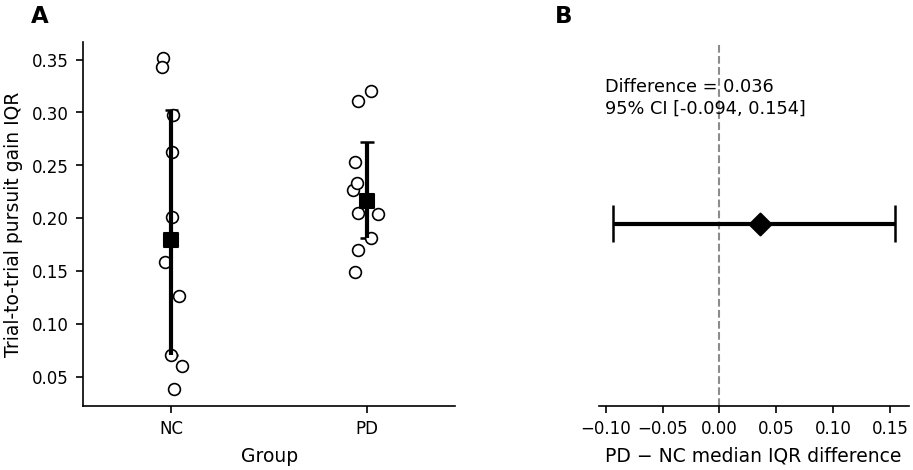

Saved Figure_2_preprocessing_robustness


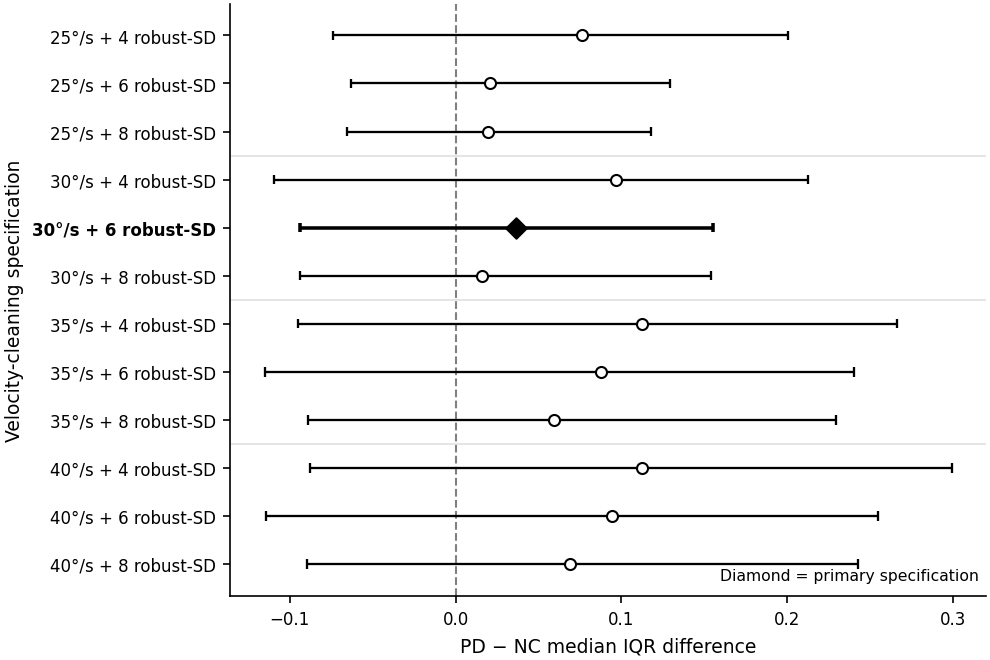

Saved Figure_3_measurement_precision


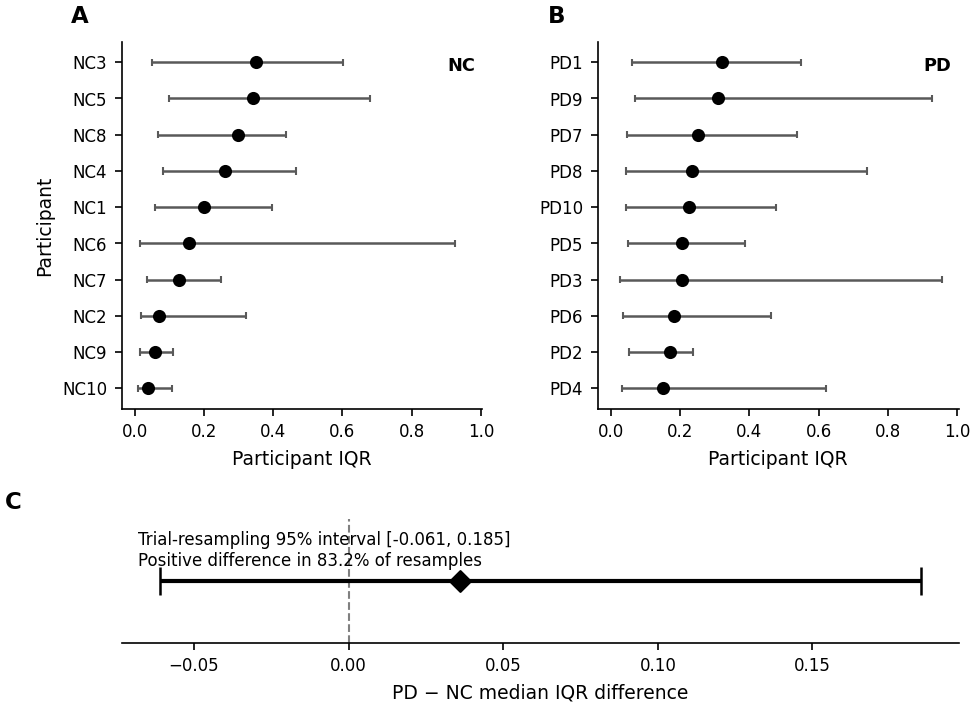



JOURNAL FIGURES COMPLETE
Saved to:
/content/drive/MyDrive/Wu_PD/analysis_output/journal_figures


In [15]:
# ======================================================================
# JOURNAL-GRADE FIGURES
# Trial-to-trial smooth pursuit variability in Parkinson's disease
#
# Designed for neuroscience journal submission:
#   - raw observations
#   - estimation-focused
#   - confidence intervals
#   - restrained styling
#   - vector output
#   - no significance stars
#
# Outputs:
#   Figure_1_primary_estimation
#   Figure_2_preprocessing_robustness
#   Figure_3_measurement_precision
#
# PNG 600 dpi + PDF + SVG
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


# ======================================================================
# 1. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")
OUT = BASE / "analysis_output"

FIGDIR = OUT / "journal_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

TRIAL_FILE = OUT / "Wu_binocular_pursuit_cleaning_QC.csv"


# ======================================================================
# 2. PUBLICATION STYLE
# ======================================================================

plt.rcParams.update({

    # Typography
    "font.family": "sans-serif",
    "font.size": 8.5,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Clean journal appearance
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    # Vector-compatible fonts
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03
})


# ======================================================================
# 3. HELPERS
# ======================================================================

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def panel_label(ax, letter):
    ax.text(
        -0.14,
        1.04,
        letter,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom",
        ha="left"
    )


def save_fig(fig, name):

    fig.savefig(
        FIGDIR / f"{name}.png",
        dpi=600
    )

    fig.savefig(
        FIGDIR / f"{name}.pdf"
    )

    fig.savefig(
        FIGDIR / f"{name}.svg"
    )

    print(f"Saved {name}")


# ======================================================================
# 4. LOAD CLEANED TRIAL DATA
# ======================================================================

df = pd.read_csv(TRIAL_FILE)

df = df[
    df["Clean_mean_gain"].notna()
].copy()


# ======================================================================
# 5. PARTICIPANT SUMMARY
# ======================================================================

participant = (
    df.groupby(
        ["Participant", "Group"]
    )
    .agg(
        N_trials=("Clean_mean_gain", "count"),

        Median_gain=(
            "Clean_mean_gain",
            "median"
        ),

        IQR_gain=(
            "Clean_mean_gain",
            lambda x:
                np.percentile(x, 75)
                -
                np.percentile(x, 25)
        ),

        MAD_gain=(
            "Clean_mean_gain",
            lambda x:
                np.median(
                    np.abs(
                        x - np.median(x)
                    )
                )
        ),

        SD_gain=(
            "Clean_mean_gain",
            "std"
        )
    )
    .reset_index()
)


nc = participant.loc[
    participant["Group"] == "NC",
    "IQR_gain"
].to_numpy()

pdv = participant.loc[
    participant["Group"] == "PD",
    "IQR_gain"
].to_numpy()


# ======================================================================
# 6. BOOTSTRAP FUNCTIONS
# ======================================================================

rng = np.random.default_rng(20260913)


def bootstrap_median_ci(values, B=50000):

    values = np.asarray(values)

    boots = np.empty(B)

    for b in range(B):

        sample = rng.choice(
            values,
            len(values),
            replace=True
        )

        boots[b] = np.median(sample)

    return (
        np.median(values),
        *np.percentile(
            boots,
            [2.5, 97.5]
        )
    )


def bootstrap_median_difference(a, b, B=50000):
    """
    Returns median(a) - median(b)
    """

    boots = np.empty(B)

    for i in range(B):

        aa = rng.choice(
            a,
            len(a),
            replace=True
        )

        bb = rng.choice(
            b,
            len(b),
            replace=True
        )

        boots[i] = (
            np.median(aa)
            -
            np.median(bb)
        )

    observed = (
        np.median(a)
        -
        np.median(b)
    )

    low, high = np.percentile(
        boots,
        [2.5, 97.5]
    )

    return observed, low, high, boots


nc_med, nc_lo, nc_hi = bootstrap_median_ci(nc)

pd_med, pd_lo, pd_hi = bootstrap_median_ci(pdv)

effect, effect_lo, effect_hi, participant_boot = (
    bootstrap_median_difference(
        pdv,
        nc
    )
)


print("=" * 70)
print("PRIMARY ESTIMATES")
print("=" * 70)

print(
    f"NC median IQR = {nc_med:.4f} "
    f"[{nc_lo:.4f}, {nc_hi:.4f}]"
)

print(
    f"PD median IQR = {pd_med:.4f} "
    f"[{pd_lo:.4f}, {pd_hi:.4f}]"
)

print(
    f"PD-NC difference = {effect:.4f} "
    f"[{effect_lo:.4f}, {effect_hi:.4f}]"
)


# ======================================================================
# FIGURE 1
# PRIMARY ESTIMATION FIGURE
# ======================================================================

fig = plt.figure(
    figsize=(7.1, 3.15)
)

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.2, 1],
    wspace=0.42
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])


# ----------------------------------------------------------------------
# 1A — RAW PARTICIPANT DATA + GROUP MEDIAN CIs
# ----------------------------------------------------------------------

group_info = [
    ("NC", nc, nc_med, nc_lo, nc_hi, 0),
    ("PD", pdv, pd_med, pd_lo, pd_hi, 1)
]


for group, values, med, lo, hi, xpos in group_info:

    local_rng = np.random.default_rng(
        1000 + xpos
    )

    jitter = local_rng.uniform(
        -0.075,
        0.075,
        len(values)
    )

    # Raw participants
    ax1.scatter(
        xpos + jitter,
        values,
        s=32,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    # Bootstrap CI for group median
    ax1.vlines(
        xpos,
        lo,
        hi,
        linewidth=2,
        color="black",
        zorder=4
    )

    ax1.hlines(
        [lo, hi],
        xpos - 0.035,
        xpos + 0.035,
        linewidth=1.2,
        color="black"
    )

    # Median
    ax1.scatter(
        xpos,
        med,
        marker="s",
        s=42,
        facecolor="black",
        edgecolor="black",
        zorder=5
    )


ax1.set_xticks(
    [0, 1]
)

ax1.set_xticklabels(
    ["NC", "PD"]
)

ax1.set_xlim(
    -0.45,
    1.45
)

ax1.set_ylabel(
    "Trial-to-trial pursuit gain IQR"
)

ax1.set_xlabel(
    "Group"
)

despine(ax1)
panel_label(ax1, "A")


# ----------------------------------------------------------------------
# 1B — EFFECT SIZE ESTIMATE
# ----------------------------------------------------------------------

ax2.axvline(
    0,
    color="0.55",
    linestyle="--",
    linewidth=1
)


# CI
ax2.hlines(
    0,
    effect_lo,
    effect_hi,
    linewidth=2,
    color="black"
)

ax2.vlines(
    [effect_lo, effect_hi],
    -0.04,
    0.04,
    linewidth=1.2,
    color="black"
)


# Point estimate
ax2.scatter(
    effect,
    0,
    s=55,
    marker="D",
    facecolor="black",
    edgecolor="black",
    zorder=4
)


ax2.set_ylim(
    -0.4,
    0.4
)

ax2.set_yticks([])

ax2.set_xlabel(
    "PD − NC median IQR difference"
)


ax2.text(
    0.02,
    0.90,
    f"Difference = {effect:.3f}\n"
    f"95% CI [{effect_lo:.3f}, {effect_hi:.3f}]",
    transform=ax2.transAxes,
    va="top",
    ha="left"
)

despine(ax2)
ax2.spines["left"].set_visible(False)

panel_label(ax2, "B")


fig.align_ylabels()

save_fig(
    fig,
    "Figure_1_primary_estimation"
)

plt.show()


# ======================================================================
# FIGURE 2
# PREPROCESSING ROBUSTNESS FOREST PLOT
# ======================================================================

sensitivity = pd.DataFrame({

    "Abs_limit": [
        25,25,25,
        30,30,30,
        35,35,35,
        40,40,40
    ],

    "Robust_k": [
        4,6,8,
        4,6,8,
        4,6,8,
        4,6,8
    ],

    "Estimate": [
        0.076078,
        0.020946,
        0.019771,

        0.096583,
        0.036114,
        0.016187,

        0.112622,
        0.087888,
        0.059550,

        0.112622,
        0.094212,
        0.069208
    ],

    "Low": [
        -0.074068,
        -0.063168,
        -0.065661,

        -0.109754,
        -0.094013,
        -0.093998,

        -0.094837,
        -0.115137,
        -0.089192,

        -0.088015,
        -0.114524,
        -0.089902
    ],

    "High": [
        0.200265,
        0.129453,
        0.117928,

        0.212463,
        0.155052,
        0.154247,

        0.266220,
        0.240461,
        0.229162,

        0.299340,
        0.254521,
        0.242471
    ]
})


sensitivity["Label"] = (
    sensitivity["Abs_limit"].astype(str)
    +
    "°/s + "
    +
    sensitivity["Robust_k"].astype(str)
    +
    " robust-SD"
)


sens = sensitivity.copy()

sens["y"] = np.arange(
    len(sens)
)[::-1]


fig, ax = plt.subplots(
    figsize=(6.8, 4.6)
)


ax.axvline(
    0,
    color="0.5",
    linestyle="--",
    linewidth=1
)


for _, row in sens.iterrows():

    is_primary = (
        row["Abs_limit"] == 30
        and
        row["Robust_k"] == 6
    )

    marker = "D" if is_primary else "o"

    size = 48 if is_primary else 28

    lw = 1.7 if is_primary else 1.1


    # CI
    ax.hlines(
        row["y"],
        row["Low"],
        row["High"],
        color="black",
        linewidth=lw
    )

    # CI caps
    ax.vlines(
        [
            row["Low"],
            row["High"]
        ],
        row["y"] - 0.10,
        row["y"] + 0.10,
        color="black",
        linewidth=lw
    )

    # Point estimate
    ax.scatter(
        row["Estimate"],
        row["y"],
        marker=marker,
        s=size,
        facecolor=(
            "black"
            if is_primary
            else
            "white"
        ),
        edgecolor="black",
        linewidth=1,
        zorder=4
    )


ax.set_yticks(
    sens["y"]
)

ax.set_yticklabels(
    sens["Label"]
)


# Bold the primary specification
for tick, (_, row) in zip(
    ax.get_yticklabels(),
    sens.iterrows()
):

    if (
        row["Abs_limit"] == 30
        and
        row["Robust_k"] == 6
    ):
        tick.set_fontweight("bold")


ax.set_xlabel(
    "PD − NC median IQR difference"
)

ax.set_ylabel(
    "Velocity-cleaning specification"
)


# Subtle group separators between absolute thresholds
for sep in [
    8.5,
    5.5,
    2.5
]:

    ax.axhline(
        sep,
        color="0.88",
        linewidth=0.8
    )


ax.text(
    0.99,
    0.02,
    "Diamond = primary specification",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=7.5
)


despine(ax)

fig.tight_layout()

save_fig(
    fig,
    "Figure_2_preprocessing_robustness"
)

plt.show()


# ======================================================================
# FIGURE 3
# WITHIN-PARTICIPANT MEASUREMENT PRECISION
# ======================================================================

B_WITHIN = 15000

rng_within = np.random.default_rng(
    7654321
)


participant_uncertainty = []


for participant_id, sub in df.groupby(
    "Participant"
):

    values = sub[
        "Clean_mean_gain"
    ].to_numpy()

    group = sub[
        "Group"
    ].iloc[0]


    observed = (
        np.percentile(values, 75)
        -
        np.percentile(values, 25)
    )


    boot_iqrs = np.empty(
        B_WITHIN
    )


    for b in range(
        B_WITHIN
    ):

        sample = rng_within.choice(
            values,
            len(values),
            replace=True
        )

        boot_iqrs[b] = (
            np.percentile(sample, 75)
            -
            np.percentile(sample, 25)
        )


    low, high = np.percentile(
        boot_iqrs,
        [2.5, 97.5]
    )


    participant_uncertainty.append({

        "Participant":
            participant_id,

        "Group":
            group,

        "Observed_IQR":
            observed,

        "CI_low":
            low,

        "CI_high":
            high
    })


unc = pd.DataFrame(
    participant_uncertainty
)


# ======================================================================
# TRIAL-RESAMPLING GROUP EFFECT
# ======================================================================

participant_ids = (
    df[
        [
            "Participant",
            "Group"
        ]
    ]
    .drop_duplicates()
)


trial_arrays = {

    pid:
        df.loc[
            df["Participant"] == pid,
            "Clean_mean_gain"
        ].to_numpy()

    for pid
    in participant_ids[
        "Participant"
    ]
}


B_GROUP = 30000

group_boot = np.empty(
    B_GROUP
)


rng_group = np.random.default_rng(
    246810
)


for b in range(B_GROUP):

    nc_boot = []
    pd_boot = []


    for _, row in participant_ids.iterrows():

        pid = row[
            "Participant"
        ]

        group = row[
            "Group"
        ]

        values = trial_arrays[
            pid
        ]


        sample = rng_group.choice(
            values,
            len(values),
            replace=True
        )


        iqr = (
            np.percentile(
                sample,
                75
            )
            -
            np.percentile(
                sample,
                25
            )
        )


        if group == "NC":

            nc_boot.append(
                iqr
            )

        else:

            pd_boot.append(
                iqr
            )


    group_boot[b] = (
        np.median(
            pd_boot
        )
        -
        np.median(
            nc_boot
        )
    )


trial_low, trial_high = np.percentile(
    group_boot,
    [2.5, 97.5]
)

positive_fraction = np.mean(
    group_boot > 0
)


# ======================================================================
# FIGURE 3 LAYOUT
# ======================================================================

fig = plt.figure(
    figsize=(7.2, 5.2)
)

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[
        4,
        1.35
    ],
    hspace=0.45,
    wspace=0.32
)


ax_nc = fig.add_subplot(
    gs[0, 0]
)

ax_pd = fig.add_subplot(
    gs[0, 1],
    sharex=ax_nc
)

ax_effect = fig.add_subplot(
    gs[1, :]
)


# ======================================================================
# 3A / 3B — INDIVIDUAL PARTICIPANT PRECISION
# ======================================================================

for ax, group, letter in [

    (ax_nc, "NC", "A"),

    (ax_pd, "PD", "B")

]:

    sub = (
        unc[
            unc["Group"] == group
        ]
        .sort_values(
            "Observed_IQR"
        )
        .reset_index(drop=True)
    )


    y = np.arange(
        len(sub)
    )


    # CIs
    for i, row in sub.iterrows():

        ax.hlines(
            i,
            row["CI_low"],
            row["CI_high"],
            color="0.35",
            linewidth=1.2
        )

        ax.vlines(
            [
                row["CI_low"],
                row["CI_high"]
            ],
            i - 0.10,
            i + 0.10,
            color="0.35",
            linewidth=1
        )


    # Observed estimates
    ax.scatter(
        sub["Observed_IQR"],
        y,
        s=28,
        facecolor="black",
        edgecolor="black",
        zorder=3
    )


    ax.set_yticks(
        y
    )

    ax.set_yticklabels(
        sub["Participant"]
    )


    ax.set_xlabel(
        "Participant IQR"
    )


    ax.text(
        0.98,
        0.96,
        group,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold"
    )


    despine(ax)

    panel_label(
        ax,
        letter
    )


ax_nc.set_ylabel(
    "Participant"
)


# ======================================================================
# 3C — GROUP EFFECT FROM WITHIN-PARTICIPANT RESAMPLING
# ======================================================================

ax_effect.axvline(
    0,
    color="0.5",
    linestyle="--",
    linewidth=1
)


ax_effect.hlines(
    0,
    trial_low,
    trial_high,
    color="black",
    linewidth=2
)


ax_effect.vlines(
    [
        trial_low,
        trial_high
    ],
    -0.08,
    0.08,
    color="black",
    linewidth=1.2
)


ax_effect.scatter(
    effect,
    0,
    marker="D",
    s=50,
    facecolor="black",
    edgecolor="black",
    zorder=4
)


ax_effect.set_ylim(
    -0.35,
    0.35
)

ax_effect.set_yticks([])


ax_effect.set_xlabel(
    "PD − NC median IQR difference"
)


ax_effect.text(
    0.02,
    0.90,
    f"Trial-resampling 95% interval "
    f"[{trial_low:.3f}, {trial_high:.3f}]\n"
    f"Positive difference in "
    f"{positive_fraction * 100:.1f}% of resamples",
    transform=ax_effect.transAxes,
    va="top",
    ha="left",
    fontsize=8
)


despine(
    ax_effect
)

ax_effect.spines[
    "left"
].set_visible(False)

panel_label(
    ax_effect,
    "C"
)


save_fig(
    fig,
    "Figure_3_measurement_precision"
)

plt.show()


# ======================================================================
# SAVE FIGURE DATA
# ======================================================================

participant.to_csv(
    FIGDIR
    / "Figure1_participant_data.csv",
    index=False
)

sensitivity.to_csv(
    FIGDIR
    / "Figure2_sensitivity_data.csv",
    index=False
)

unc.to_csv(
    FIGDIR
    / "Figure3_participant_uncertainty.csv",
    index=False
)

pd.DataFrame({
    "PD_minus_NC_trial_resampling":
        group_boot
}).to_csv(
    FIGDIR
    / "Figure3_group_resampling.csv",
    index=False
)


print("\n")
print("=" * 80)
print("JOURNAL FIGURES COMPLETE")
print("=" * 80)

print(
    f"Saved to:\n{FIGDIR}"
)

Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Figure2_velocity_cleaning_sensitivity.png
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Figure2_velocity_cleaning_sensitivity.pdf
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Figure2_velocity_cleaning_sensitivity.svg


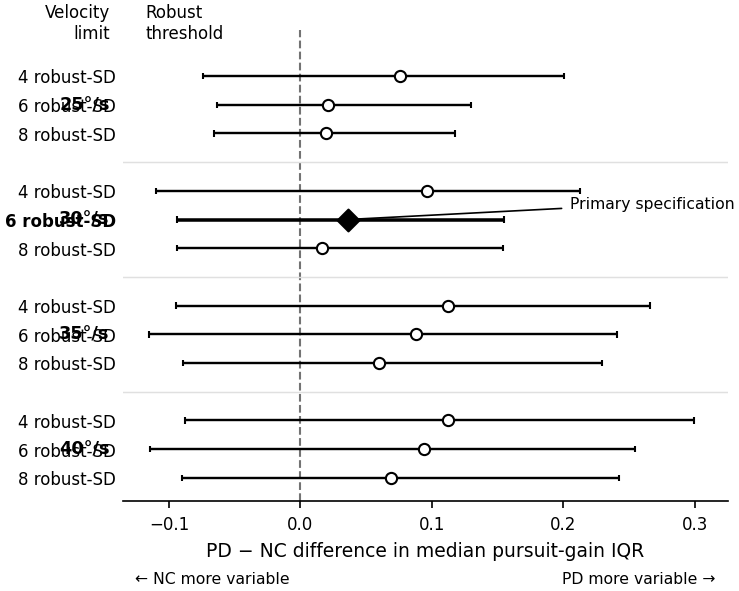

In [16]:
# ======================================================================
# PUBLICATION-STYLE VELOCITY-CLEANING SENSITIVITY FOREST PLOT
# ======================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ======================================================================
# 1. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")
OUT = BASE / "analysis_output"

FIGDIR = OUT / "journal_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)


# ======================================================================
# 2. DATA
# ======================================================================

sens = pd.DataFrame({

    "Abs_limit": [
        25, 25, 25,
        30, 30, 30,
        35, 35, 35,
        40, 40, 40
    ],

    "Robust_k": [
        4, 6, 8,
        4, 6, 8,
        4, 6, 8,
        4, 6, 8
    ],

    "Estimate": [
        0.076078,
        0.020946,
        0.019771,

        0.096583,
        0.036114,
        0.016187,

        0.112622,
        0.087888,
        0.059550,

        0.112622,
        0.094212,
        0.069208
    ],

    "CI_low": [
        -0.074068,
        -0.063168,
        -0.065661,

        -0.109754,
        -0.094013,
        -0.093998,

        -0.094837,
        -0.115137,
        -0.089192,

        -0.088015,
        -0.114524,
        -0.089902
    ],

    "CI_high": [
        0.200265,
        0.129453,
        0.117928,

        0.212463,
        0.155052,
        0.154247,

        0.266220,
        0.240461,
        0.229162,

        0.299340,
        0.254521,
        0.242471
    ]
})


# ======================================================================
# 3. LABELS / ORDER
# ======================================================================

sens["Label"] = (
    sens["Robust_k"].astype(str)
    + " robust-SD"
)

# Custom y positions create visible space between threshold blocks
y_positions = [
    14, 13, 12,
    10, 9, 8,
    6, 5, 4,
    2, 1, 0
]

sens["y"] = y_positions


# ======================================================================
# 4. PUBLICATION STYLE
# ======================================================================

plt.rcParams.update({

    "font.family": "sans-serif",
    "font.size": 8.5,

    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    "axes.linewidth": 0.8,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.major.size": 3.5,
    "ytick.major.size": 0,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "savefig.dpi": 600
})


# ======================================================================
# 5. FIGURE
# ======================================================================

fig, ax = plt.subplots(
    figsize=(6.3, 4.3)
)


# ----------------------------------------------------------------------
# ZERO / NULL EFFECT
# ----------------------------------------------------------------------

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color="0.45",
    zorder=0
)


# ----------------------------------------------------------------------
# FOREST PLOT
# ----------------------------------------------------------------------

for _, row in sens.iterrows():

    primary = (
        row["Abs_limit"] == 30
        and
        row["Robust_k"] == 6
    )

    # Confidence interval
    ax.hlines(
        y=row["y"],
        xmin=row["CI_low"],
        xmax=row["CI_high"],
        color="black",
        linewidth=(
            1.7 if primary else 1.15
        ),
        zorder=2
    )

    # CI caps
    cap = 0.11

    ax.vlines(
        row["CI_low"],
        row["y"] - cap,
        row["y"] + cap,
        color="black",
        linewidth=1
    )

    ax.vlines(
        row["CI_high"],
        row["y"] - cap,
        row["y"] + cap,
        color="black",
        linewidth=1
    )

    # Point estimate
    ax.scatter(
        row["Estimate"],
        row["y"],

        marker=(
            "D" if primary else "o"
        ),

        s=(
            55 if primary else 29
        ),

        facecolor=(
            "black"
            if primary
            else
            "white"
        ),

        edgecolor="black",
        linewidth=1,
        zorder=3
    )


# ======================================================================
# 6. Y LABELS
# ======================================================================

ax.set_yticks(
    sens["y"]
)

ax.set_yticklabels(
    sens["Label"]
)


# Bold primary row
for tick, (_, row) in zip(
    ax.get_yticklabels(),
    sens.iterrows()
):

    if (
        row["Abs_limit"] == 30
        and
        row["Robust_k"] == 6
    ):
        tick.set_fontweight(
            "bold"
        )


# ======================================================================
# 7. ABSOLUTE VELOCITY THRESHOLD GROUP LABELS
# ======================================================================

group_centers = {
    25: 13,
    30: 9,
    35: 5,
    40: 1
}


for threshold, y in group_centers.items():

    ax.text(
        -0.145,
        y,
        f"{threshold}°/s",
        ha="right",
        va="center",
        fontsize=8.5,
        fontweight="bold",
        clip_on=False
    )


# Header for left grouping column
ax.text(
    -0.145,
    15.15,
    "Velocity\nlimit",
    ha="right",
    va="bottom",
    fontsize=8,
    clip_on=False
)


# Header for threshold column
ax.text(
    -0.118,
    15.15,
    "Robust\nthreshold",
    ha="left",
    va="bottom",
    fontsize=8,
    clip_on=False
)


# ======================================================================
# 8. GROUP SEPARATORS
# ======================================================================

for y in [
    11,
    7,
    3
]:

    ax.axhline(
        y,
        color="0.88",
        linewidth=0.7,
        zorder=0
    )


# ======================================================================
# 9. PRIMARY SPECIFICATION LABEL
# ======================================================================

primary = sens[
    (sens["Abs_limit"] == 30)
    &
    (sens["Robust_k"] == 6)
].iloc[0]


ax.annotate(
    "Primary specification",

    xy=(
        primary["Estimate"],
        primary["y"]
    ),

    xytext=(
        0.205,
        primary["y"] + 0.55
    ),

    fontsize=7.5,

    ha="left",
    va="center",

    arrowprops=dict(
        arrowstyle="-",
        linewidth=0.8,
        color="black"
    )
)


# ======================================================================
# 10. AXES
# ======================================================================

ax.set_xlabel(
    "PD − NC difference in median pursuit-gain IQR"
)

ax.set_ylabel("")


ax.set_xlim(
    -0.135,
    0.325
)

ax.set_ylim(
    -0.8,
    15.6
)


# Clean ticks
ax.set_xticks(
    [
        -0.10,
        0.00,
        0.10,
        0.20,
        0.30
    ]
)


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


# ======================================================================
# 11. DIRECTION LABELS
# ======================================================================

ax.text(
    0.02,
    -0.15,
    "← NC more variable",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=7.5
)

ax.text(
    0.98,
    -0.15,
    "PD more variable →",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=7.5
)


# ======================================================================
# 12. LAYOUT
# ======================================================================

fig.subplots_adjust(
    left=0.34,
    right=0.98,
    bottom=0.20,
    top=0.93
)


# ======================================================================
# 13. SAVE
# ======================================================================

for ext in [
    "png",
    "pdf",
    "svg"
]:

    path = (
        FIGDIR
        / f"Figure2_velocity_cleaning_sensitivity.{ext}"
    )

    if ext == "png":

        fig.savefig(
            path,
            dpi=600,
            bbox_inches="tight"
        )

    else:

        fig.savefig(
            path,
            bbox_inches="tight"
        )

    print(
        "Saved:",
        path
    )


plt.show()

Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Supplementary_Figure_S1_trial_order_dynamics.png
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Supplementary_Figure_S1_trial_order_dynamics.pdf
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Supplementary_Figure_S1_trial_order_dynamics.svg


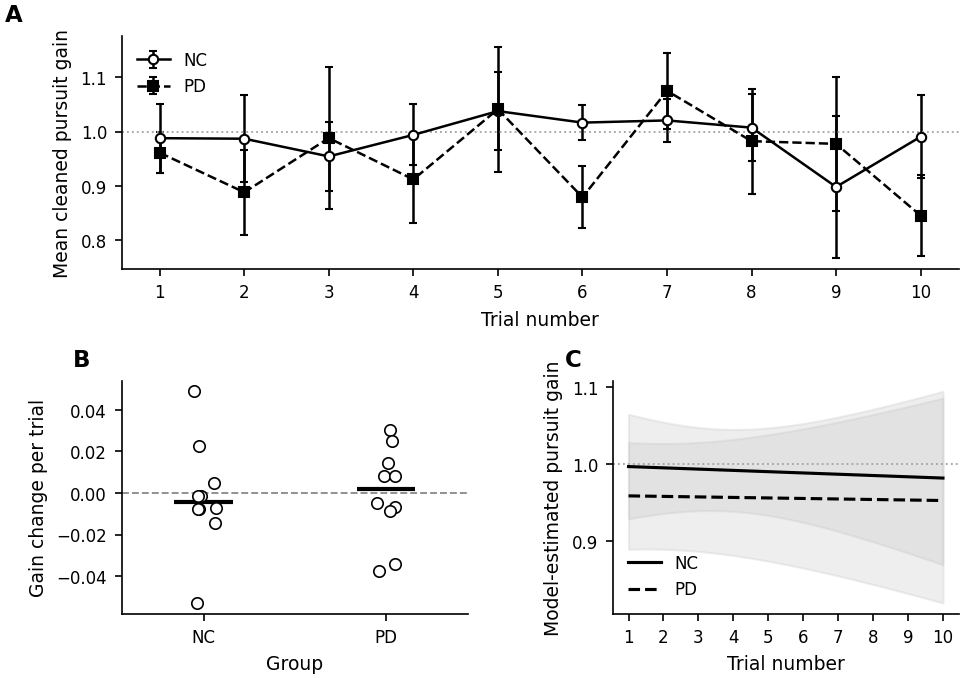



FIGURE S1 MODEL VALUES
NC slope: -0.001660120794642303
PD slope: -0.0006698795424664662
Interaction beta: 0.0009902412521758368
Interaction p: 0.926141154530718

Validation columns:
['Participant', 'Group', 'N_trials', 'Mean_gain', 'Median_gain', 'SD_gain', 'Q25', 'Q75', 'MAD_gain', 'IQR_gain', 'Our_mean_velocity', 'Our_median_velocity', 'Wu_velocity']

Using Wu column: Wu_velocity
Using reconstructed column: Our_mean_velocity


FIGURE S2 VALIDATION VALUES
N = 20
Pearson r = 0.8477, p = 2.37869e-06
Spearman rho = 0.7759, p = 5.79653e-05
MAE = 0.5934 deg/s
RMSE = 0.7523 deg/s
Bias = 0.3829 deg/s
95% limits of agreement = [-0.9193, 1.6850] deg/s
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Supplementary_Figure_S2_pipeline_validation.png
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Supplementary_Figure_S2_pipeline_validation.pdf
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/Supplementary_Figure_S2_pipeline_validation.sv

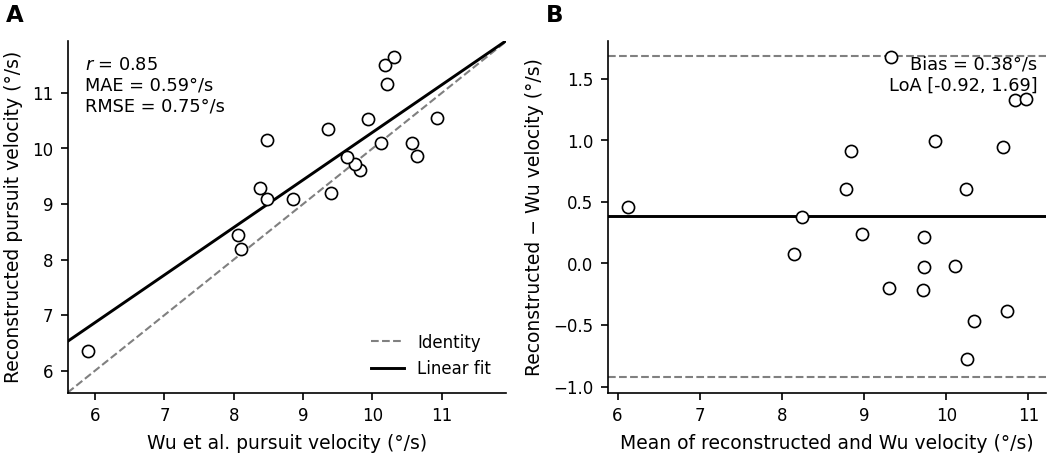



SUPPLEMENTARY FIGURES COMPLETE
Saved in:
/content/drive/MyDrive/Wu_PD/analysis_output/journal_figures


In [17]:
# ======================================================================
# SUPPLEMENTARY FIGURES FOR EJN MANUSCRIPT
#
# Figure S1:
#   Trial-order dynamics
#   A. Group mean pursuit gain across trial order
#   B. Participant-specific linear slopes
#   C. Model-estimated linear trajectories
#
# Figure S2:
#   Validation of reconstructed pursuit velocity
#   A. Reconstructed vs Wu supplementary values
#   B. Bland-Altman agreement plot
#
# Saves:
#   PNG 600 dpi
#   PDF vector
#   SVG vector
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from scipy.stats import pearsonr, spearmanr


# ======================================================================
# 1. PATHS
# ======================================================================

BASE = Path("/content/drive/MyDrive/Wu_PD")
OUT = BASE / "analysis_output"

FIGDIR = OUT / "journal_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

TRIAL_FILE = OUT / "Wu_binocular_pursuit_cleaning_QC.csv"

SLOPE_FILE = OUT / "Wu_trial_dynamics_participant_slopes.csv"

VALIDATION_FILE = OUT / "Wu_pipeline_validation_participants.csv"


# ======================================================================
# 2. PUBLICATION STYLE
# ======================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8.5,

    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03
})


# ======================================================================
# 3. HELPERS
# ======================================================================

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def panel_label(ax, letter):
    ax.text(
        -0.14,
        1.04,
        letter,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom",
        ha="left"
    )


def save_fig(fig, name):

    for ext in ["png", "pdf", "svg"]:

        path = FIGDIR / f"{name}.{ext}"

        if ext == "png":
            fig.savefig(
                path,
                dpi=600,
                bbox_inches="tight"
            )
        else:
            fig.savefig(
                path,
                bbox_inches="tight"
            )

        print("Saved:", path)


# ======================================================================
# 4. LOAD DATA
# ======================================================================

trial = pd.read_csv(TRIAL_FILE)

trial = trial[
    trial["Clean_mean_gain"].notna()
].copy()

slopes = pd.read_csv(SLOPE_FILE)

validation = pd.read_csv(VALIDATION_FILE)


# ======================================================================
# FIGURE S1
# TRIAL-ORDER DYNAMICS
# ======================================================================


# ----------------------------------------------------------------------
# S1A — GROUP MEAN BY TRIAL
# ----------------------------------------------------------------------

trial_summary = (
    trial.groupby(
        ["Group", "Trial"]
    )
    .agg(
        Mean=("Clean_mean_gain", "mean"),
        SD=("Clean_mean_gain", "std"),
        N=("Clean_mean_gain", "count")
    )
    .reset_index()
)

trial_summary["SEM"] = (
    trial_summary["SD"]
    /
    np.sqrt(trial_summary["N"])
)


# ----------------------------------------------------------------------
# Mixed / clustered model for fitted trajectories
# ----------------------------------------------------------------------

trial["Trial_centered"] = (
    trial["Trial"] - 5.5
)

trial["Group"] = pd.Categorical(
    trial["Group"],
    categories=["NC", "PD"]
)

formula = (
    "Clean_mean_gain ~ Trial_centered * C(Group)"
)

ols = smf.ols(
    formula,
    data=trial
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups":
            trial["Participant"]
    }
)


# prediction frame
pred_rows = []

for group in ["NC", "PD"]:

    for t in np.linspace(
        1,
        10,
        100
    ):

        pred_rows.append({
            "Trial":
                t,

            "Trial_centered":
                t - 5.5,

            "Group":
                group
        })

pred = pd.DataFrame(pred_rows)

pred["Group"] = pd.Categorical(
    pred["Group"],
    categories=["NC", "PD"]
)

pred_sf = ols.get_prediction(
    pred
).summary_frame(
    alpha=0.05
)

pred["Mean_pred"] = pred_sf["mean"].values
pred["CI_low"] = pred_sf["mean_ci_lower"].values
pred["CI_high"] = pred_sf["mean_ci_upper"].values


# ----------------------------------------------------------------------
# Figure layout
# ----------------------------------------------------------------------

fig = plt.figure(
    figsize=(7.2, 5.0)
)

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1, 1],
    hspace=0.48,
    wspace=0.42
)

ax1 = fig.add_subplot(
    gs[0, :]
)

ax2 = fig.add_subplot(
    gs[1, 0]
)

ax3 = fig.add_subplot(
    gs[1, 1]
)


# ----------------------------------------------------------------------
# PANEL A — GROUP MEAN ACROSS TRIAL ORDER
# ----------------------------------------------------------------------

markers = {
    "NC": "o",
    "PD": "s"
}

linestyles = {
    "NC": "-",
    "PD": "--"
}


for group in ["NC", "PD"]:

    sub = trial_summary[
        trial_summary["Group"] == group
    ]

    ax1.errorbar(
        sub["Trial"],
        sub["Mean"],
        yerr=sub["SEM"],
        marker=markers[group],
        linestyle=linestyles[group],
        linewidth=1.2,
        markersize=4.5,
        capsize=2,
        color="black",
        markerfacecolor=(
            "white"
            if group == "NC"
            else
            "black"
        ),
        markeredgecolor="black",
        label=group
    )


ax1.axhline(
    1.0,
    color="0.65",
    linestyle=":",
    linewidth=0.9
)

ax1.set_xlabel(
    "Trial number"
)

ax1.set_ylabel(
    "Mean cleaned pursuit gain"
)

ax1.set_xticks(
    np.arange(1, 11)
)

ax1.legend(
    frameon=False,
    loc="best"
)

despine(ax1)
panel_label(ax1, "A")


# ----------------------------------------------------------------------
# PANEL B — PARTICIPANT-SPECIFIC SLOPES
# ----------------------------------------------------------------------

rng = np.random.default_rng(
    1234
)

for xpos, group in enumerate(
    ["NC", "PD"]
):

    vals = slopes.loc[
        slopes["Group"] == group,
        "Slope_gain_per_trial"
    ].to_numpy()

    jitter = rng.uniform(
        -0.07,
        0.07,
        len(vals)
    )

    ax2.scatter(
        xpos + jitter,
        vals,
        s=30,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    med = np.median(vals)

    ax2.hlines(
        med,
        xpos - 0.16,
        xpos + 0.16,
        color="black",
        linewidth=2
    )


ax2.axhline(
    0,
    color="0.55",
    linestyle="--",
    linewidth=0.9
)

ax2.set_xticks(
    [0, 1]
)

ax2.set_xticklabels(
    ["NC", "PD"]
)

ax2.set_xlim(
    -0.45,
    1.45
)

ax2.set_ylabel(
    "Gain change per trial"
)

ax2.set_xlabel(
    "Group"
)

despine(ax2)
panel_label(ax2, "B")


# ----------------------------------------------------------------------
# PANEL C — MODEL-ESTIMATED LINEAR TRAJECTORIES
# ----------------------------------------------------------------------

for group in ["NC", "PD"]:

    sub = pred[
        pred["Group"] == group
    ]

    ls = (
        "-"
        if group == "NC"
        else "--"
    )

    ax3.plot(
        sub["Trial"],
        sub["Mean_pred"],
        linestyle=ls,
        linewidth=1.5,
        color="black",
        label=group
    )

    ax3.fill_between(
        sub["Trial"],
        sub["CI_low"],
        sub["CI_high"],
        color="0.75",
        alpha=0.25
    )


ax3.axhline(
    1.0,
    color="0.65",
    linestyle=":",
    linewidth=0.9
)

ax3.set_xlabel(
    "Trial number"
)

ax3.set_ylabel(
    "Model-estimated pursuit gain"
)

ax3.set_xticks(
    np.arange(1, 11)
)

ax3.legend(
    frameon=False,
    loc="best"
)

despine(ax3)
panel_label(ax3, "C")


fig.tight_layout()

save_fig(
    fig,
    "Supplementary_Figure_S1_trial_order_dynamics"
)

plt.show()


# ======================================================================
# PRINT MODEL DETAILS FOR CAPTION / RESULTS
# ======================================================================

interaction_term = (
    "Trial_centered:C(Group)[T.PD]"
)

print("\n")
print("=" * 80)
print("FIGURE S1 MODEL VALUES")
print("=" * 80)

print(
    "NC slope:",
    ols.params["Trial_centered"]
)

print(
    "PD slope:",
    (
        ols.params["Trial_centered"]
        +
        ols.params[interaction_term]
    )
)

print(
    "Interaction beta:",
    ols.params[interaction_term]
)

print(
    "Interaction p:",
    ols.pvalues[interaction_term]
)


# ======================================================================
# FIGURE S2
# VALIDATION OF RECONSTRUCTED PURSUIT VELOCITY
# ======================================================================


# ======================================================================
# 5. IDENTIFY VALIDATION COLUMNS
#
# The file created earlier may use slightly different names.
# This block tries to detect them automatically.
# ======================================================================

print("\nValidation columns:")
print(validation.columns.tolist())


# Find likely Wu / reconstructed columns
wu_candidates = [
    c for c in validation.columns
    if (
        "wu" in c.lower()
        and
        (
            "velocity" in c.lower()
            or
            "vel" in c.lower()
        )
    )
]

recon_candidates = [
    c for c in validation.columns
    if (
        (
            "recon" in c.lower()
            or
            "clean" in c.lower()
            or
            "our" in c.lower()
        )
        and
        (
            "velocity" in c.lower()
            or
            "vel" in c.lower()
        )
    )
]


if len(wu_candidates) == 0:
    raise ValueError(
        "Could not automatically identify Wu velocity column.\n"
        f"Columns are: {validation.columns.tolist()}"
    )

if len(recon_candidates) == 0:
    raise ValueError(
        "Could not automatically identify reconstructed velocity column.\n"
        f"Columns are: {validation.columns.tolist()}"
    )


wu_col = wu_candidates[0]
recon_col = recon_candidates[0]


print(
    "\nUsing Wu column:",
    wu_col
)

print(
    "Using reconstructed column:",
    recon_col
)


val = validation[
    [
        wu_col,
        recon_col
    ]
].dropna().copy()


wu_vals = val[
    wu_col
].to_numpy(
    dtype=float
)

recon_vals = val[
    recon_col
].to_numpy(
    dtype=float
)


# ======================================================================
# 6. VALIDATION STATISTICS
# ======================================================================

pearson_r, pearson_p = pearsonr(
    wu_vals,
    recon_vals
)

spearman_rho, spearman_p = spearmanr(
    wu_vals,
    recon_vals
)

mae = np.mean(
    np.abs(
        recon_vals - wu_vals
    )
)

rmse = np.sqrt(
    np.mean(
        (
            recon_vals
            -
            wu_vals
        ) ** 2
    )
)

diff = (
    recon_vals
    -
    wu_vals
)

avg = (
    recon_vals
    +
    wu_vals
) / 2


bias = np.mean(
    diff
)

sd_diff = np.std(
    diff,
    ddof=1
)

loa_low = (
    bias
    -
    1.96
    *
    sd_diff
)

loa_high = (
    bias
    +
    1.96
    *
    sd_diff
)


print("\n")
print("=" * 80)
print("FIGURE S2 VALIDATION VALUES")
print("=" * 80)

print(
    f"N = {len(val)}"
)

print(
    f"Pearson r = {pearson_r:.4f}, "
    f"p = {pearson_p:.6g}"
)

print(
    f"Spearman rho = {spearman_rho:.4f}, "
    f"p = {spearman_p:.6g}"
)

print(
    f"MAE = {mae:.4f} deg/s"
)

print(
    f"RMSE = {rmse:.4f} deg/s"
)

print(
    f"Bias = {bias:.4f} deg/s"
)

print(
    f"95% limits of agreement = "
    f"[{loa_low:.4f}, {loa_high:.4f}] deg/s"
)


# ======================================================================
# 7. REGRESSION LINE FOR VISUALIZATION
# ======================================================================

coef = np.polyfit(
    wu_vals,
    recon_vals,
    1
)

slope_reg = coef[0]
intercept_reg = coef[1]


x_min = min(
    wu_vals.min(),
    recon_vals.min()
)

x_max = max(
    wu_vals.max(),
    recon_vals.max()
)

pad = (
    0.05
    *
    (
        x_max
        -
        x_min
    )
)

x_lo = x_min - pad
x_hi = x_max + pad

x_line = np.linspace(
    x_lo,
    x_hi,
    200
)

y_reg = (
    intercept_reg
    +
    slope_reg
    *
    x_line
)


# ======================================================================
# 8. FIGURE S2
# ======================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.25)
)

ax1, ax2 = axes


# ----------------------------------------------------------------------
# PANEL A — AGREEMENT / CORRELATION
# ----------------------------------------------------------------------

ax1.scatter(
    wu_vals,
    recon_vals,
    s=34,
    facecolor="white",
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)


# identity line
ax1.plot(
    [x_lo, x_hi],
    [x_lo, x_hi],
    linestyle="--",
    linewidth=1,
    color="0.5",
    label="Identity"
)


# regression line
ax1.plot(
    x_line,
    y_reg,
    linewidth=1.4,
    color="black",
    label="Linear fit"
)


ax1.set_xlim(
    x_lo,
    x_hi
)

ax1.set_ylim(
    x_lo,
    x_hi
)

ax1.set_xlabel(
    "Wu et al. pursuit velocity (°/s)"
)

ax1.set_ylabel(
    "Reconstructed pursuit velocity (°/s)"
)


ax1.text(
    0.04,
    0.96,
    f"$r$ = {pearson_r:.2f}\n"
    f"MAE = {mae:.2f}°/s\n"
    f"RMSE = {rmse:.2f}°/s",
    transform=ax1.transAxes,
    ha="left",
    va="top"
)

ax1.legend(
    frameon=False,
    loc="lower right"
)

despine(ax1)
panel_label(ax1, "A")


# ----------------------------------------------------------------------
# PANEL B — BLAND-ALTMAN
# ----------------------------------------------------------------------

ax2.scatter(
    avg,
    diff,
    s=34,
    facecolor="white",
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)


ax2.axhline(
    bias,
    color="black",
    linewidth=1.4
)

ax2.axhline(
    loa_low,
    color="0.5",
    linestyle="--",
    linewidth=1
)

ax2.axhline(
    loa_high,
    color="0.5",
    linestyle="--",
    linewidth=1
)


ax2.set_xlabel(
    "Mean of reconstructed and Wu velocity (°/s)"
)

ax2.set_ylabel(
    "Reconstructed − Wu velocity (°/s)"
)


ax2.text(
    0.98,
    0.96,
    f"Bias = {bias:.2f}°/s\n"
    f"LoA [{loa_low:.2f}, {loa_high:.2f}]",
    transform=ax2.transAxes,
    ha="right",
    va="top"
)

despine(ax2)
panel_label(ax2, "B")


fig.tight_layout()

save_fig(
    fig,
    "Supplementary_Figure_S2_pipeline_validation"
)

plt.show()


# ======================================================================
# 9. SAVE SUPPORTING DATA
# ======================================================================

trial_summary.to_csv(
    FIGDIR
    /
    "Supplementary_Figure_S1_trial_summary.csv",
    index=False
)

pred.to_csv(
    FIGDIR
    /
    "Supplementary_Figure_S1_model_predictions.csv",
    index=False
)

val.to_csv(
    FIGDIR
    /
    "Supplementary_Figure_S2_validation_data.csv",
    index=False
)


print("\n")
print("=" * 80)
print("SUPPLEMENTARY FIGURES COMPLETE")
print("=" * 80)

print(
    f"Saved in:\n{FIGDIR}"
)

Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/EJN_graphical_abstract_final.png
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/EJN_graphical_abstract_final.pdf
Saved: /content/drive/MyDrive/Wu_PD/analysis_output/journal_figures/EJN_graphical_abstract_final.svg


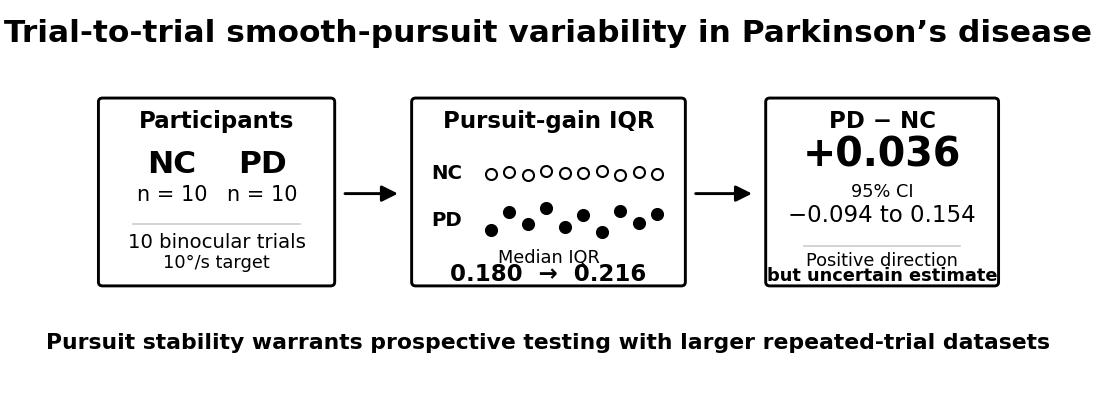

In [20]:
# ======================================================================
# CLEANER EJN GRAPHICAL ABSTRACT — VERSION 3
# ======================================================================

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

BASE = Path("/content/drive/MyDrive/Wu_PD")
OUT = BASE / "analysis_output"
FIGDIR = OUT / "journal_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(8.2, 3.4))

ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis("off")


# ======================================================================
# TITLE
# ======================================================================

ax.text(
    7,
    5.55,
    "Trial-to-trial smooth-pursuit variability in Parkinson’s disease",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)


# ======================================================================
# BOX COORDINATES
# ======================================================================

box_y = 1.75
box_h = 2.75

left_x, left_w = 0.45, 3.35
mid_x, mid_w = 5.05, 3.90
right_x, right_w = 10.25, 3.30


def rounded_box(x, y, w, h):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.06",
        facecolor="white",
        edgecolor="black",
        linewidth=1.4
    )
    ax.add_patch(patch)


rounded_box(left_x, box_y, left_w, box_h)
rounded_box(mid_x, box_y, mid_w, box_h)
rounded_box(right_x, box_y, right_w, box_h)


# ======================================================================
# LEFT — SAMPLE / TASK
# ======================================================================

ax.text(
    left_x + left_w/2,
    4.12,
    "Participants",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    left_x + 1.02,
    3.43,
    "NC",
    ha="center",
    fontsize=15,
    fontweight="bold"
)

ax.text(
    left_x + 2.35,
    3.43,
    "PD",
    ha="center",
    fontsize=15,
    fontweight="bold"
)

ax.text(
    left_x + 1.02,
    3.00,
    "n = 10",
    ha="center",
    fontsize=10
)

ax.text(
    left_x + 2.35,
    3.00,
    "n = 10",
    ha="center",
    fontsize=10
)

ax.plot(
    [left_x + 0.45, left_x + left_w - 0.45],
    [2.63, 2.63],
    color="0.8",
    linewidth=0.8
)

ax.text(
    left_x + left_w/2,
    2.28,
    "10 binocular trials",
    ha="center",
    fontsize=9.5
)

ax.text(
    left_x + left_w/2,
    1.98,
    "10°/s target",
    ha="center",
    fontsize=8.5
)


# ======================================================================
# ARROW 1
# ======================================================================

ax.add_patch(
    FancyArrowPatch(
        (3.95, 3.1),
        (4.85, 3.1),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.4,
        color="black"
    )
)


# ======================================================================
# MIDDLE — VARIABILITY VISUAL
# ======================================================================

ax.text(
    mid_x + mid_w/2,
    4.12,
    "Pursuit-gain IQR",
    ha="center",
    fontsize=11,
    fontweight="bold"
)


# NC low variability
nc_vals = np.array([
    0.48, 0.51, 0.47, 0.52, 0.50,
    0.49, 0.53, 0.46, 0.51, 0.48
])

# PD greater variability
pd_vals = np.array([
    0.35, 0.62, 0.43, 0.68, 0.39,
    0.57, 0.31, 0.64, 0.45, 0.59
])

xpos = np.linspace(
    mid_x + 1.10,
    mid_x + mid_w - 0.35,
    10
)


ax.text(
    mid_x + 0.68,
    3.42,
    "NC",
    ha="right",
    va="center",
    fontsize=9.5,
    fontweight="bold"
)

ax.scatter(
    xpos,
    3.42 + (nc_vals - 0.5),
    s=28,
    facecolor="white",
    edgecolor="black",
    linewidth=1
)


ax.text(
    mid_x + 0.68,
    2.70,
    "PD",
    ha="right",
    va="center",
    fontsize=9.5,
    fontweight="bold"
)

ax.scatter(
    xpos,
    2.70 + (pd_vals - 0.5),
    s=28,
    facecolor="black",
    edgecolor="black",
    linewidth=1
)


# Result numbers
ax.text(
    mid_x + mid_w/2,
    2.05,
    "Median IQR",
    ha="center",
    fontsize=8.5
)

ax.text(
    mid_x + mid_w/2,
    1.78,
    "0.180  →  0.216",
    ha="center",
    fontsize=11,
    fontweight="bold"
)


# ======================================================================
# ARROW 2
# ======================================================================

ax.add_patch(
    FancyArrowPatch(
        (9.10, 3.1),
        (10.05, 3.1),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.4,
        color="black"
    )
)


# ======================================================================
# RIGHT — EFFECT ESTIMATE
# ======================================================================

ax.text(
    right_x + right_w/2,
    4.12,
    "PD − NC",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    right_x + right_w/2,
    3.53,
    "+0.036",
    ha="center",
    fontsize=19,
    fontweight="bold"
)

ax.text(
    right_x + right_w/2,
    3.06,
    "95% CI",
    ha="center",
    fontsize=8.5
)

ax.text(
    right_x + right_w/2,
    2.68,
    "−0.094 to 0.154",
    ha="center",
    fontsize=11
)

ax.plot(
    [right_x + 0.50, right_x + right_w - 0.50],
    [2.30, 2.30],
    color="0.8",
    linewidth=0.8
)

ax.text(
    right_x + right_w/2,
    2.00,
    "Positive direction",
    ha="center",
    fontsize=8.5
)

ax.text(
    right_x + right_w/2,
    1.78,
    "but uncertain estimate",
    ha="center",
    fontsize=8.5,
    fontweight="bold"
)


# ======================================================================
# BOTTOM TAKE-HOME
# ======================================================================

ax.text(
    7,
    0.83,
    "Pursuit stability warrants prospective testing with larger repeated-trial datasets",
    ha="center",
    va="center",
    fontsize=10.5,
    fontweight="bold"
)


# ======================================================================
# SAVE
# ======================================================================

for ext in ["png", "pdf", "svg"]:

    path = FIGDIR / f"EJN_graphical_abstract_final.{ext}"

    if ext == "png":
        fig.savefig(
            path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white"
        )
    else:
        fig.savefig(
            path,
            bbox_inches="tight",
            facecolor="white"
        )

    print("Saved:", path)

plt.show()